# Análisis del dataset final

## Anotaciones

**Observaciones:**
- ¿Qué hemos visto?
- ¿Qué hemos deducido?

**Dudas:**
- Alguna parte donde nos hayamos quedado atascados

**TODOs:**
- Consideraciones/ Tareas a futuros

## Import librerías y dataset

In [2]:
import pandas as pd
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import re
import unicodedata

In [59]:
# Carga del dataset 
try:
    df = pd.read_csv('data/merged_all_clean.csv')
    
    if 'SEQN' in df.columns:
        df.drop(columns=['SEQN'], inplace=True)
        print("Columna 'SEQN' eliminada.")
        print(f"Dataset cargado con éxito: {df.shape[0]} filas y {df.shape[1]} columnas.")
        print(df.columns.tolist())
    else:
        print("No se encontró columna 'SEQN'.")
        print(f"Dataset cargado con éxito: {df.shape[0]} filas y {df.shape[1]} columnas.")
        print(df.columns.tolist())
        
except FileNotFoundError:
    print("Error: No se encontró el archivo 'all_merged_clean.csv' en la carpeta 'data/'.")

Columna 'SEQN' eliminada.
Dataset cargado con éxito: 2687 filas y 124 columnas.
['SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDHHSIZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR', 'WTDRD1', 'DSDCOUNT', 'DSDANCNT', 'DSD010', 'DSD010AN', 'BAXMSTAT', 'BAX5STAT', 'BAQ110', 'BAQ121', 'BAQ125', 'BAQ132', 'BAQ140', 'BAQ150', 'BAQ160', 'BAQ170', 'BAQ173', 'BAXPF11', 'BAXTC11', 'BAXPF21', 'BAXTC21', 'BAXPF31', 'BAXTC31', 'BAXPF41', 'BAXTC41', 'BPAOARM', 'BPAOCSZ', 'BPXOSY1', 'BPXODI1', 'BPXOSY2', 'BPXODI2', 'BPXOSY3', 'BPXODI3', 'BPXOPLS1', 'BPXOPLS2', 'BPXOPLS3', 'BMDSTATS', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BMXWAIST', 'BMXHIP', 'LUAXSTAT', 'LUAPNME', 'LUANMVGP', 'LUANMTGP', 'LUXSMED', 'LUXSIQR', 'LUXSIQRM', 'LUXCAPM', 'LUXCPIQR', 'URXUMA', 'URXUMS', 'URDUMALC', 'URXUCR', 'URXCRS', 'URDUCRLC', 'URDACT', 'WTPH2YR', 'LBXWBCSI', 'LBXLYPCT', 'LBXMOPCT', 'LBXNEPCT', 'LBXEOPCT', 'LBXBAPCT', 'LBDLYMNO', 'LB

In [60]:
# 1. Cargar diccionario
ruta_diccionario = "data/Diccionario_TFM_Completo.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

# 2. Limpiar columnas del diccionario
diccionario['Columna'] = diccionario['Columna'].astype(str).str.strip()
diccionario['Qué es'] = diccionario['Qué es'].astype(str).str.strip()

# 3. Función para limpiar nombres (ML friendly)
def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

# 4. Crear mapping limpio (old -> new)
mapping = dict(zip(diccionario['Columna'], diccionario['Qué es']))
mapping_filtrado = {k: limpiar_nombre(v) for k, v in mapping.items() if k in df.columns}

print(f"Columnas que se van a renombrar: {len(mapping_filtrado)}")

# 5. Renombrar dataset
df = df.rename(columns=mapping_filtrado)

# 6. Verificación
print("\nEjemplo de columnas renombradas:")
for old, new in list(mapping_filtrado.items()):
    print(f"{old} → {new}")

# 7. Columnas sin diccionario
columnas_sin_diccionario = [col for col in df.columns if col not in mapping_filtrado.values()]

print(f"\nColumnas sin renombrar: {len(columnas_sin_diccionario)}")
print(columnas_sin_diccionario)

Columnas que se van a renombrar: 124

Ejemplo de columnas renombradas:
SDDSRVYR → ciclo
RIDSTATR → estado_entrevista
RIAGENDR → genero
RIDAGEYR → edad_an
RIDRETH1 → raza_etnia1
RIDRETH3 → raza_etnia_3
RIDEXMON → periodo_examen
DMDBORN4 → pais_nacimiento
DMDHHSIZ → tamano_hogar
WTINT2YR → peso_entrevista
WTMEC2YR → peso_examen_mec
SDMVSTRA → estrato
SDMVPSU → psu
INDFMPIR → ratio_pobreza
WTDRD1 → peso_dieta_dia1
DSDCOUNT → cant_suplementos
DSDANCNT → cant_antiacidos
DSD010 → toma_suplementos
DSD010AN → toma_antiacidos
BAXMSTAT → estado_examen_balance
BAX5STAT → elegibilidad_balance
BAQ110 → mareos
BAQ121 → desmayos
BAQ125 → convulsiones
BAQ132 → dificultad_caminar
BAQ140 → caidas
BAQ150 → fracturas
BAQ160 → test_densidad_osea
BAQ170 → medicacion_osteoporosis
BAQ173 → diagnostico_osteoporosis
BAXPF11 → aprueba_cond1
BAXTC11 → tiempo_seg_cond1
BAXPF21 → aprueba_cond2
BAXTC21 → tiempo_seg_cond2
BAXPF31 → aprueba_cond3
BAXTC31 → tiempo_seg_cond3
BAXPF41 → aprueba_cond4
BAXTC41 → tiempo_seg_

- Tras cerrar este apartado nos hemos quedado con el dataset sin la columna identificador y se han cambiado los nombres de las variables por otros más interpretables.

## Análisis Variables

In [61]:
# 1. Definición de categóricas utilizando el diccionario
  # Como ya importamos el diccionario en la celda anterior para renombrar no volvemos a importar. 

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
cols_categoricas = [limpiar_nombre(col) for col in cols_categoricas]

print(f"Número de columnas categóricas: {len(cols_categoricas)}")
print(cols_categoricas)

Número de columnas categóricas: 37
['ciclo', 'estado_entrevista', 'genero', 'raza_etnia1', 'raza_etnia_3', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'mareos', 'desmayos', 'convulsiones', 'dificultad_caminar', 'caidas', 'fracturas', 'test_densidad_osea', 'medicacion_osteoporosis', 'diagnostico_osteoporosis', 'aprueba_cond1', 'aprueba_cond2', 'aprueba_cond3', 'aprueba_cond4', 'brazo_medicion_pa', 'tamano_manguito_pa', 'estado_medidas_corp', 'estado_elastografia', 'tipo_sonda_elasto', 'nota_albumina_orina', 'nota_creatinina_orina', 'nota_proteina_c_reactiva', 'nota_plomo', 'nota_cadmio', 'nota_mercurio', 'nota_selenio', 'nota_manganeso']


In [62]:
# 2. Filtrar solo las presentes
cols_categoricas_presentes = [col for col in cols_categoricas if col in df.columns]

# 3. Convertir a category
for col in cols_categoricas_presentes:
    df[col] = df[col].astype('category')

# 4. Identificar numéricas
cols_numericas = df.columns.difference(cols_categoricas_presentes).tolist()

# 5. Verificación CORRECTA
print(f"--- Clasificación Manual Completada ---")
print(f"Variables categóricas (esperadas): {len(cols_categoricas_presentes)}")
print(f"Variables numéricas: {len(cols_numericas)}")

# Conteo correcto de tipos
print("\nResumen de tipos de datos:")
print(df.dtypes.astype(str).value_counts())

# 6. Diagnóstico 
print("\nColumnas categóricas detectadas:")
print(df.select_dtypes(include='category').columns.tolist())

print("\nColumnas object (revisar si deberían ser categóricas):")
print(df.select_dtypes(include='object').columns.tolist())

# Ver qué variables no estaban en el dataset
cols_faltantes = [col for col in cols_categoricas if col not in df.columns]

print(f"\nCategóricas presentes: {len(cols_categoricas_presentes)}")
print(f"Categóricas faltantes: {len(cols_faltantes)}")

--- Clasificación Manual Completada ---
Variables categóricas (esperadas): 37
Variables numéricas: 87

Resumen de tipos de datos:
float64     87
category    37
Name: count, dtype: int64

Columnas categóricas detectadas:
['ciclo', 'estado_entrevista', 'genero', 'raza_etnia1', 'raza_etnia_3', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'mareos', 'desmayos', 'convulsiones', 'dificultad_caminar', 'caidas', 'fracturas', 'test_densidad_osea', 'medicacion_osteoporosis', 'diagnostico_osteoporosis', 'aprueba_cond1', 'aprueba_cond2', 'aprueba_cond3', 'aprueba_cond4', 'brazo_medicion_pa', 'tamano_manguito_pa', 'estado_medidas_corp', 'estado_elastografia', 'tipo_sonda_elasto', 'nota_albumina_orina', 'nota_creatinina_orina', 'nota_proteina_c_reactiva', 'nota_plomo', 'nota_cadmio', 'nota_mercurio', 'nota_selenio', 'nota_manganeso']

Columnas object (revisar si deberían ser categóricas):
[]

Categóricas presentes: 37
Cat

Exportacion del dataset con los nombres actualizados

In [63]:
#df.to_csv('DataframeFinal.csv', index=False)

## Valores nulos

Antes de proceder con el análisis de nulos por columna vamos a revisar los nulos que hay por fila.

Distribución de filas según porcentaje de nulos:

rango_nulos
0-10%     2074
10-20%     362
20-30%      91
30-40%      75
40-50%      62
>50%        23
Name: count, dtype: int64


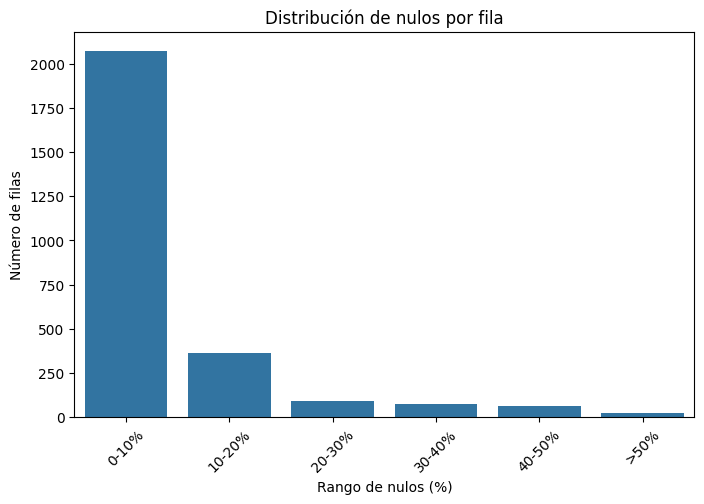


Número de filas con más de 30% de nulos: 160


In [64]:

# 1. Porcentaje de nulos por fila
df_null_rows = df.isnull().mean(axis=1) * 100

# Convertimos a DataFrame para trabajar mejor
df_null_rows = df_null_rows.to_frame(name='porcentaje_nulos')

# 2. Clasificación en rangos (MISMA lógica que columnas)
bins = [0, 10, 20, 30, 40, 50, 100]
labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '>50%']

df_null_rows['rango_nulos'] = pd.cut(df_null_rows['porcentaje_nulos'], bins=bins, labels=labels, include_lowest=True)

# 3. Conteo por rango
conteo_filas = df_null_rows['rango_nulos'].value_counts().sort_index()

print("Distribución de filas según porcentaje de nulos:\n")
print(conteo_filas)

# 4. Visualización
plt.figure(figsize=(8,5))
sns.barplot(x=conteo_filas.index, y=conteo_filas.values)
plt.title("Distribución de nulos por fila")
plt.xlabel("Rango de nulos (%)")
plt.ylabel("Número de filas")
plt.xticks(rotation=45)
plt.show()

# 5. Filas problemáticas (>30%)
filas_malas = df_null_rows[df_null_rows['porcentaje_nulos'] > 30]

print(f"\nNúmero de filas con más de 30% de nulos: {len(filas_malas)}")

La mayor parte de nuestros pacientes presentan un porcentage de nulos ínfimo (0-10%). Para evitar perder un gran volumen de pacientes, vamos a proceder a eliminar únicamente aquellos cuyo porcentage de nulos sea superior al 30%

In [65]:
# 1. Filtrar filas con <=30% de nulos
df_clean_rows = df[df_null_rows['porcentaje_nulos'] <= 30].copy()

# 2. Comparación antes vs después
print("ANTES:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\nDESPUÉS (filtrando >30% nulos):")
print(f"Filas: {df_clean_rows.shape[0]}")
print(f"Columnas: {df_clean_rows.shape[1]}")

# 3. Filas eliminadas
filas_eliminadas = df.shape[0] - df_clean_rows.shape[0]
print(f"\nFilas eliminadas: {filas_eliminadas}")

ANTES:
Filas: 2687
Columnas: 124

DESPUÉS (filtrando >30% nulos):
Filas: 2527
Columnas: 124

Filas eliminadas: 160


In [66]:
# Cálculo de porcentajes de nulos
null_counts = df_clean_rows.isnull().sum()
null_percentages = (null_counts / len(df_clean_rows)) * 100

# Tabla resumen de nulos
df_nulls = pd.DataFrame({
    'Variable': null_percentages.index,
    'Porcentaje_Nulos': null_percentages.values
}).sort_values(by='Porcentaje_Nulos', ascending=False)

# Clasificación por rangos 
bins = [0, 10, 20, 30, 100]
labels = ['0-10%', '10-20%', '20-30%', '>30%']

# Creamos una columna de rango 
df_nulls['Rango'] = pd.cut(df_nulls['Porcentaje_Nulos'], bins=bins, labels=labels, include_lowest=True)

# Mostrar conteo de variables por rango
resumen_rangos = df_nulls['Rango'].value_counts().sort_index()

print("--- Resumen de Variables por Rango de Nulos ---")
for rango, cantidad in resumen_rangos.items():
    print(f"Rango {rango}: {cantidad} variables")

# Mostrar las variables con más nulos 
print("\nPorcentage de nulos por variable")
print(df_nulls.to_string(index=False))

--- Resumen de Variables por Rango de Nulos ---
Rango 0-10%: 105 variables
Rango 10-20%: 13 variables
Rango 20-30%: 6 variables
Rango >30%: 0 variables

Porcentage de nulos por variable
                      Variable  Porcentaje_Nulos  Rango
       medicacion_osteoporosis         25.207756 20-30%
            test_densidad_osea         23.031262 20-30%
               toma_antiacidos         21.250495 20-30%
               cant_antiacidos         21.250495 20-30%
              cant_suplementos         21.052632 20-30%
              toma_suplementos         21.052632 20-30%
              tiempo_seg_cond4         17.768104 10-20%
                 aprueba_cond4         17.609814 10-20%
              tiempo_seg_cond3         17.253660 10-20%
                 aprueba_cond3         17.055797 10-20%
              tiempo_seg_cond2         16.224772 10-20%
                 aprueba_cond2         16.185200 10-20%
              tiempo_seg_cond1         16.066482 10-20%
                 aprueba_cond1

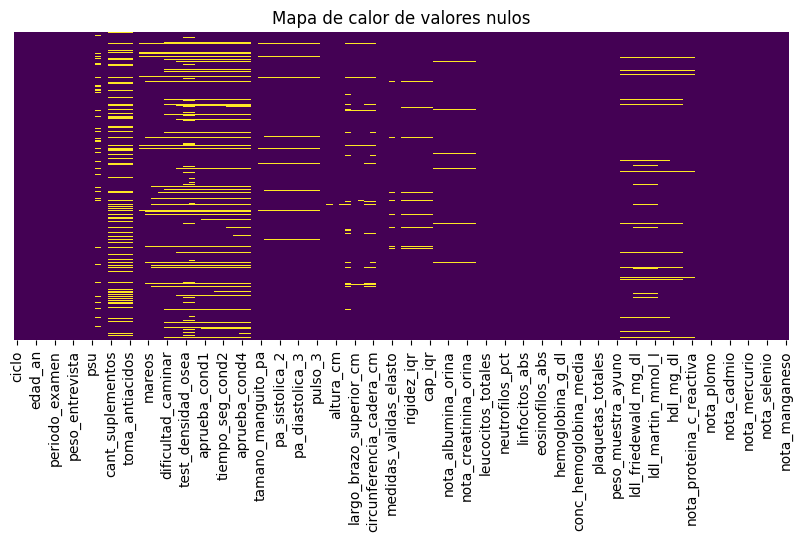

In [67]:
# Visualización rápida de nulos
plt.figure(figsize=(10, 4))
sns.heatmap(df_clean_rows.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.show()

## Distribución de Categóricas

Tras haber definifo las variables categóricas procedemos a observar la distribución y a buscar si se pudiese combinar variables de este tipo.

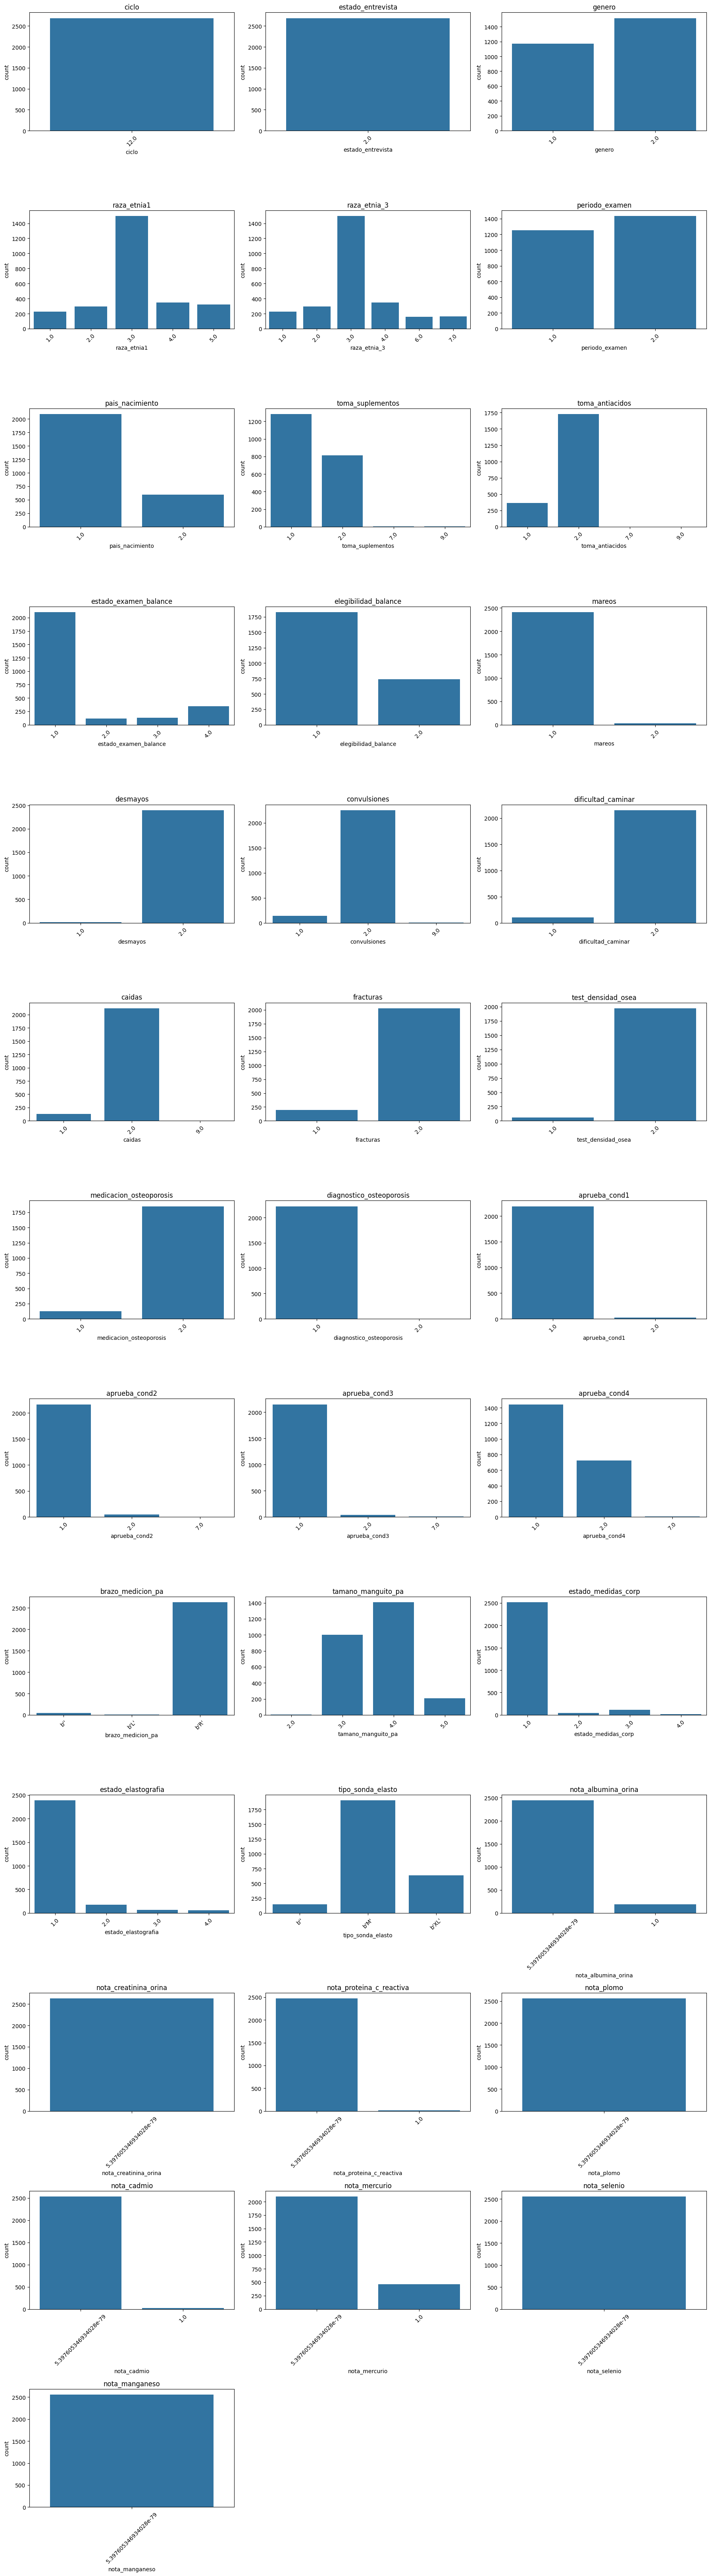

In [68]:
# 1. Configuración
n_cols = 3  # nº de gráficos por fila
n_vars = len(cols_categoricas)
n_rows = (n_vars // n_cols) + 1

plt.figure(figsize=(18, 5 * n_rows))

# 2. Loop por variables categóricas
for i, col in enumerate(cols_categoricas):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Conteo de valores
    conteo = df[col].value_counts().reset_index()
    conteo.columns = [col, 'count']
    
    # Barplot
    sns.barplot(data=conteo, x=col, y='count')
    
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<u>**Análisis resultados**</u>

Una gran parte de las variables categóricas presenta un fuerte desbalance, donde una categoría domina claramente sobre las demás.

Ejemplos representativos:
- `mareos`, `desmayos`, `convulsiones`
- `dificultad_caminar`, `caidas`, `fracturas`
- `med_osteoporosis`, `diag_osteoporosis`

Este desbalance implica que una categoría domina claramente sobre el resto. Esto es consistente con datos de población general, pero introduce sesgos, favoreciendo la clase mayoritaria.

Además, se identifican variables con muy baja variabilidad o prácticamente constantes, especialmente en indicadores de laboratorio o variables técnicas. Estas variables aportan poca o ninguna información relevante, por lo que pueden ser consideradas candidatas a eliminación en fases posteriores del análisis.




In [73]:
# Como primer paso vamos a eliminar las variables muy desbalanceadas
vars_desbalanceadas = []

for col in df.columns:
    if col in cols_categoricas:
        frec = df[col].value_counts(normalize=True).max()
        
        if frec > 0.95:
            vars_desbalanceadas.append(col)

print("Variables muy desbalanceadas:")
print(vars_desbalanceadas)
print("Variables totales categóricas:")
print(len(cols_categoricas))

df = df.drop(columns=vars_desbalanceadas)
cols_categoricas = [
    col for col in cols_categoricas
    if col not in vars_desbalanceadas
]

print("Variables categóricas tras limpieza:")
print(len(cols_categoricas))

Variables muy desbalanceadas:
['ciclo', 'estado_entrevista', 'mareos', 'desmayos', 'dificultad_caminar', 'test_densidad_osea', 'diagnostico_osteoporosis', 'aprueba_cond1', 'aprueba_cond2', 'aprueba_cond3', 'brazo_medicion_pa', 'nota_creatinina_orina', 'nota_proteina_c_reactiva', 'nota_plomo', 'nota_cadmio', 'nota_selenio', 'nota_manganeso']
Variables totales categóricas:
37
Variables categóricas tras limpieza:
20


Cabe destacar que nuestras variables NO SON BINARIAS.

En la documentación viene especificado que muchas de nustras variables binarias vienen dadas con '1' y '2'. Además, muchos nulos tienen un valor dado (como 3, 4, 7 o 9) por lo que no aparecen en una primera inspección. 

Por lo tanto, primero vamos a dividir las bariables entre binarias, binarias especiales y no binarias. Posteriormente aplicaremos una función para convertirlas en binarias codificadas adecuadamente con los 1, 0 y NaN que correspondan.

In [74]:
binarias_puras = []
binarias_especiales = []
no_binarias = []

for col in cols_categoricas:
    if col not in df.columns:
        continue
    
    valores = pd.Series(df[col].dropna().unique()).tolist()
    valores_validos = sorted([v for v in valores if pd.notna(v)])
    valores_set = set(valores_validos)
    
    # sin contar NaN
    if valores_set.issubset({1, 2}):
        binarias_puras.append(col)
    
    elif valores_set.issubset({1, 2, 7, 9, 3, 4}):
        binarias_especiales.append(col)
    
    else:
        no_binarias.append(col)


In [75]:
print("\n=== BINARIAS PURAS (1/2) ===")
for col in binarias_puras:
    
    if col not in df.columns:
        continue
    print(f"\n{'='*50}")
    print(f"VARIABLE: {col}")
    print(f"{'='*50}")
    print(df[col].unique())

print("\n=== BINARIAS CON CÓDIGOS ESPECIALES (1/2/7/9) ===")
for col in binarias_especiales:
    
    if col not in df.columns:
        continue
    print(f"\n{'='*50}")
    print(f"VARIABLE: {col}")
    print(f"{'='*50}")
    print(df[col].unique())

print("\n=== NO BINARIAS ===")
for col in no_binarias:
    
    if col not in df.columns:
        continue
    print(f"\n{'='*50}")
    print(f"VARIABLE: {col}")
    print(f"{'='*50}")
    print(df[col].unique())


=== BINARIAS PURAS (1/2) ===

VARIABLE: genero
[1.0, 2.0]
Categories (2, float64): [1.0, 2.0]

VARIABLE: periodo_examen
[2.0, 1.0]
Categories (2, float64): [1.0, 2.0]

VARIABLE: pais_nacimiento
[2.0, 1.0]
Categories (2, float64): [1.0, 2.0]

VARIABLE: elegibilidad_balance
[1.0, 2.0, NaN]
Categories (2, float64): [1.0, 2.0]

VARIABLE: fracturas
[2.0, 1.0, NaN]
Categories (2, float64): [1.0, 2.0]

VARIABLE: medicacion_osteoporosis
[2.0, NaN, 1.0]
Categories (2, float64): [1.0, 2.0]

=== BINARIAS CON CÓDIGOS ESPECIALES (1/2/7/9) ===

VARIABLE: toma_suplementos
[2.0, 1.0, NaN, 7.0, 9.0]
Categories (4, float64): [1.0, 2.0, 7.0, 9.0]

VARIABLE: toma_antiacidos
[2.0, NaN, 1.0, 9.0, 7.0]
Categories (4, float64): [1.0, 2.0, 7.0, 9.0]

VARIABLE: estado_examen_balance
[1.0, 4.0, 3.0, 2.0]
Categories (4, float64): [1.0, 2.0, 3.0, 4.0]

VARIABLE: convulsiones
[2.0, NaN, 1.0, 9.0]
Categories (3, float64): [1.0, 2.0, 9.0]

VARIABLE: caidas
[2.0, 1.0, NaN, 9.0]
Categories (3, float64): [1.0, 2.0, 9.0

Del listado anterior, pasaremos a binario las columnas de las categorías "binarias puras" y "binarias especiales".

En las "no binarias" encontramos el conjunto de columnas que recogen el código de un comentario realizado por el paciente respecto a la prueba realizada, por lo que las trataremos a parte.

In [55]:
# función para volver las variables a binario
def recodif_binario(col):
    return col.replace({
        1: 1,
        2: 0,
        3: np.nan,
        4: np.nan,
        7: np.nan,
        9: np.nan
    })

In [56]:
cols_binarias = binarias_puras + binarias_especiales

for col in cols_binarias:
        if col not in df.columns:
                continue
        
        df[col].replace = recodif_binario(df[col])
        print("La columna", col, "es ahora binaria.")

La columna genero es ahora binaria.
La columna periodo_examen es ahora binaria.
La columna pais_nacimiento es ahora binaria.
La columna elegibilidad_balance es ahora binaria.
La columna fracturas es ahora binaria.
La columna medicacion_osteoporosis es ahora binaria.
La columna toma_suplementos es ahora binaria.
La columna toma_antiacidos es ahora binaria.
La columna estado_examen_balance es ahora binaria.
La columna convulsiones es ahora binaria.
La columna caidas es ahora binaria.
La columna aprueba_cond4 es ahora binaria.
La columna estado_medidas_corp es ahora binaria.
La columna estado_elastografia es ahora binaria.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10820\3624228907.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  return col.replace({


Dado que hemos metido nuevos nulos, vamos a revisar la distribución de estos.

Porcentaje de nulos en variables binarias:


,variable,porcentaje_nulos
0,medicacion_osteoporosis,26.572386
1,toma_antiacidos,22.143655
2,toma_suplementos,21.957574
3,aprueba_cond4,19.129140
4,fracturas,17.119464
5,caidas,16.226275
6,convulsiones,10.867138
7,nota_mercurio,4.763677
8,elegibilidad_balance,4.614812
9,tamano_manguito_pa,2.493487


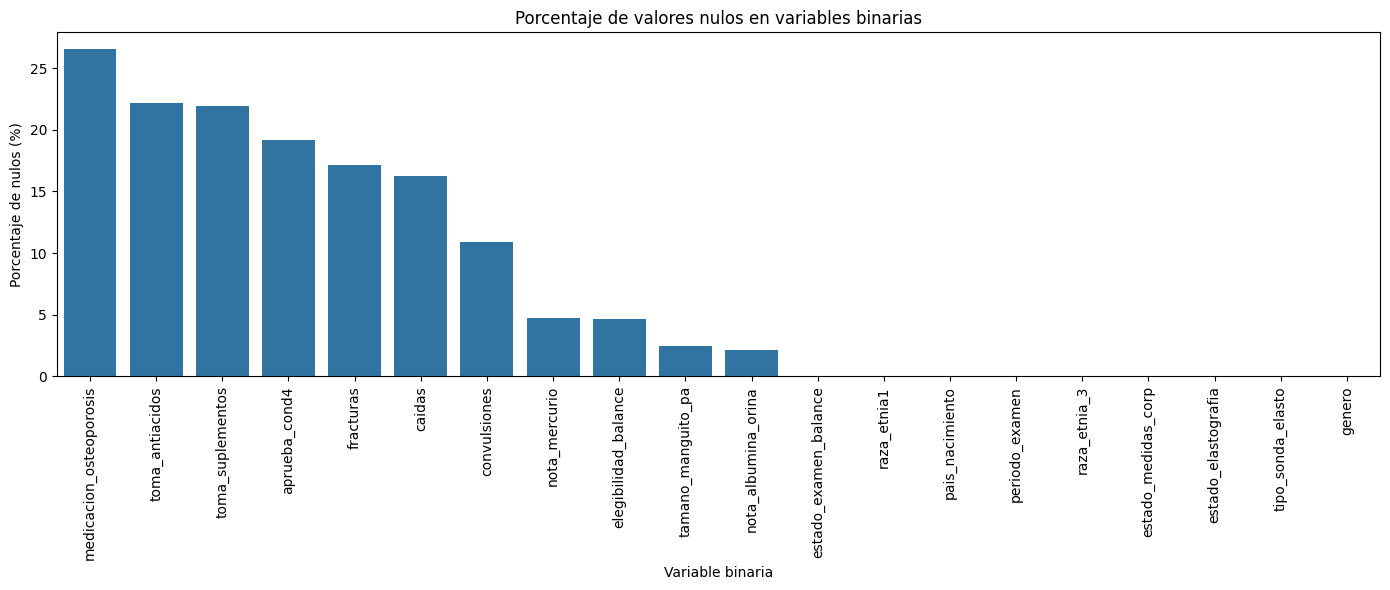

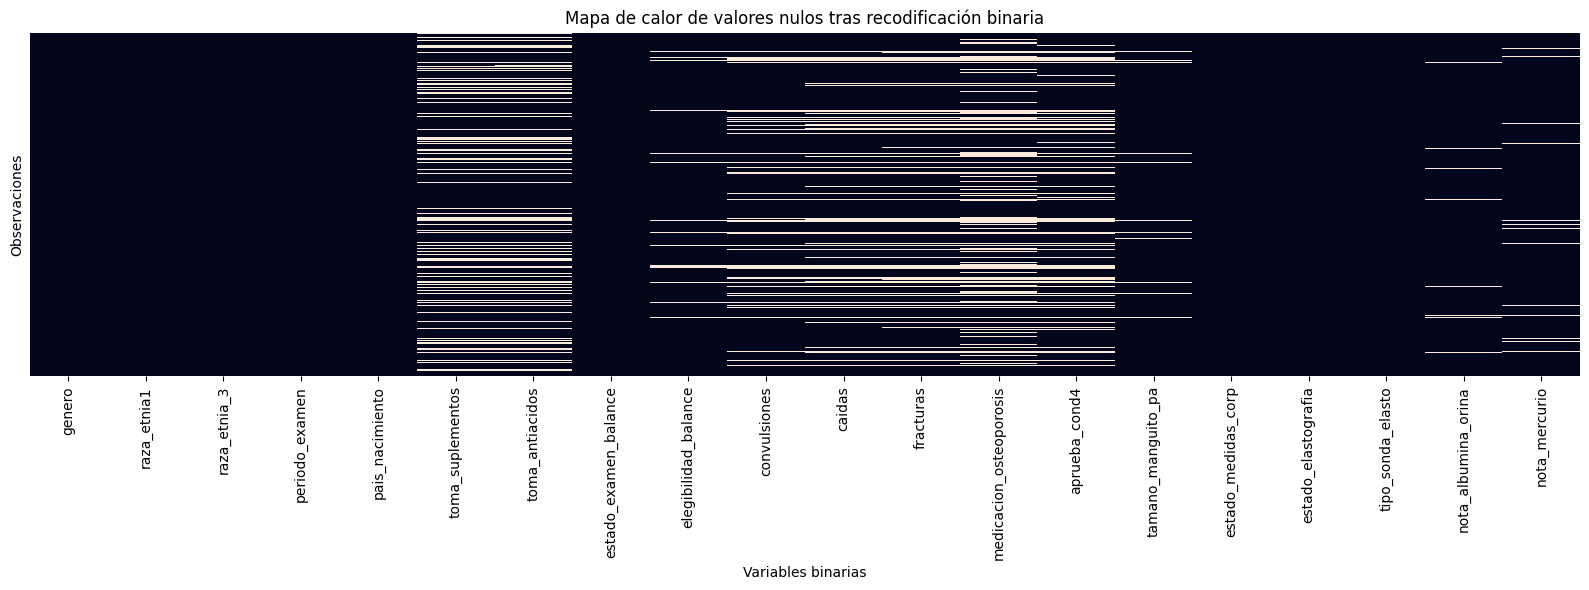

In [77]:
# 1. Revisar nulos tras recodificación binaria

# porcentaje de nulos
porcentaje_nulos = (
    df[cols_categoricas]
    .isnull()
    .mean() * 100
).sort_values(ascending=False)


df_nulos = porcentaje_nulos.reset_index()
df_nulos.columns = ['variable', 'porcentaje_nulos']

print("Porcentaje de nulos en variables binarias:")
display(df_nulos)

# 2. Barplot porcentaje de nulos
plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_nulos,
    x='variable',
    y='porcentaje_nulos'
)

plt.title('Porcentaje de valores nulos en variables binarias')
plt.xlabel('Variable binaria')
plt.ylabel('Porcentaje de nulos (%)')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# 3. Heatmap de nulos
plt.figure(figsize=(16, 6))

sns.heatmap(
    df[cols_categoricas].isnull(),
    cbar=False,
    yticklabels=False
)

plt.title('Mapa de calor de valores nulos tras recodificación binaria')
plt.xlabel('Variables binarias')
plt.ylabel('Observaciones')

plt.tight_layout()
plt.show()

Hay un crecimiento en los nulos, que era lo esperado, pero resulta tan insignificante que no afecta especialmente al porcentaje previo de nulos en la variable.

Para lidiar con ellos, dado su porcentage y que son MCAR en su inmensa mayoría, vamos a imputarlos utilizando la moda.

In [81]:
cols_categoricas = [col for col in cols_categoricas if col in df.columns]

for col in cols_categoricas:
    
    # calcular moda
    moda = df[col].mode(dropna=True)
    
    # evitar errores si una columna está completamente vacía
    if len(moda) == 0:
        continue
    moda = moda[0]
    
    # imputar nulos
    df[col] = df[col].fillna(moda)
    df[col] = df[col].astype('category')

In [82]:
nulos_restantes = df[cols_categoricas].isnull().sum()

nulos_restantes = nulos_restantes[nulos_restantes > 0]

print("Nulos restantes en categóricas:")
display(nulos_restantes)

Nulos restantes en categóricas:


Series([], dtype: int64)

## Distribuciones y Outliers (Numéricas)

### Distribuciones Globales

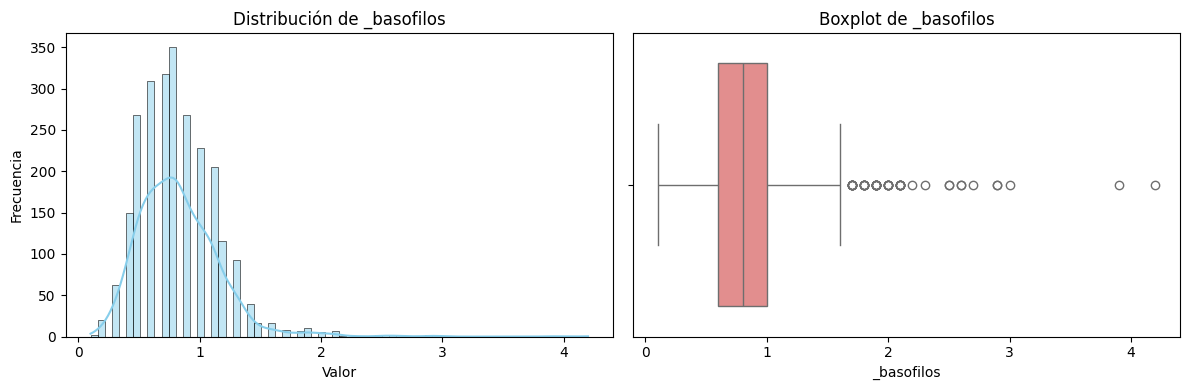

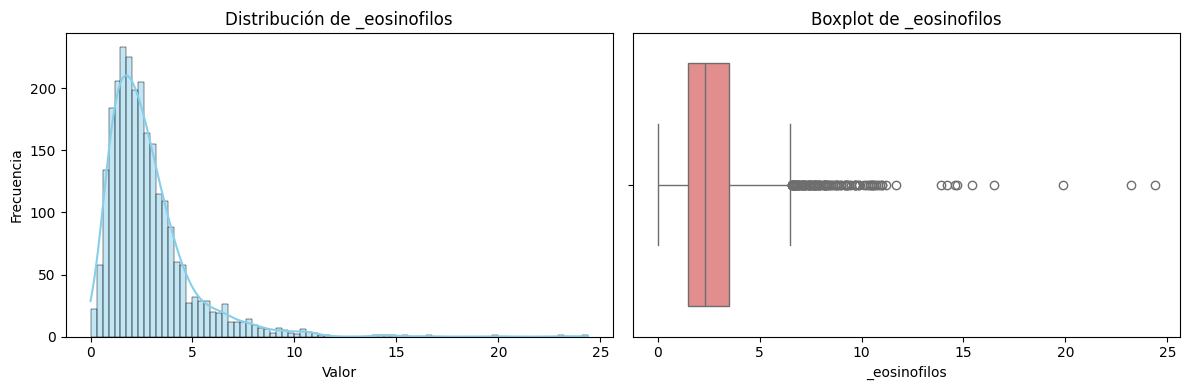

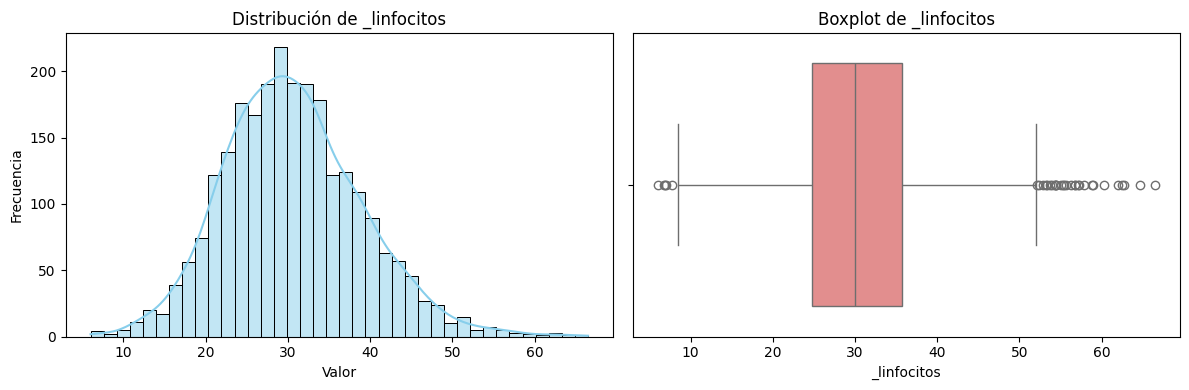

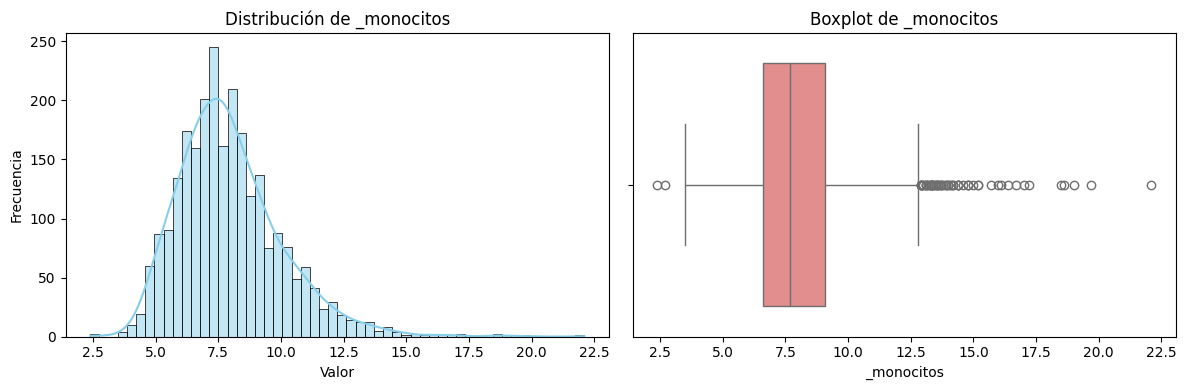

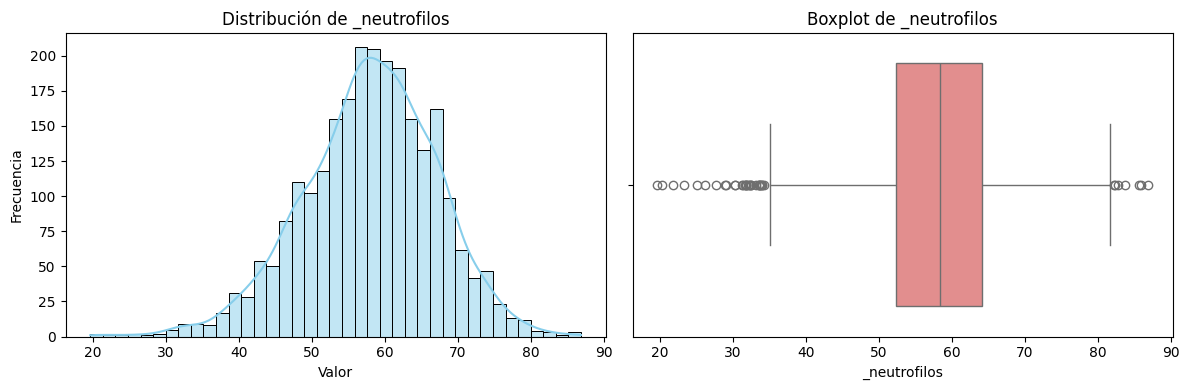

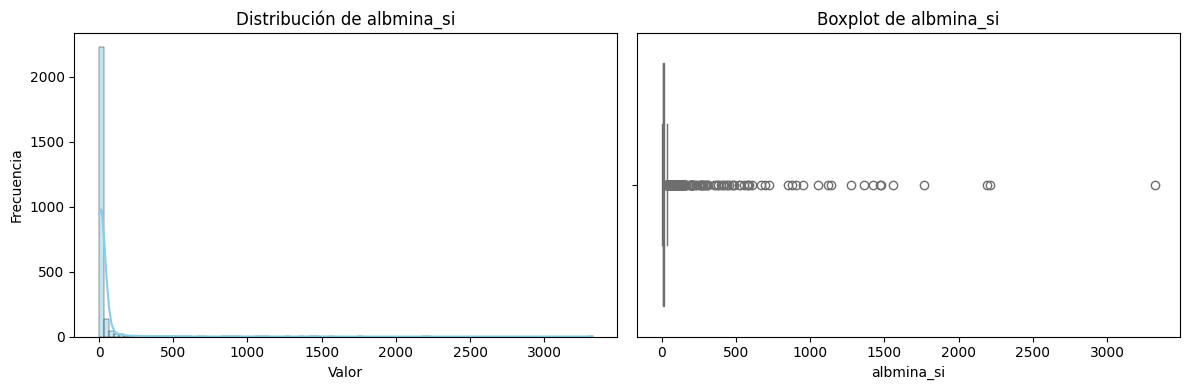

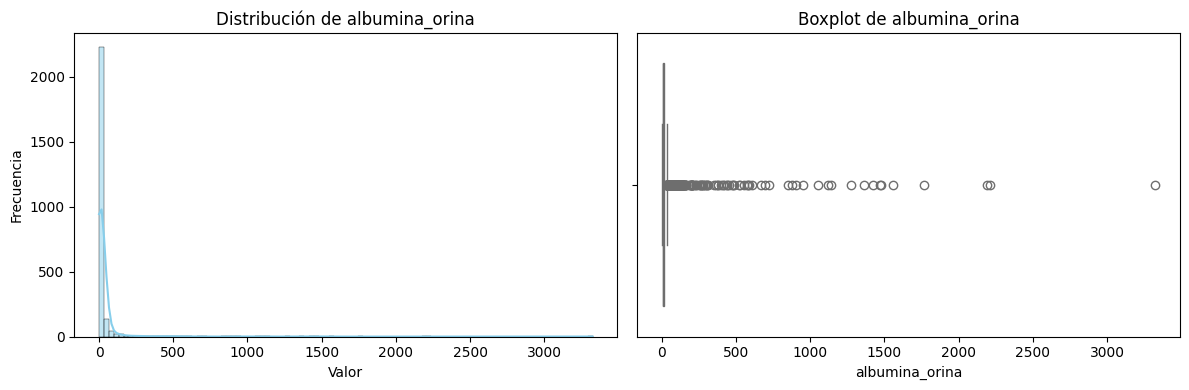

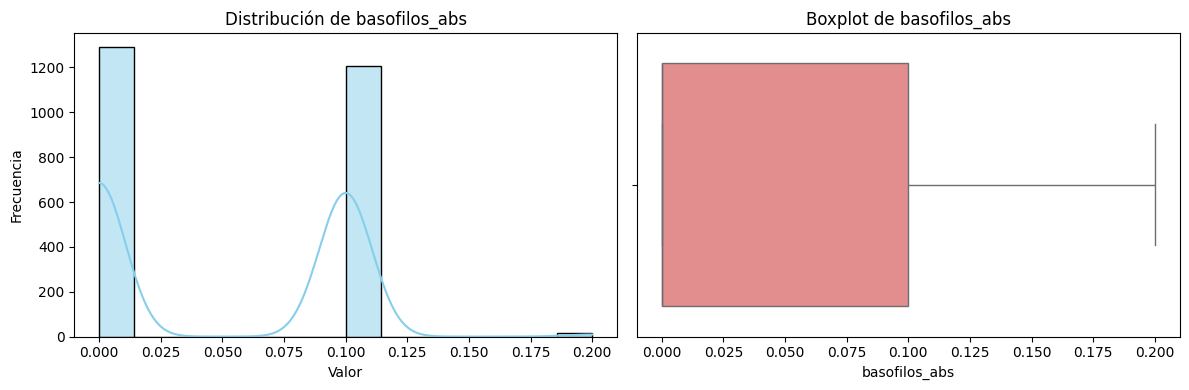

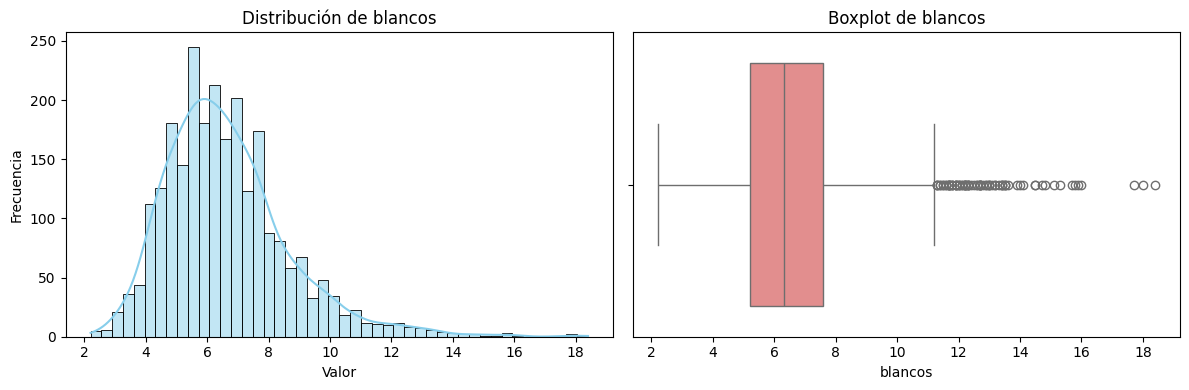

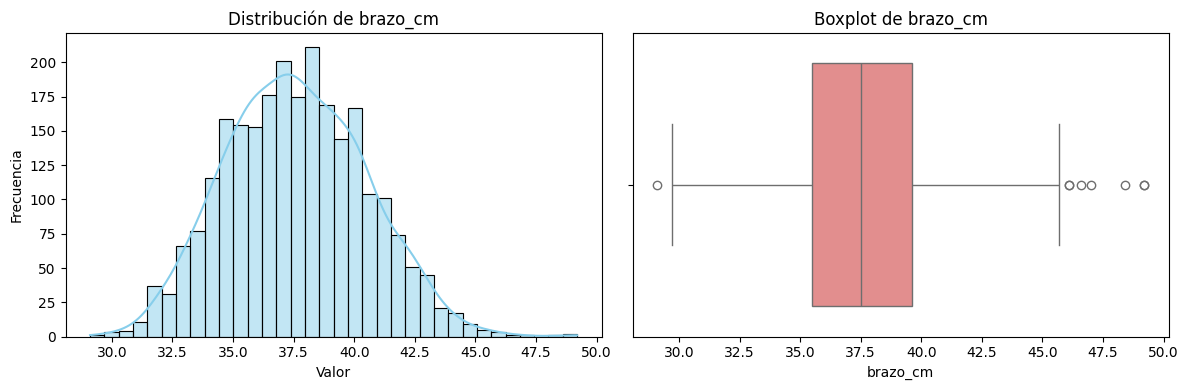

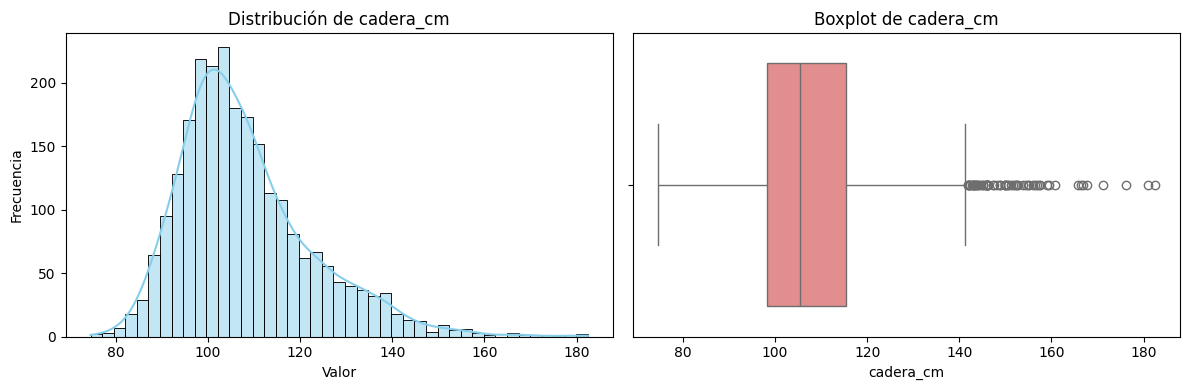

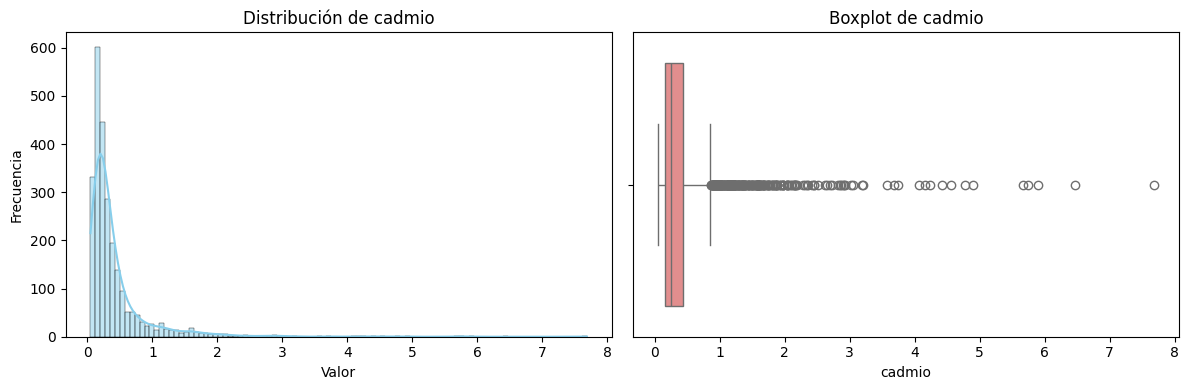

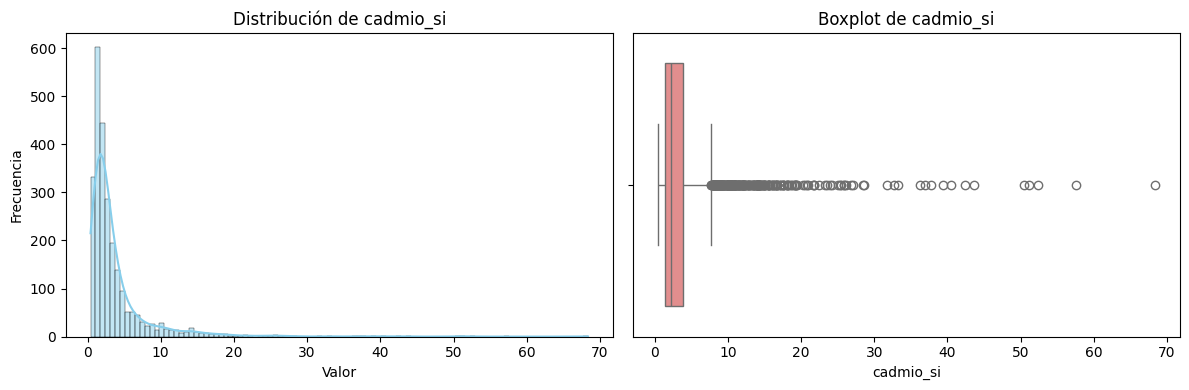

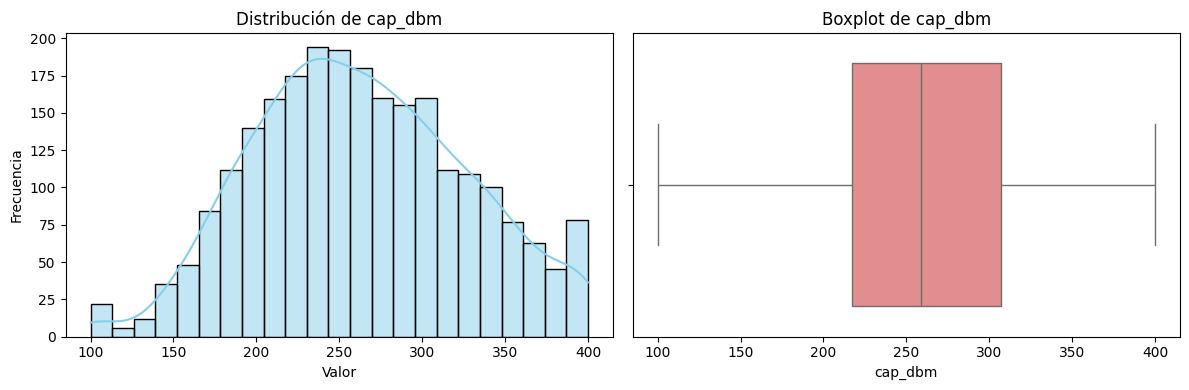

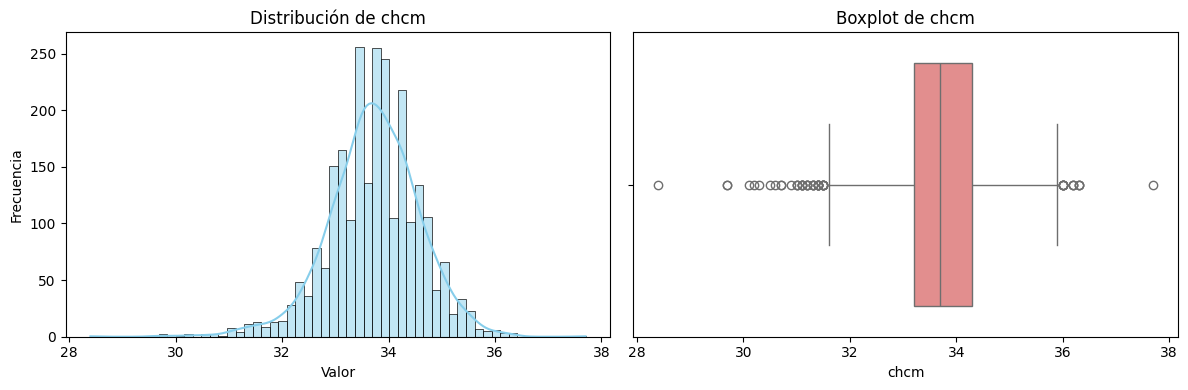

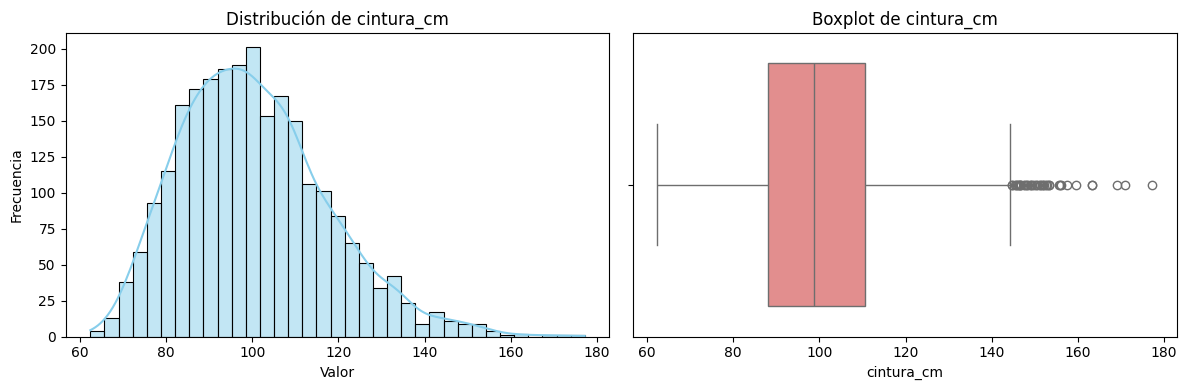

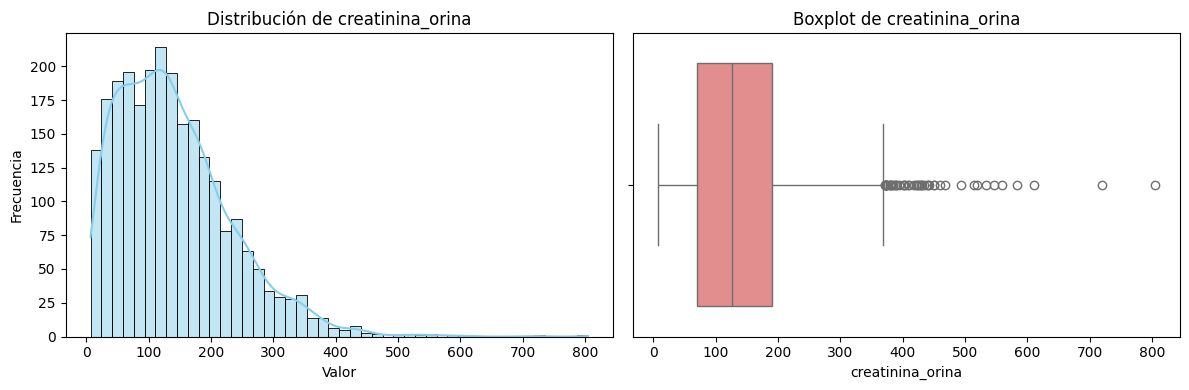

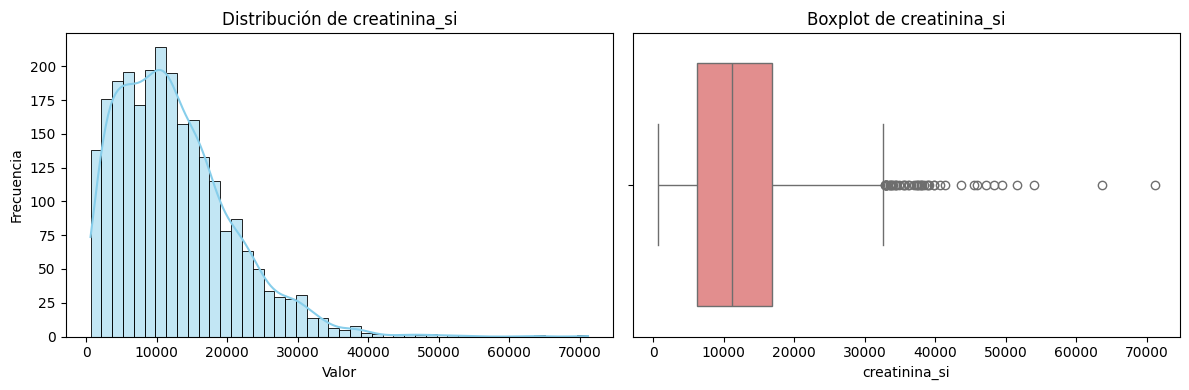

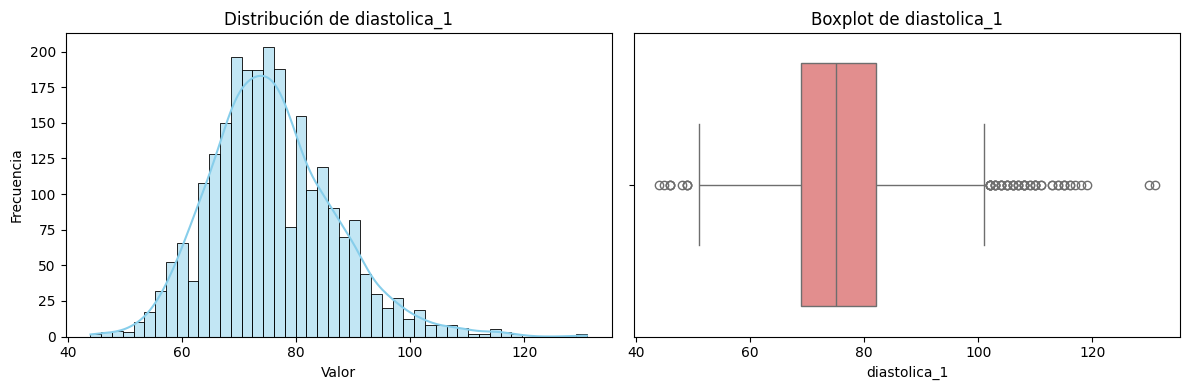

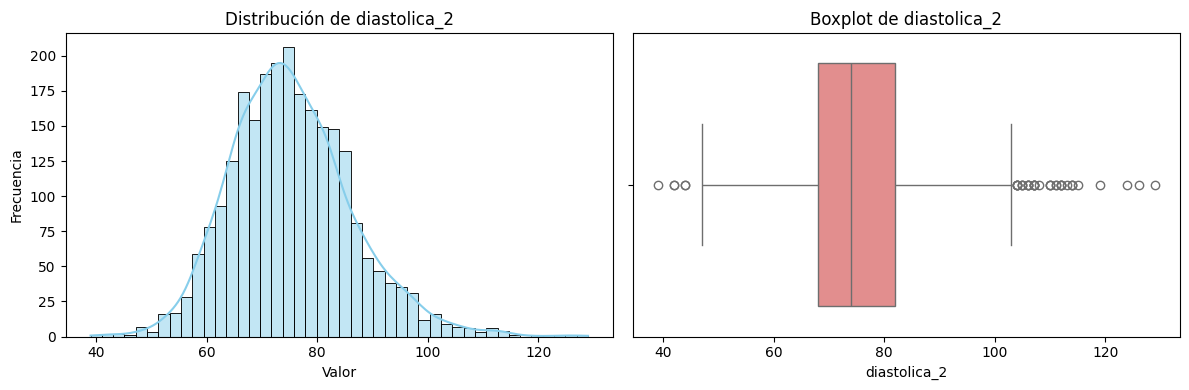

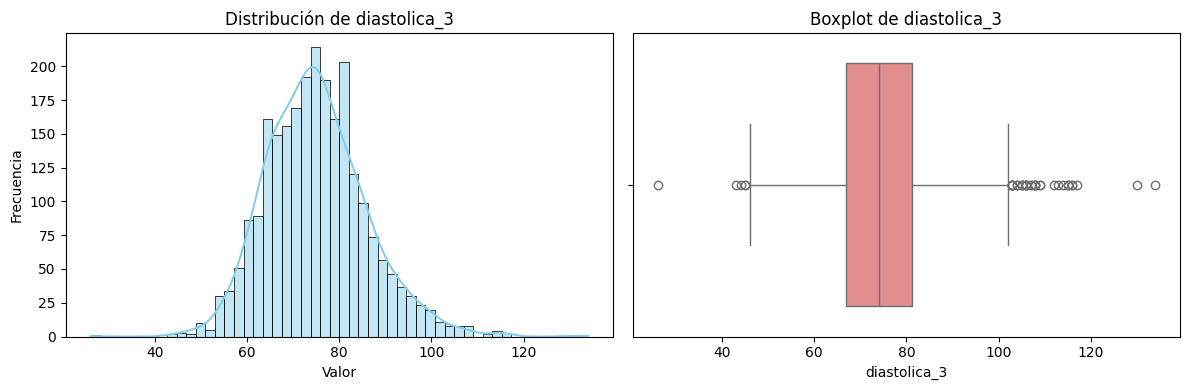

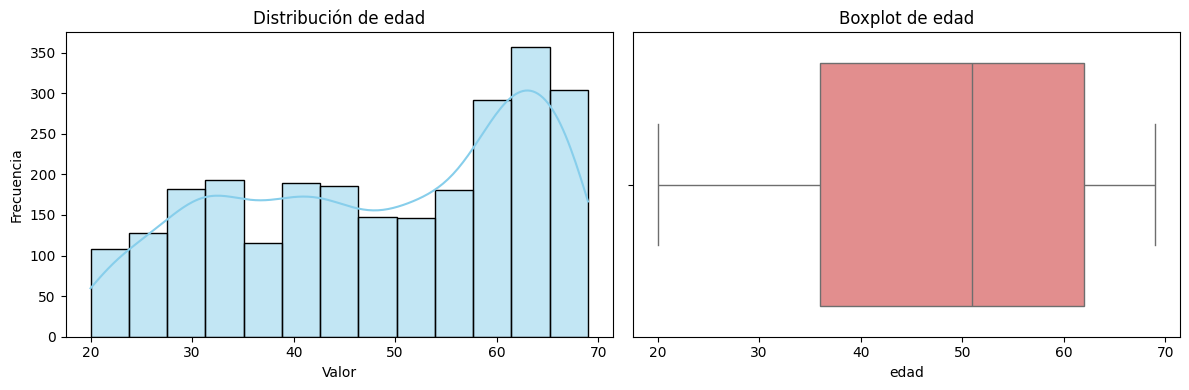

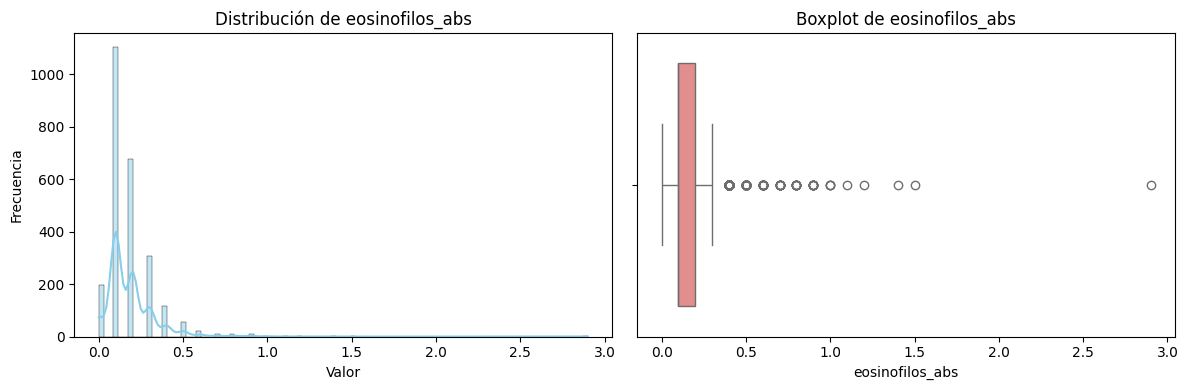

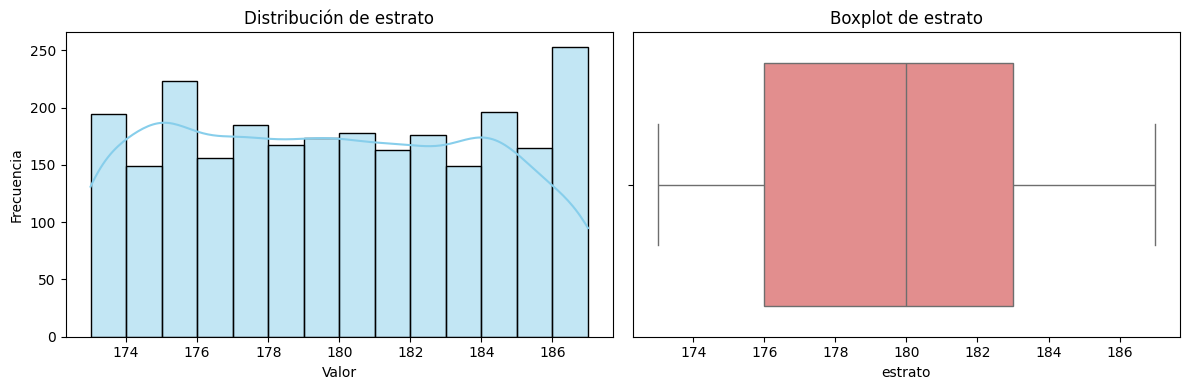

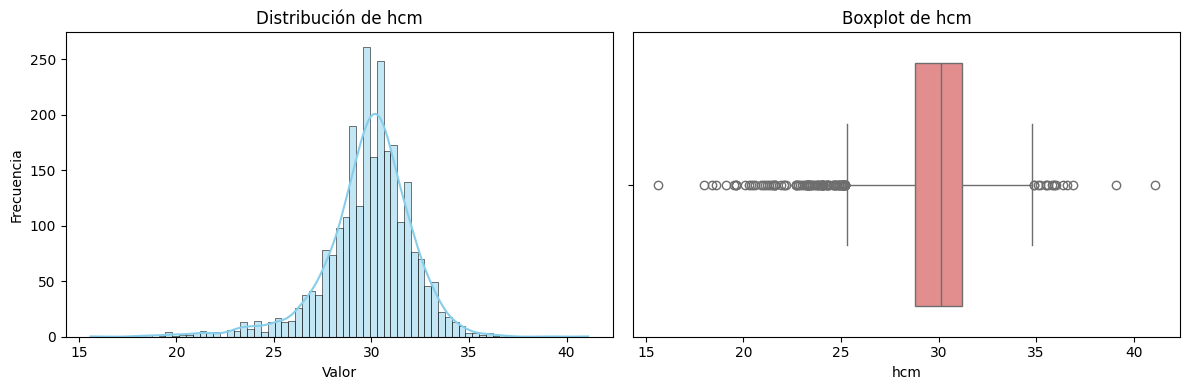

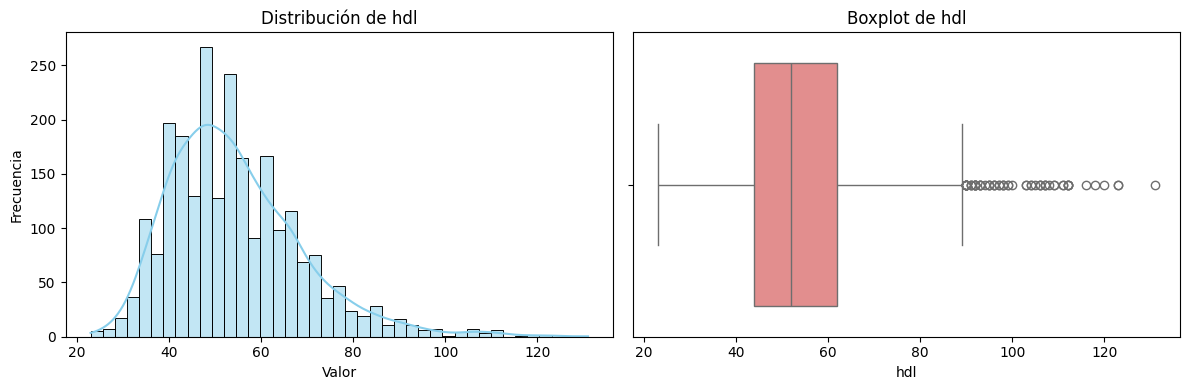

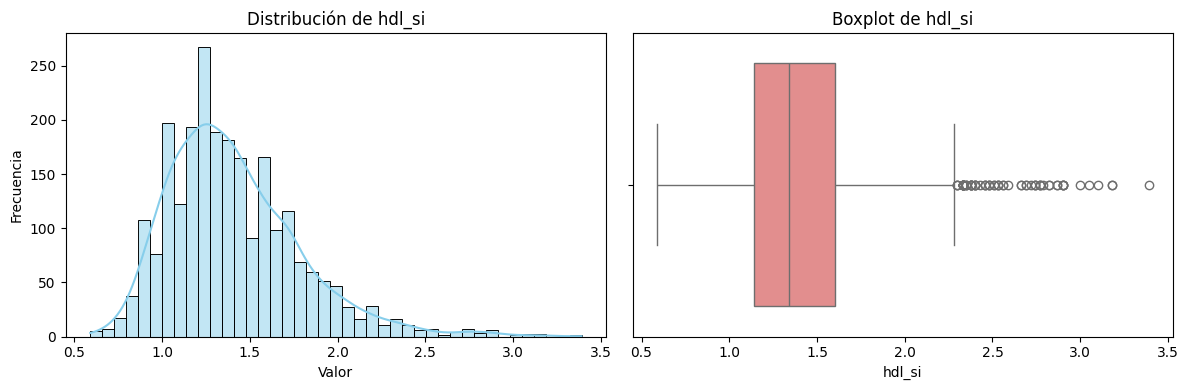

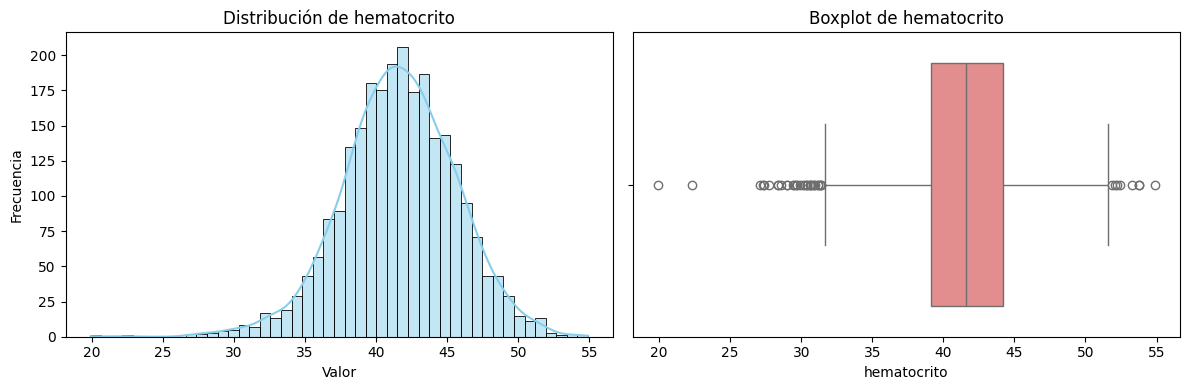

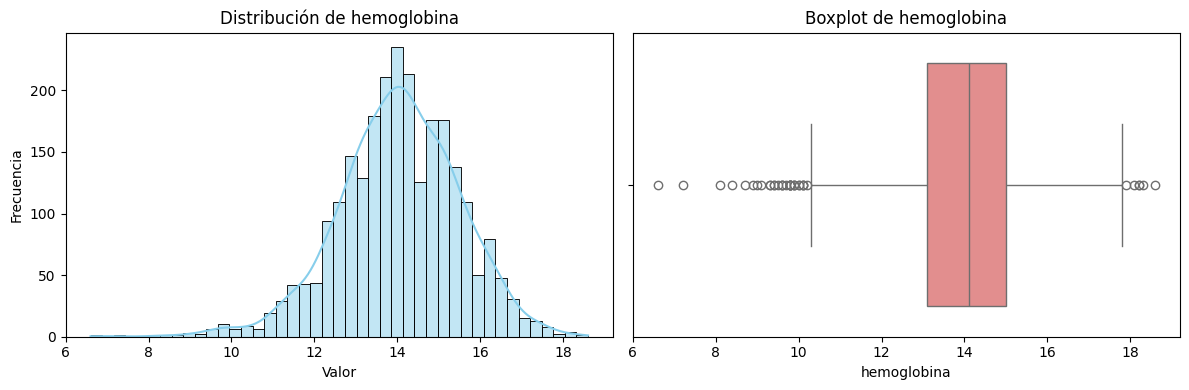

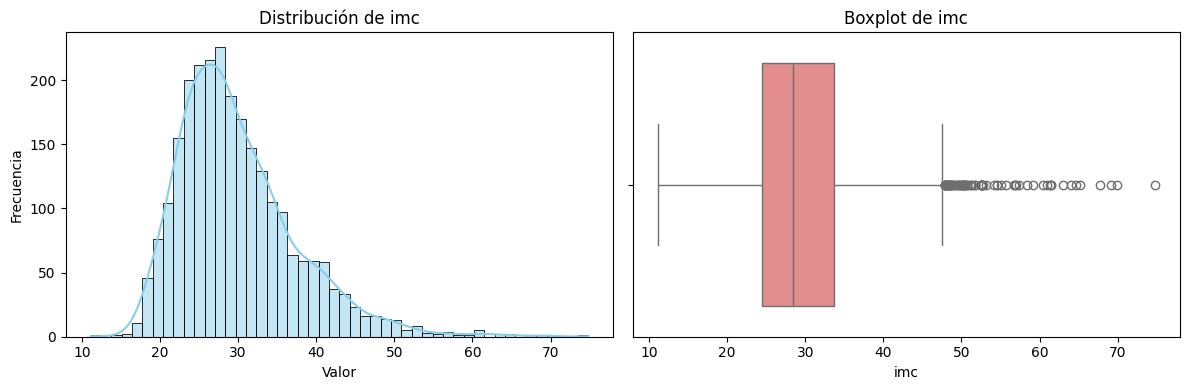

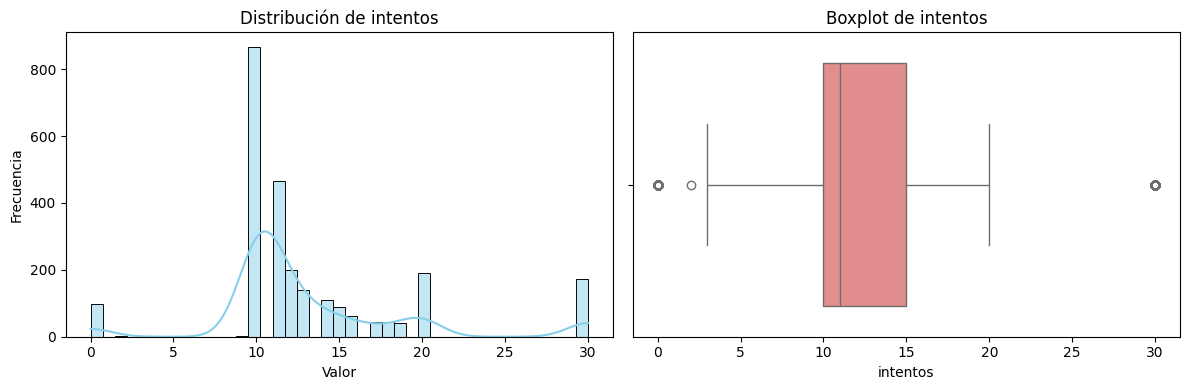

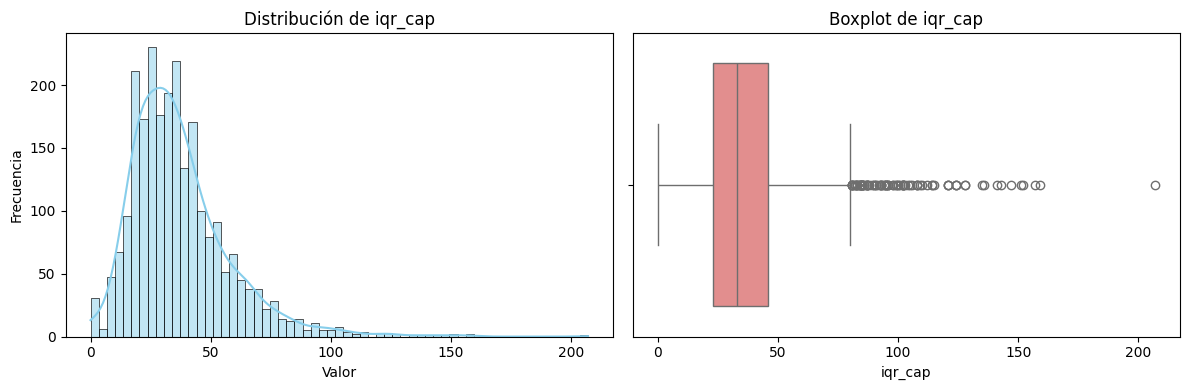

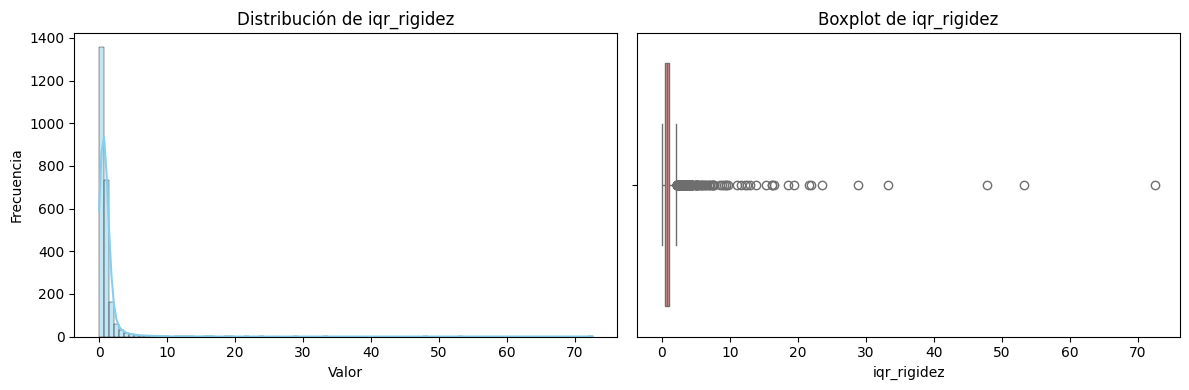

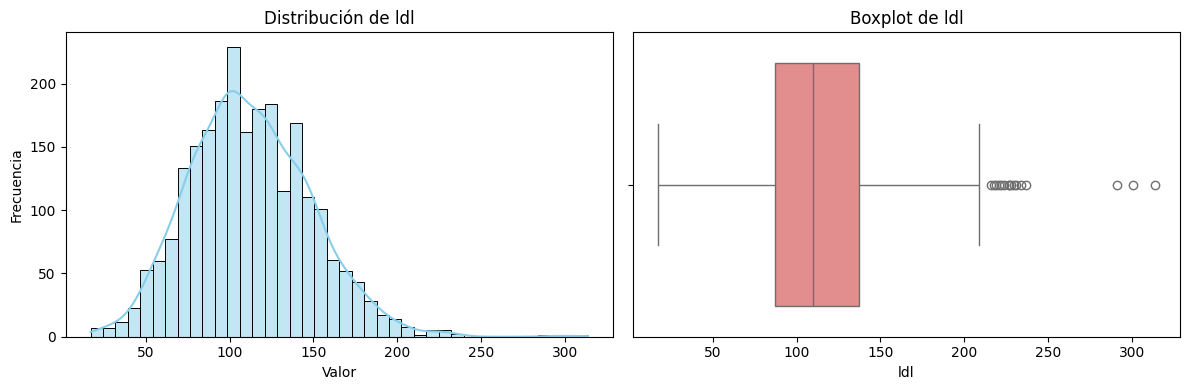

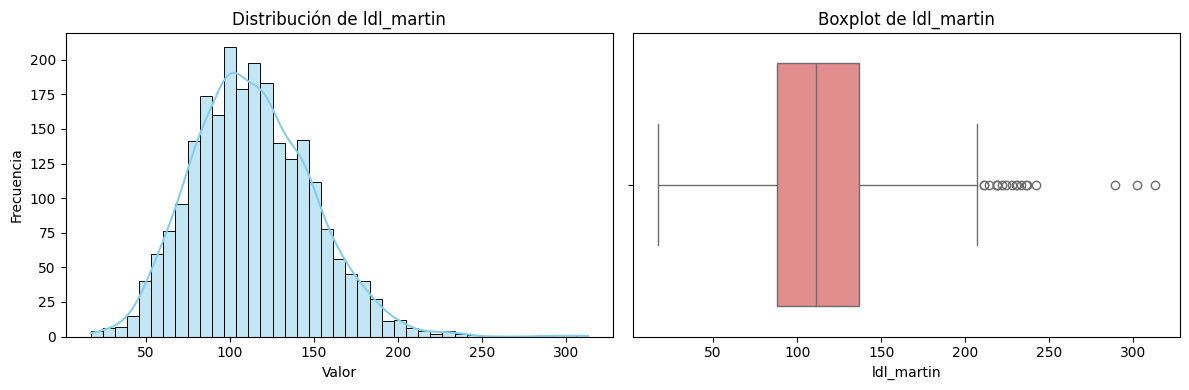

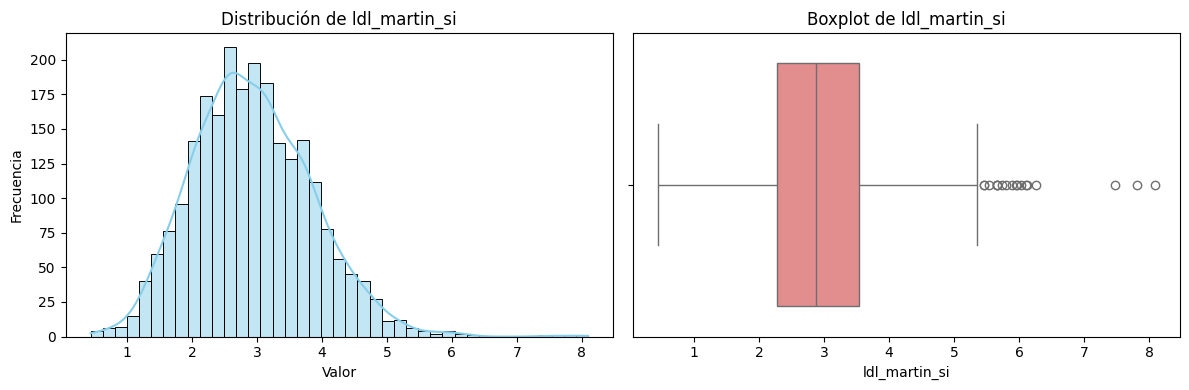

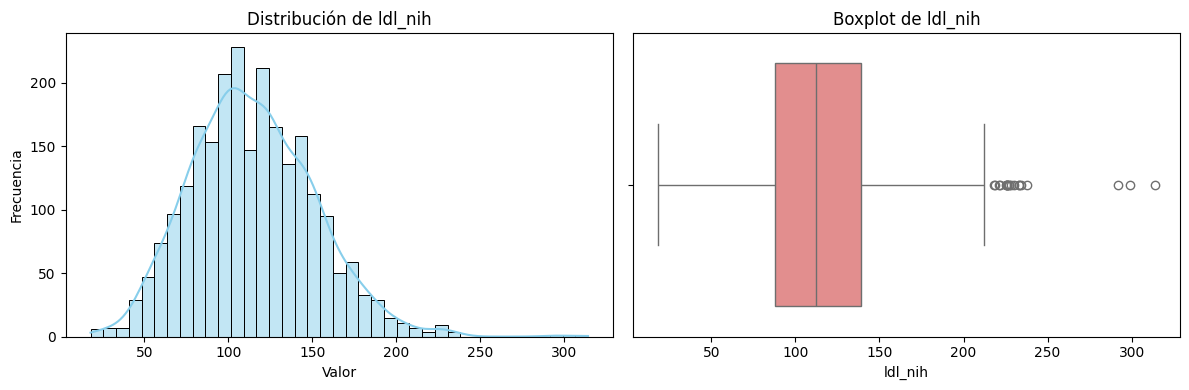

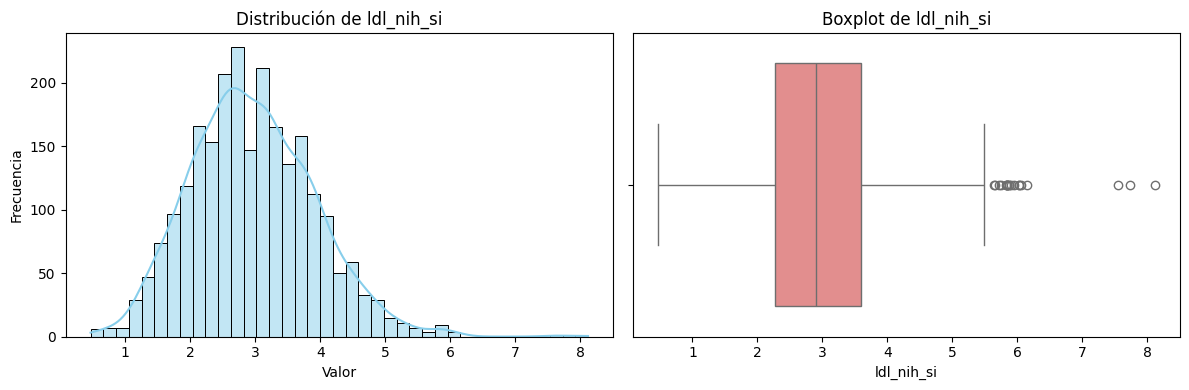

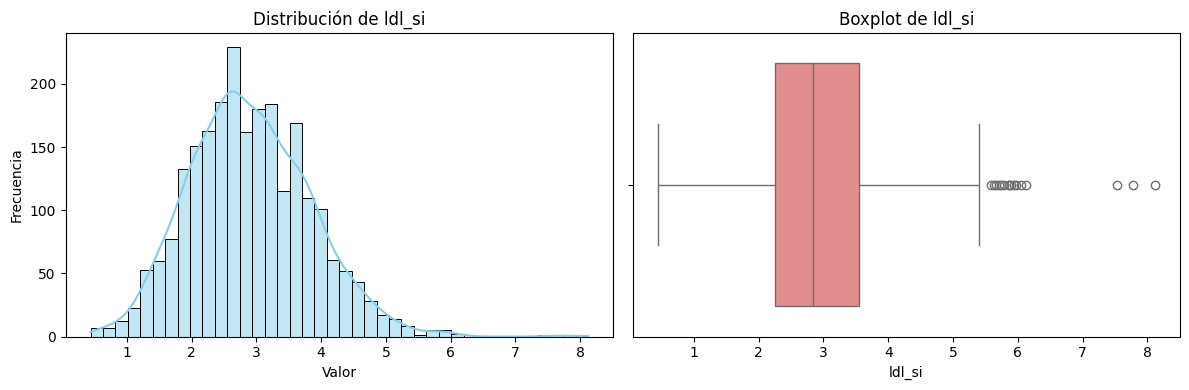

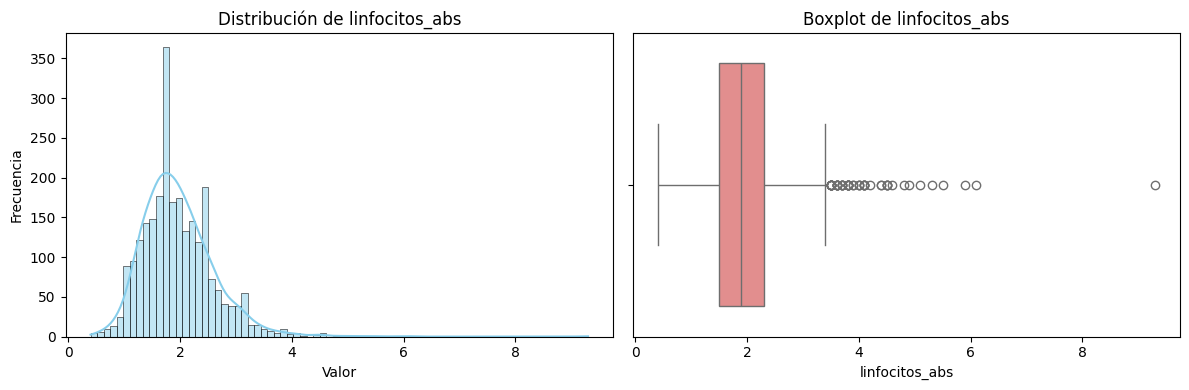

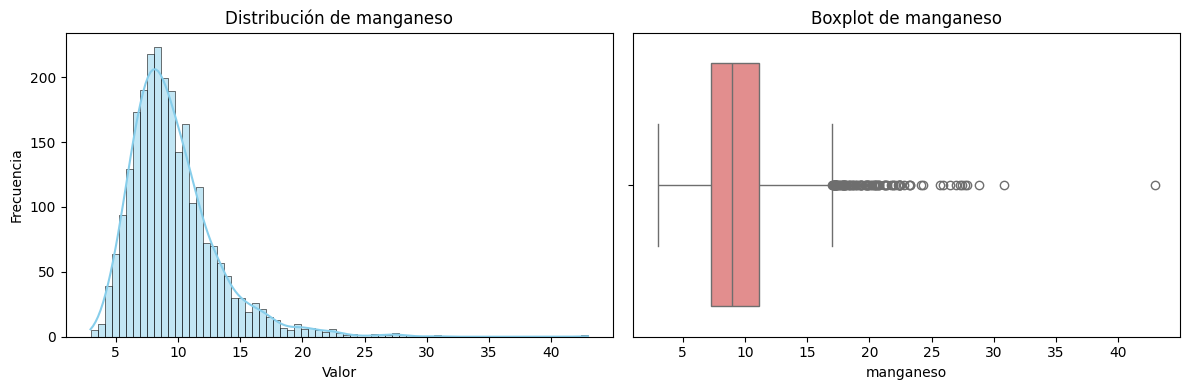

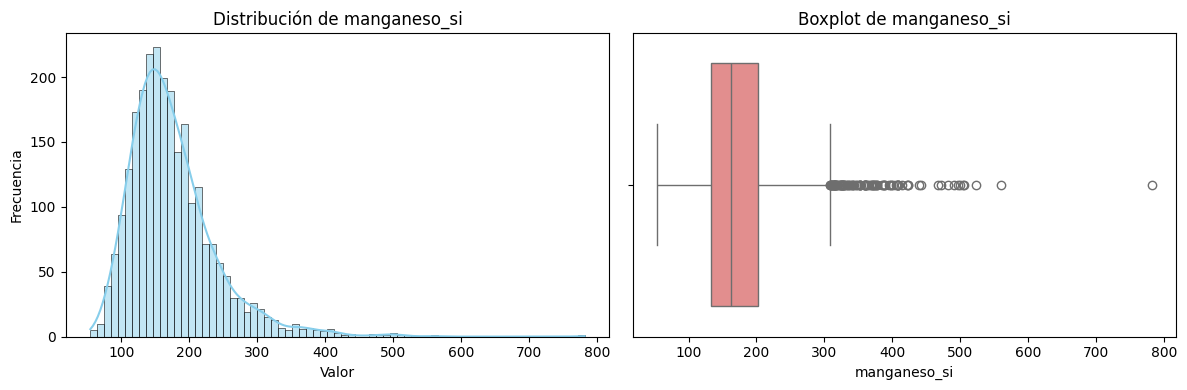

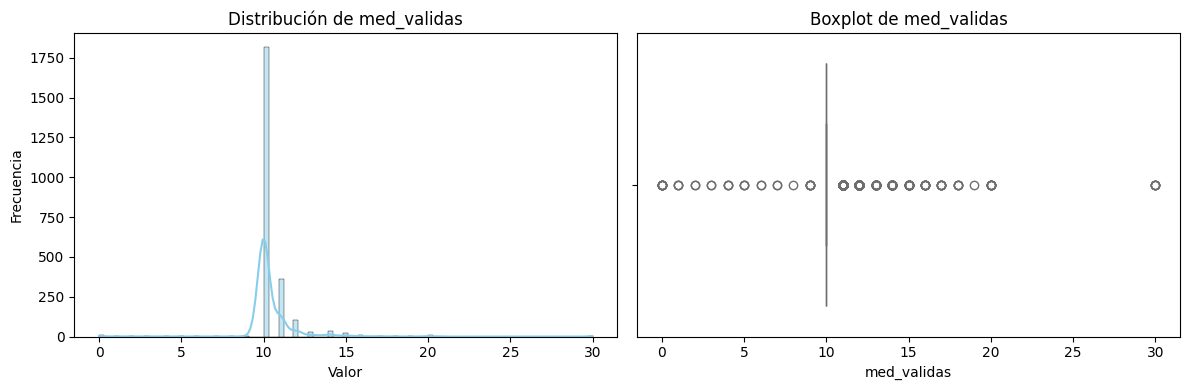

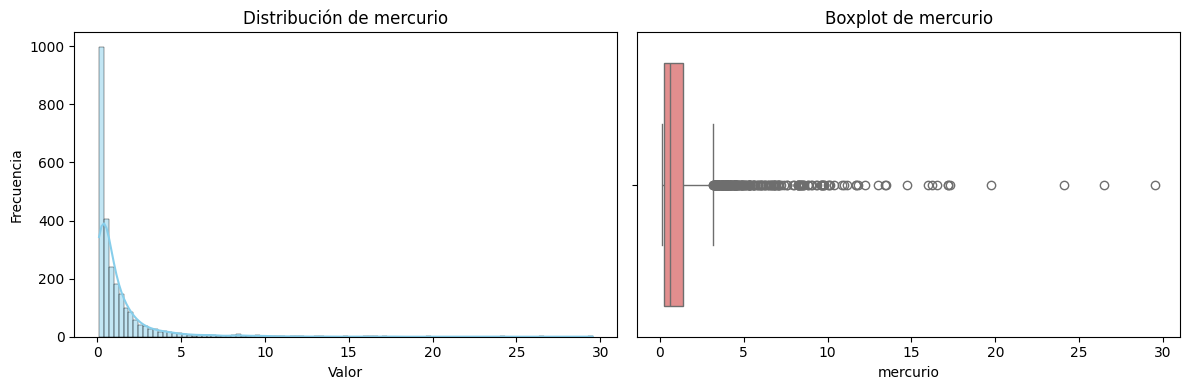

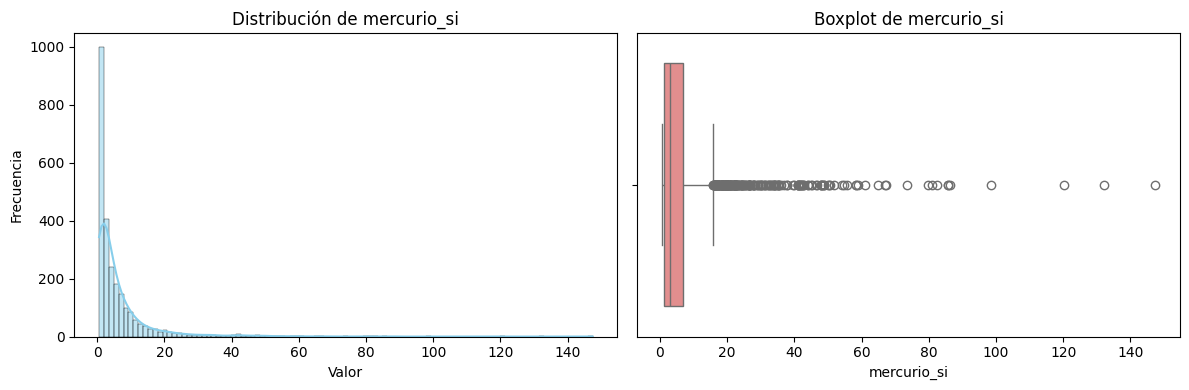

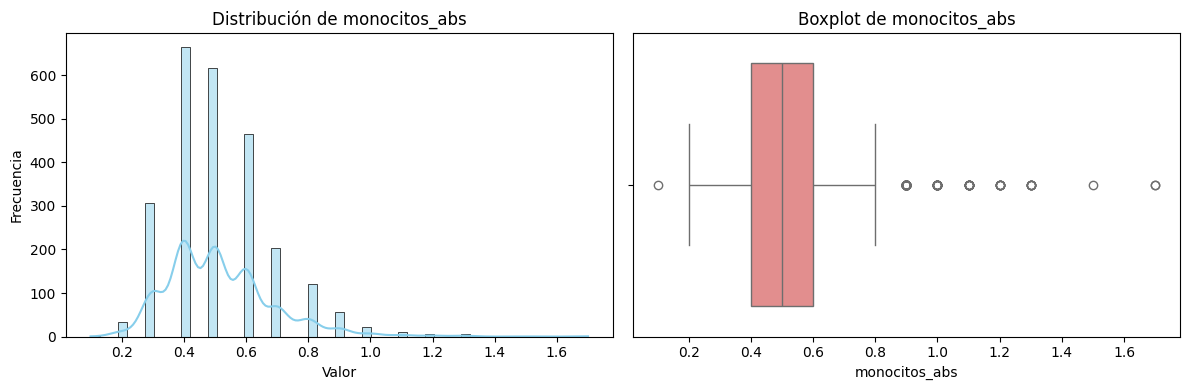

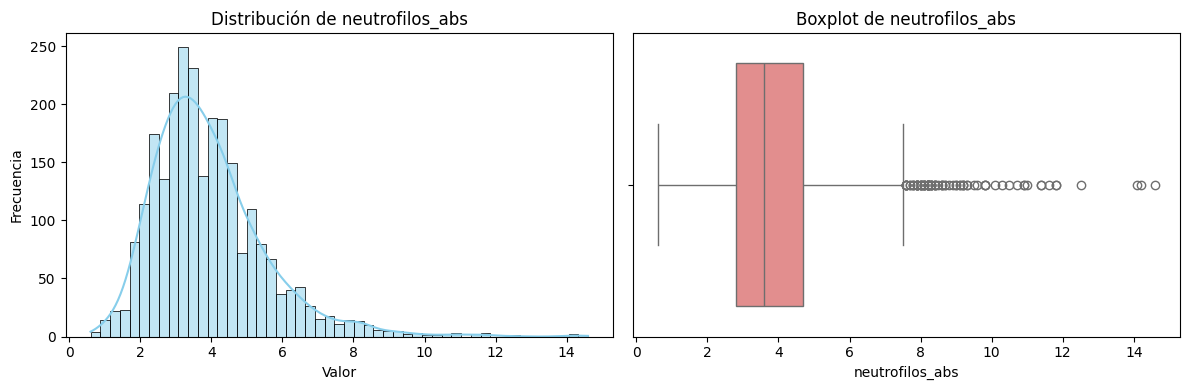

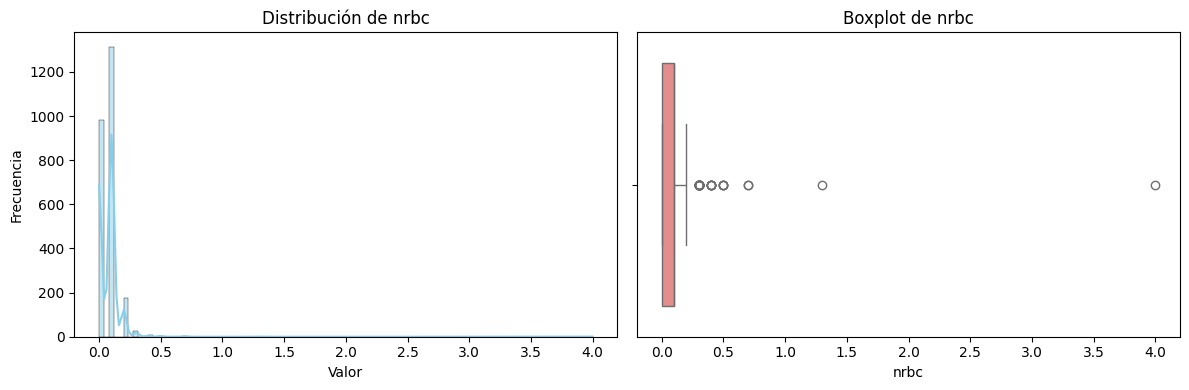

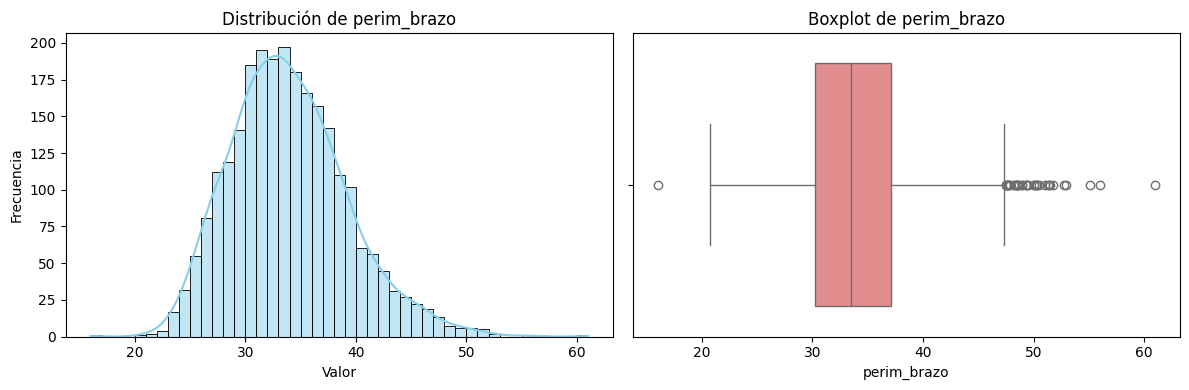

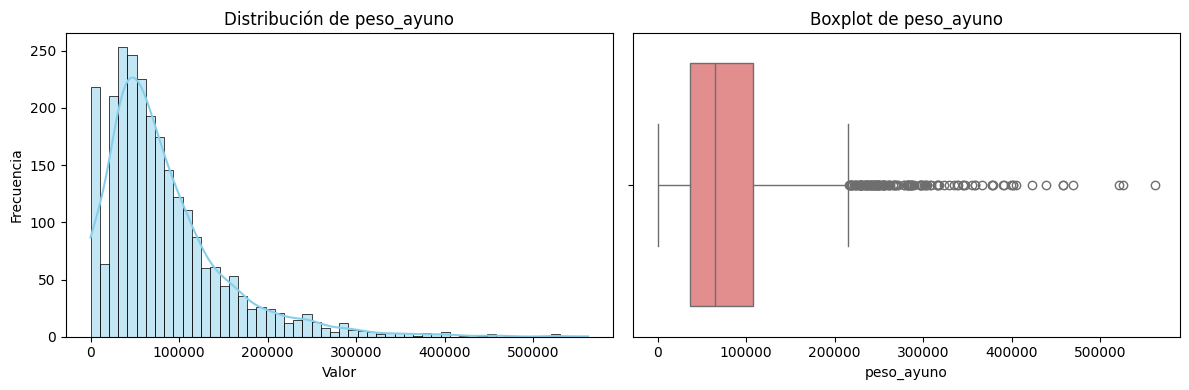

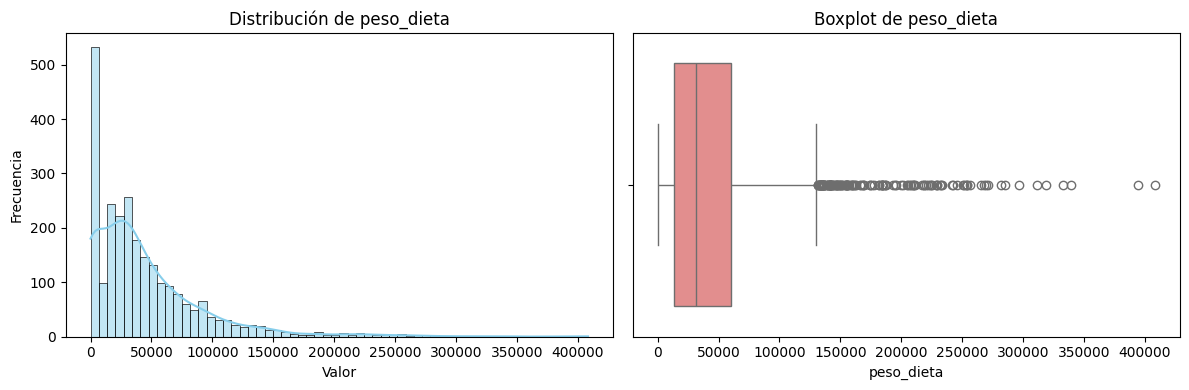

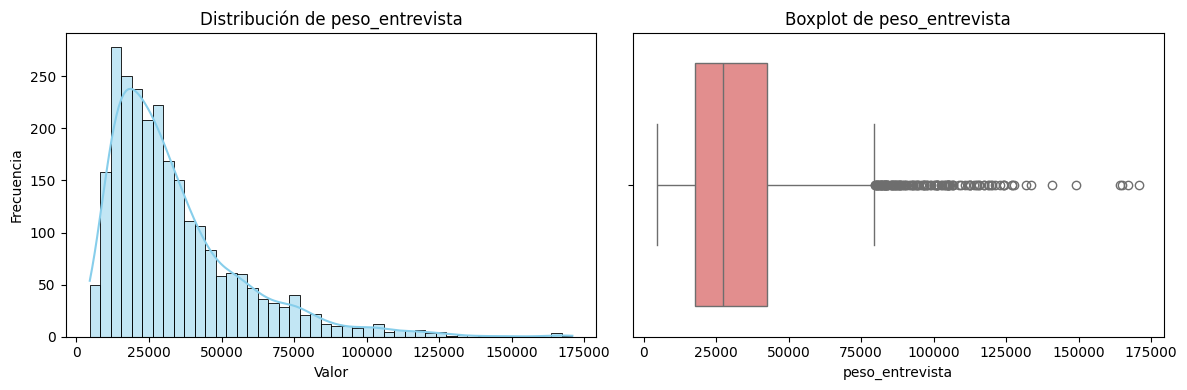

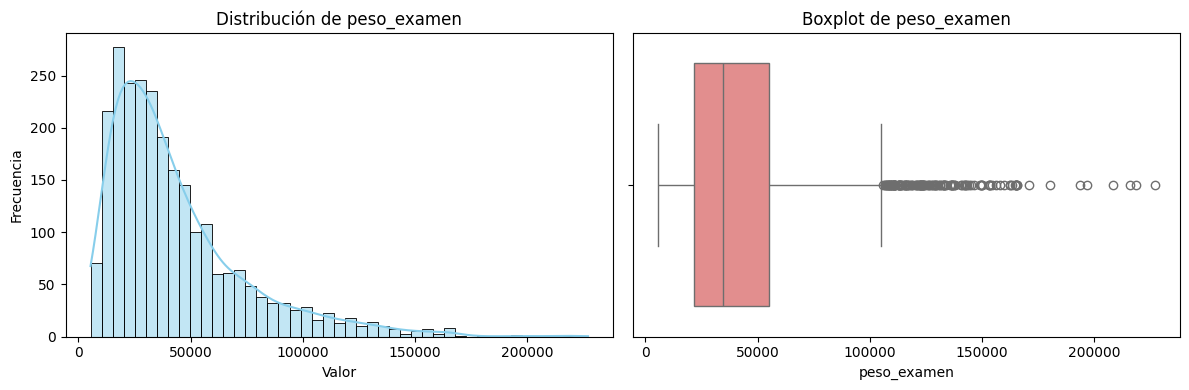

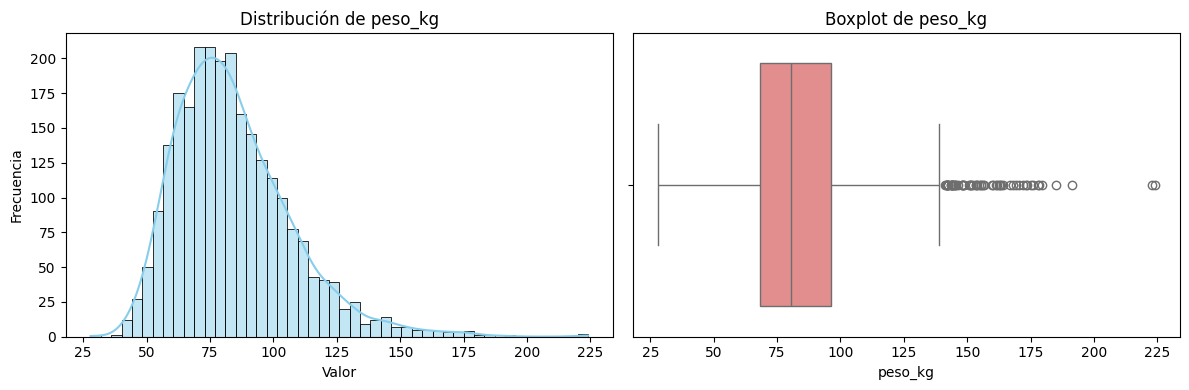

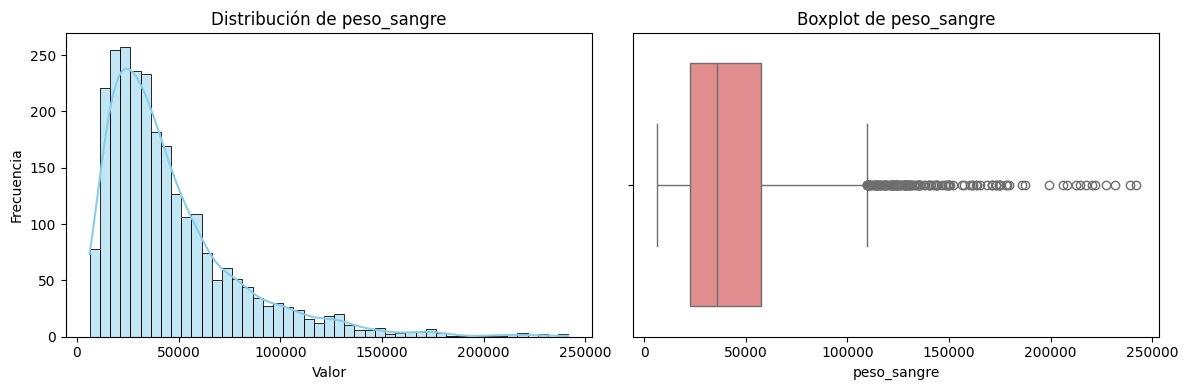

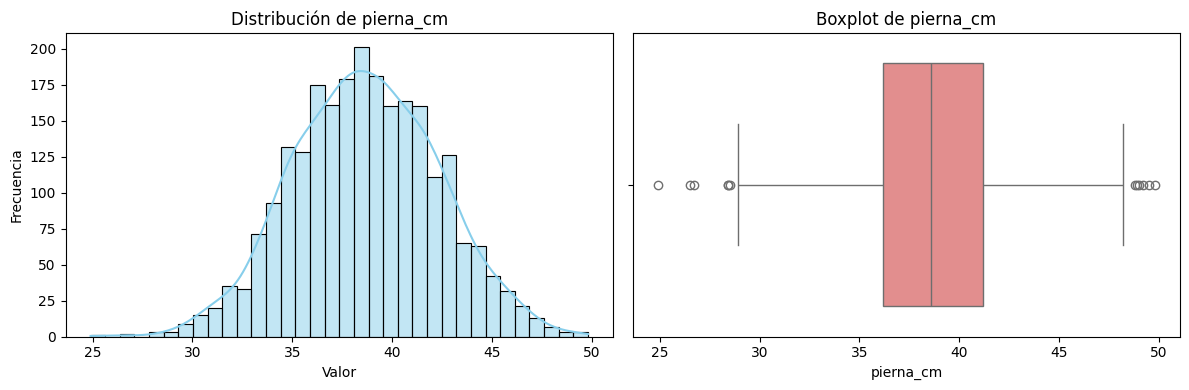

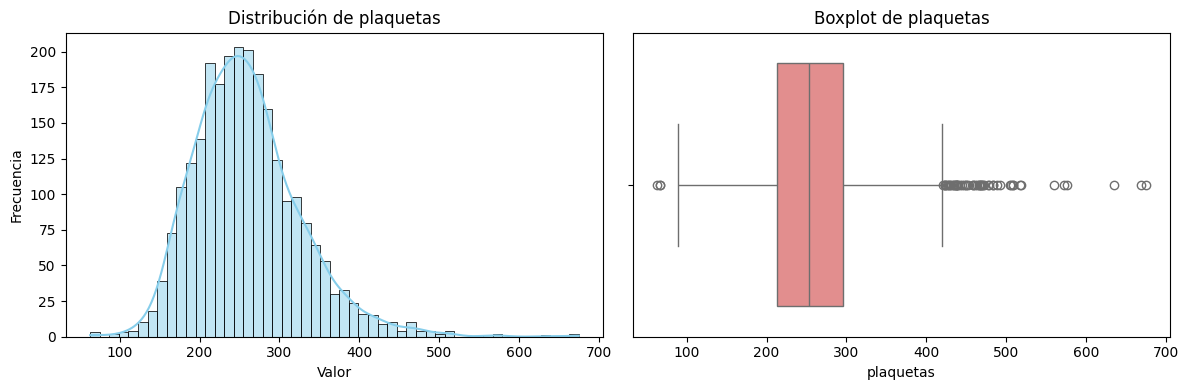

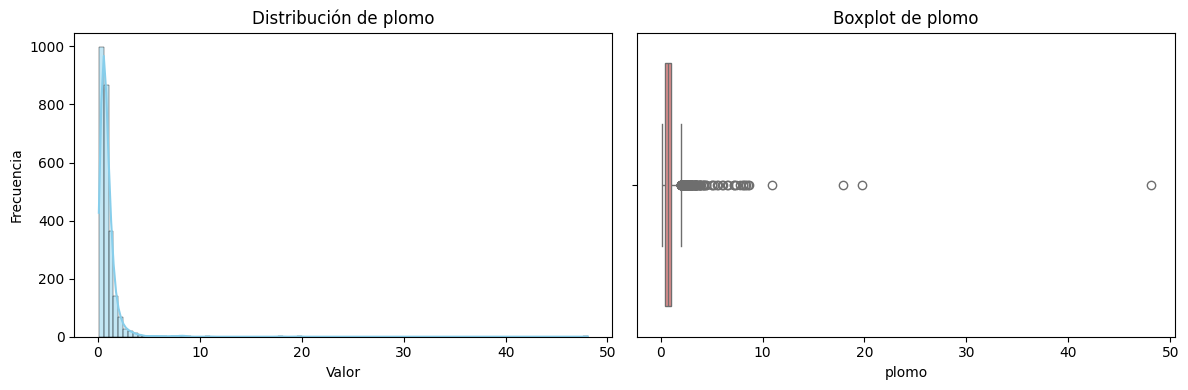

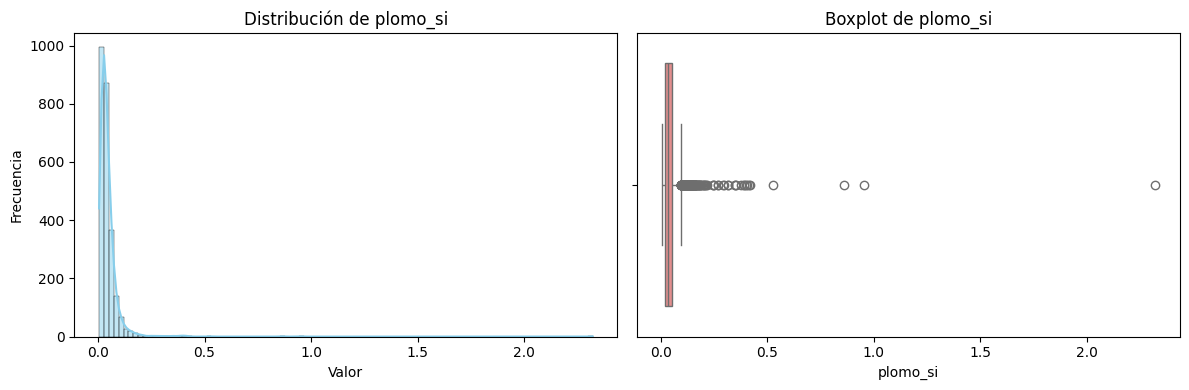

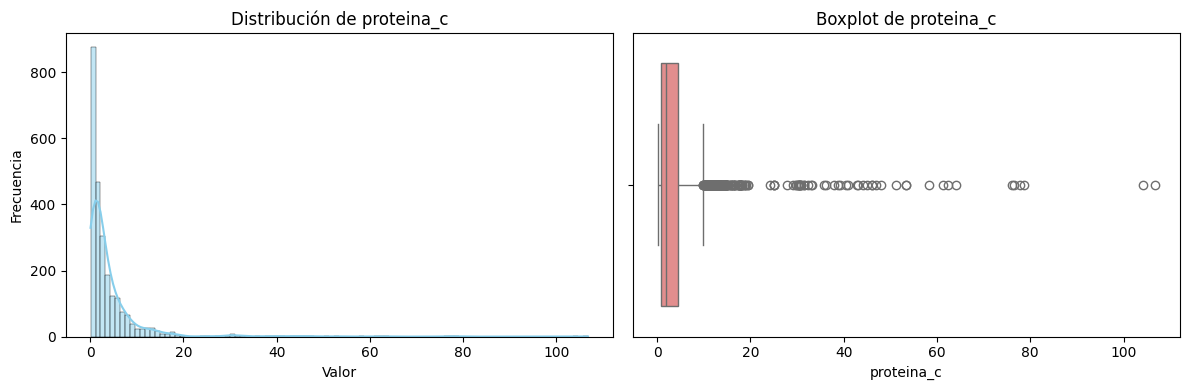

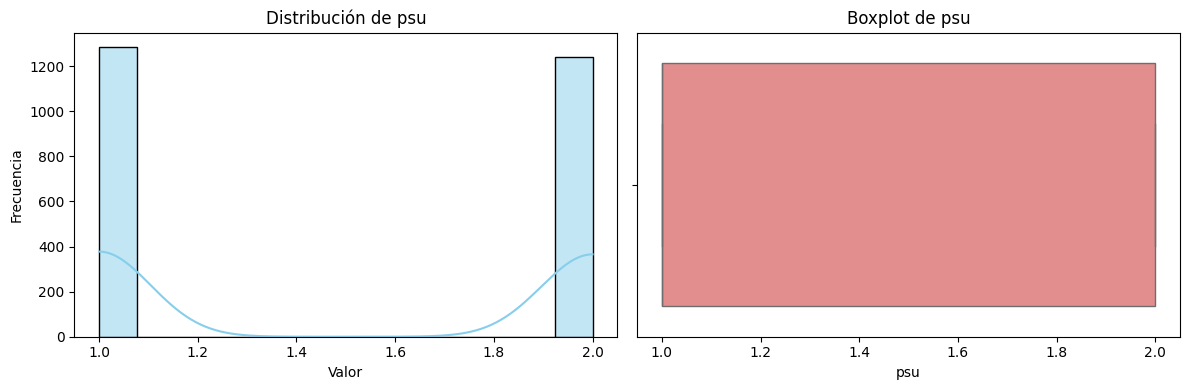

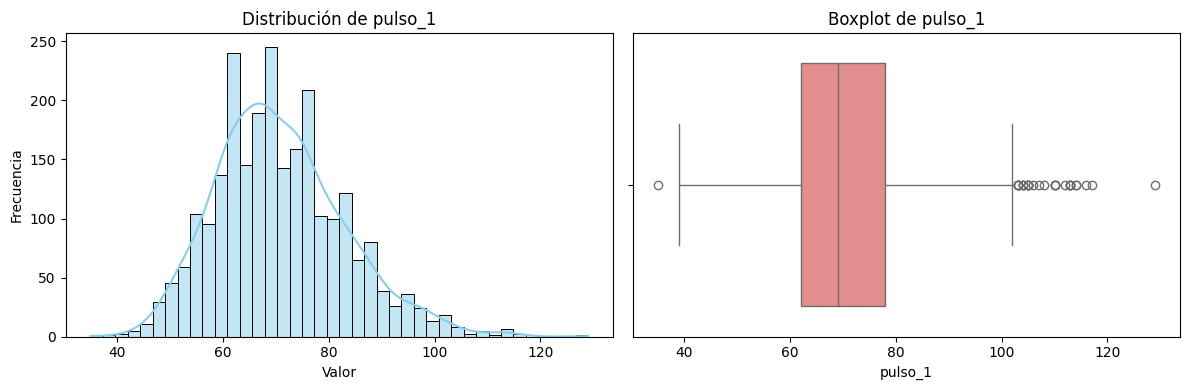

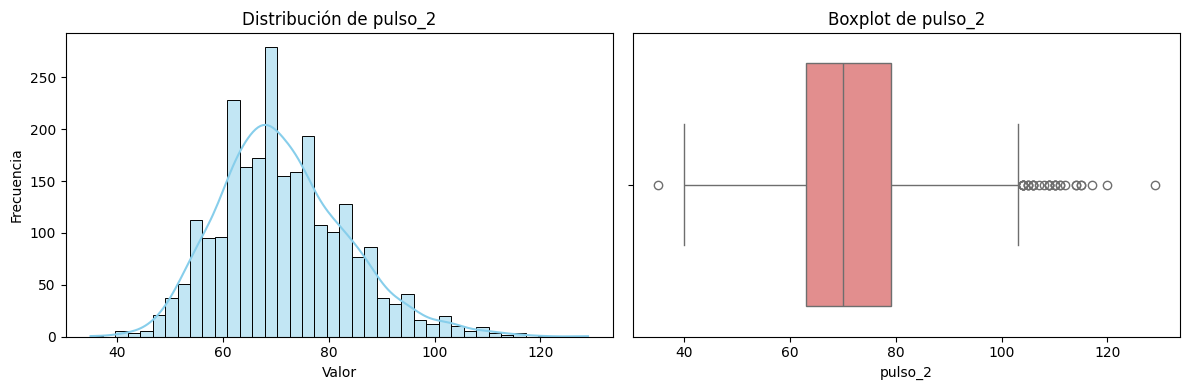

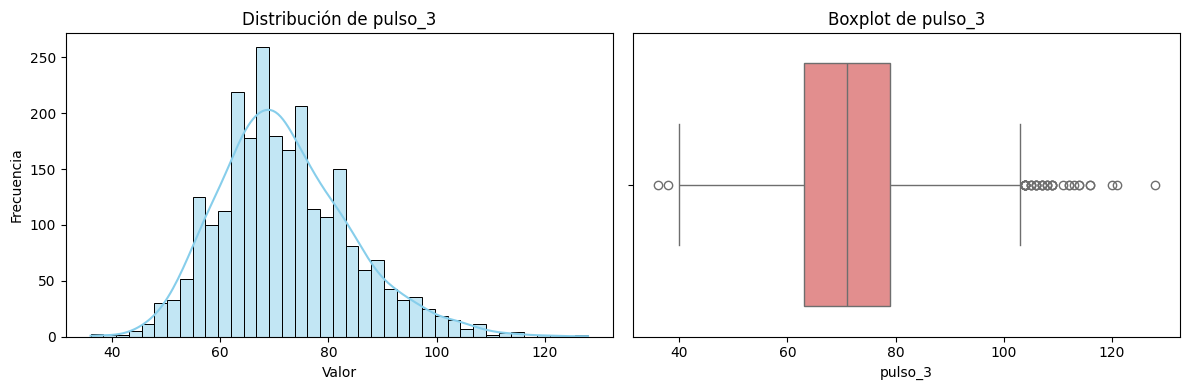

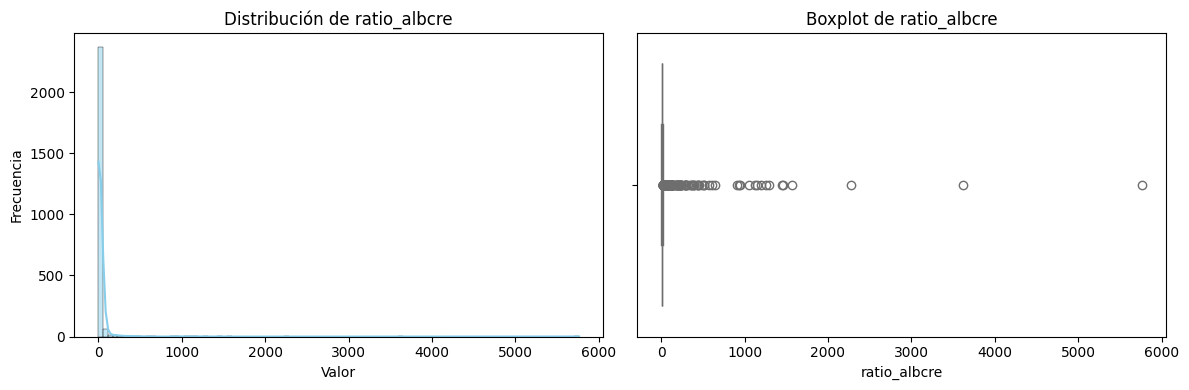

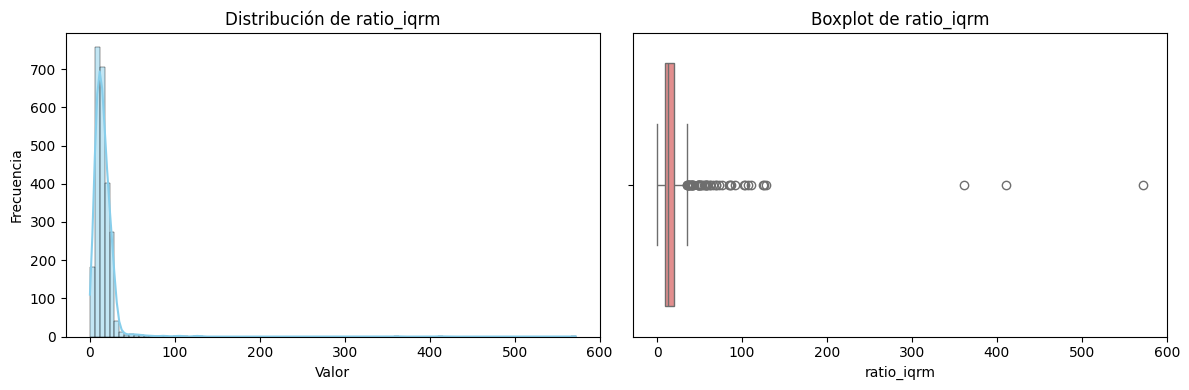

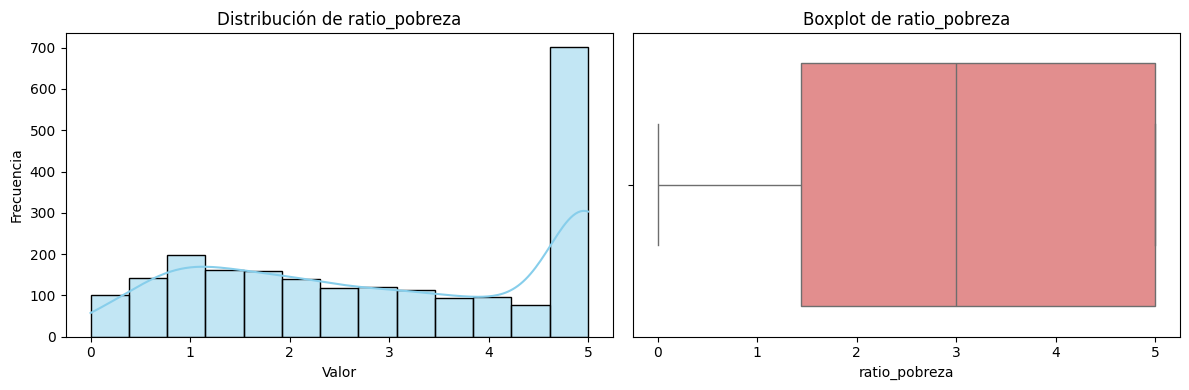

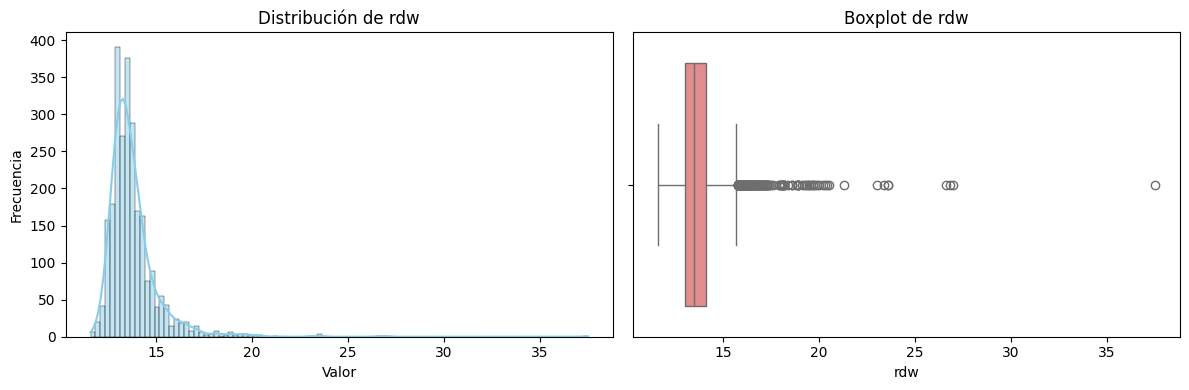

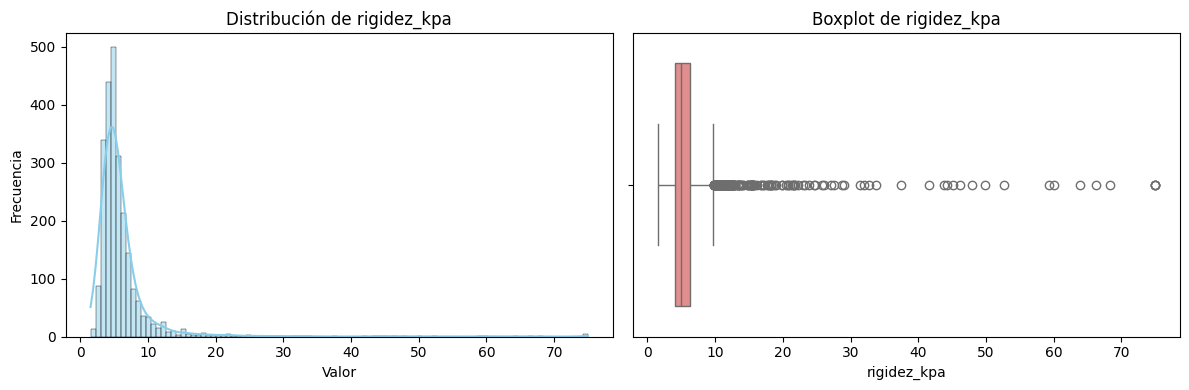

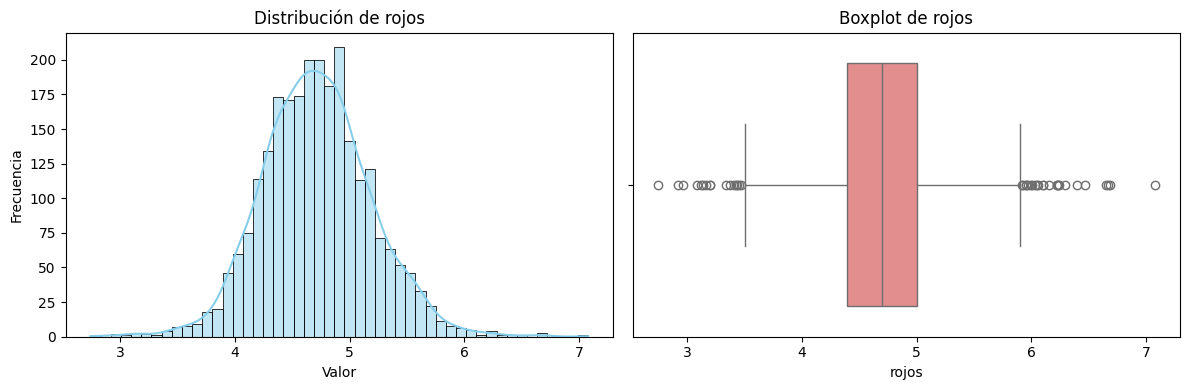

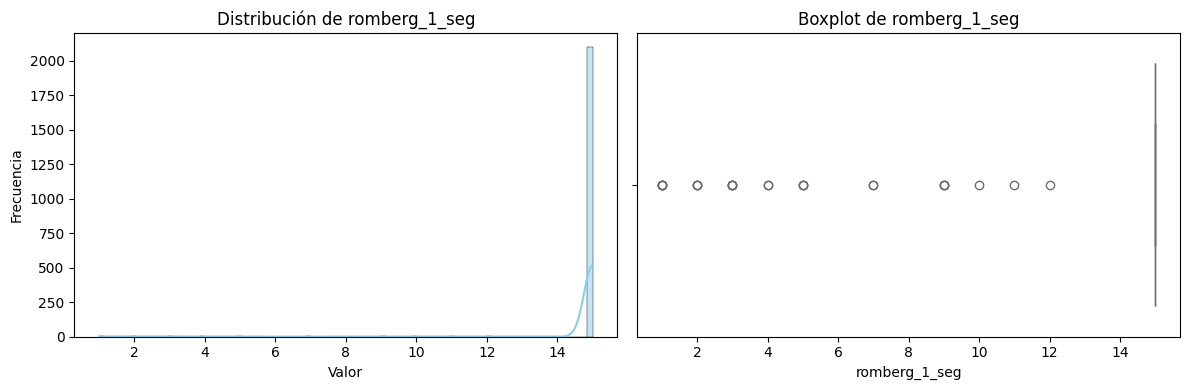

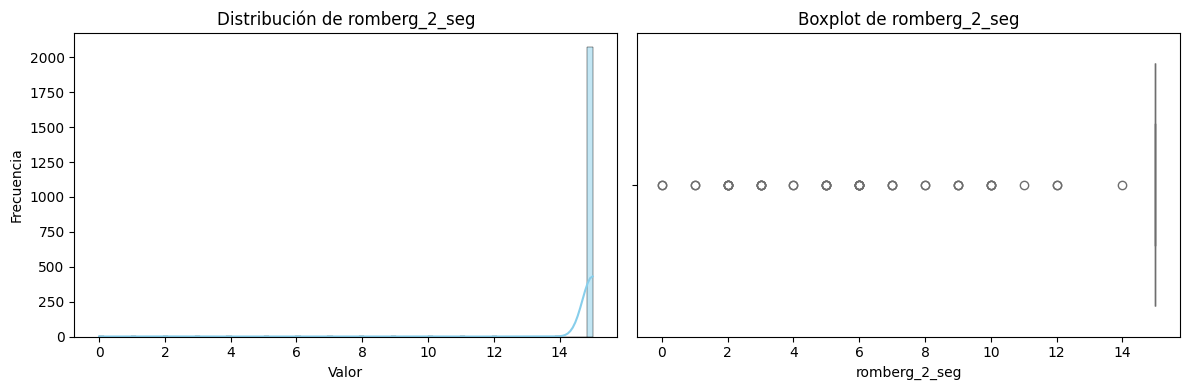

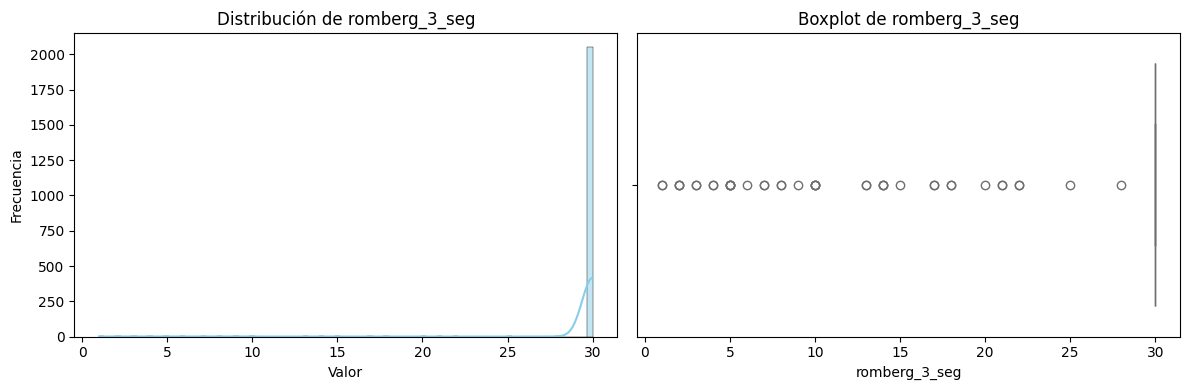

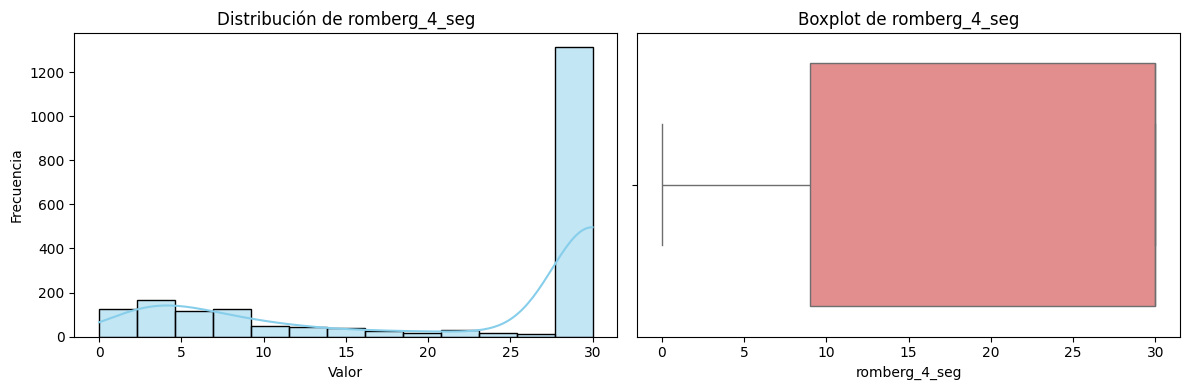

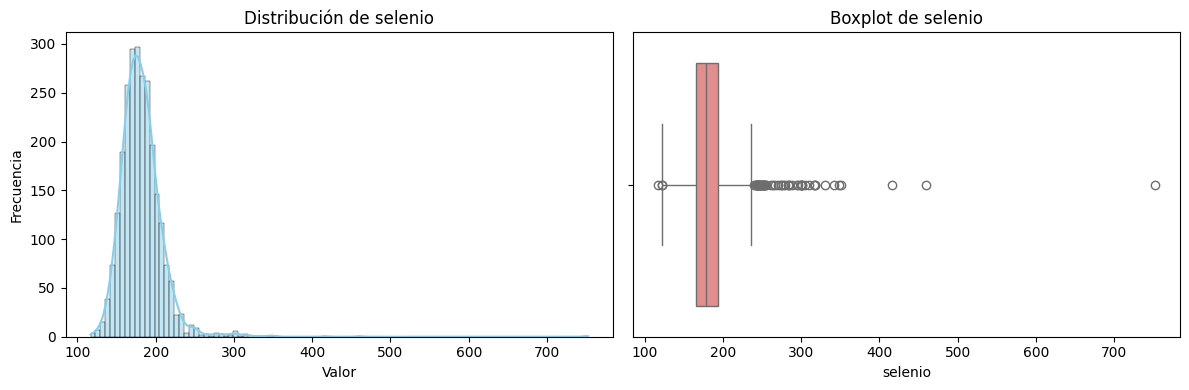

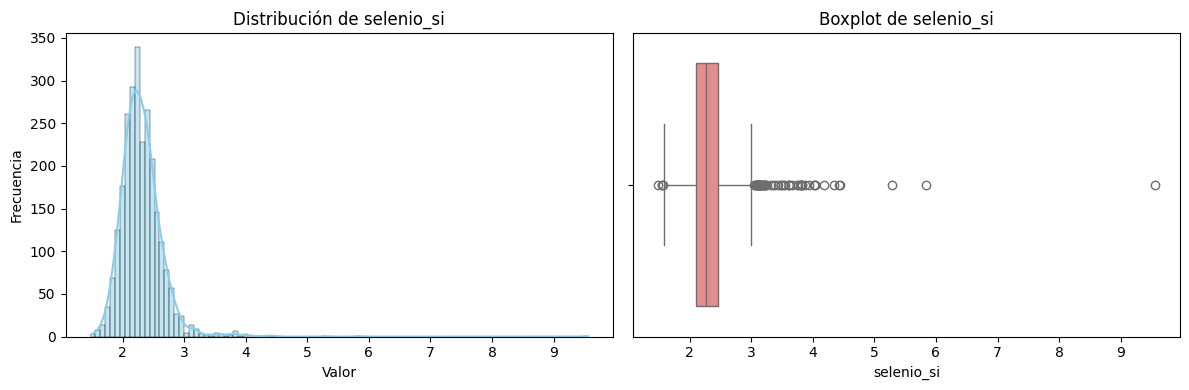

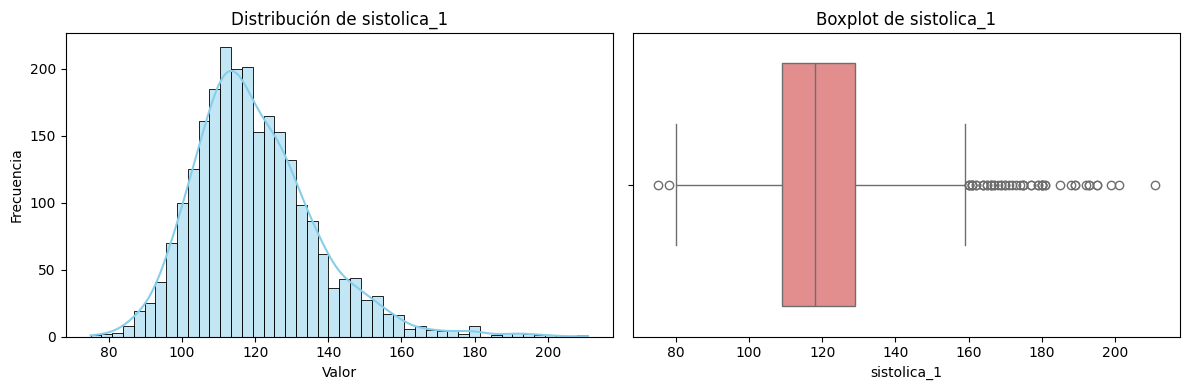

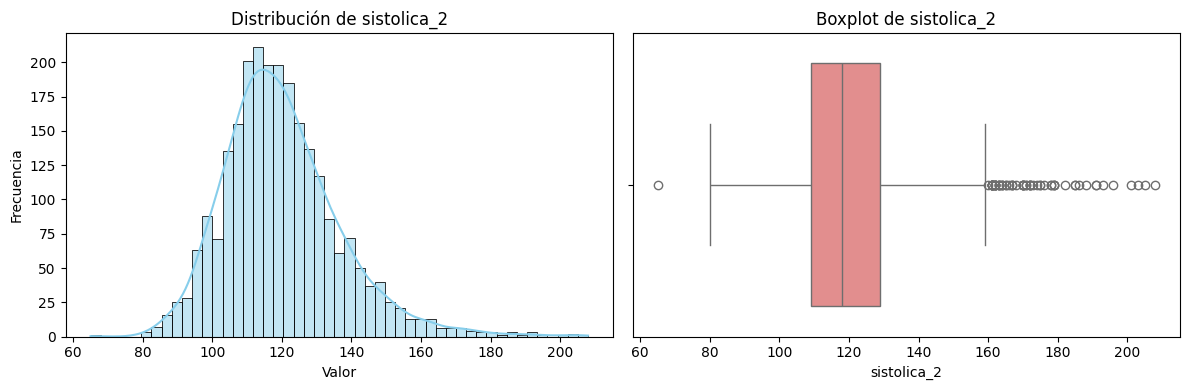

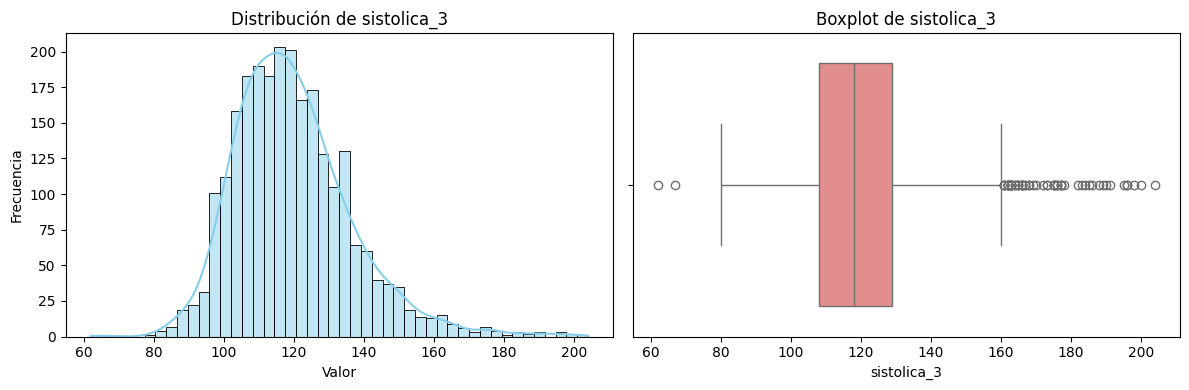

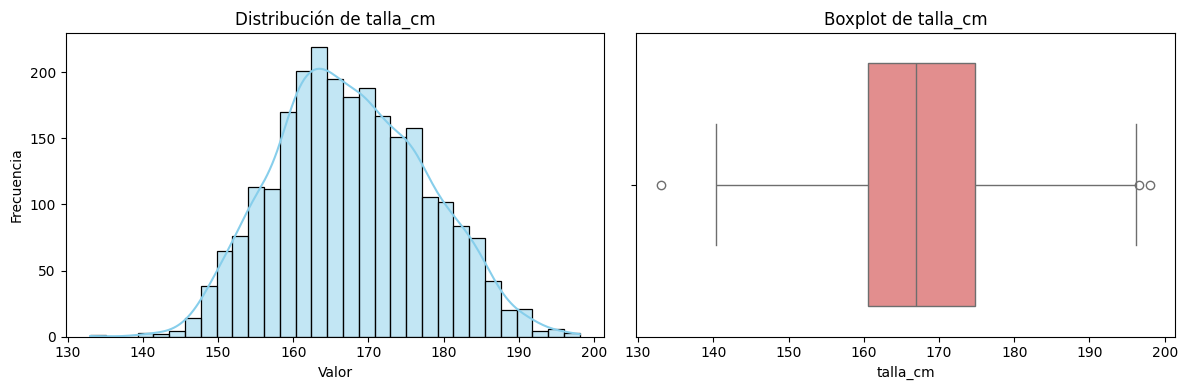

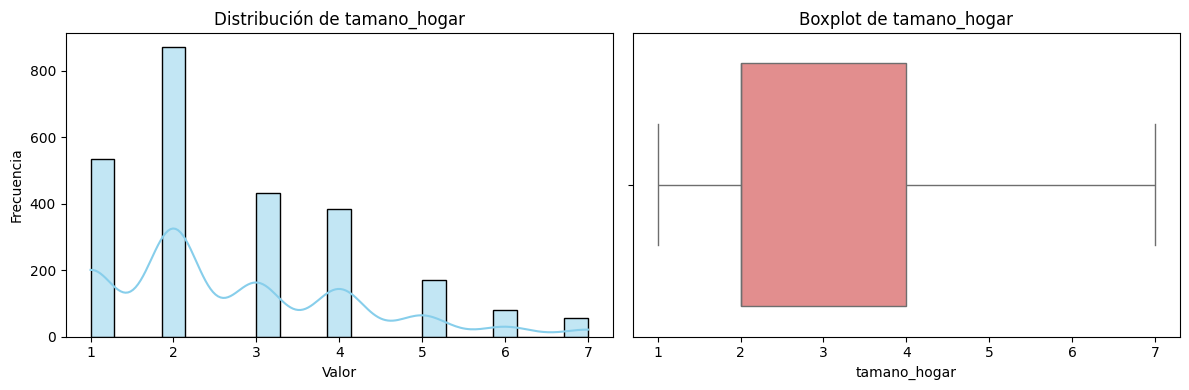

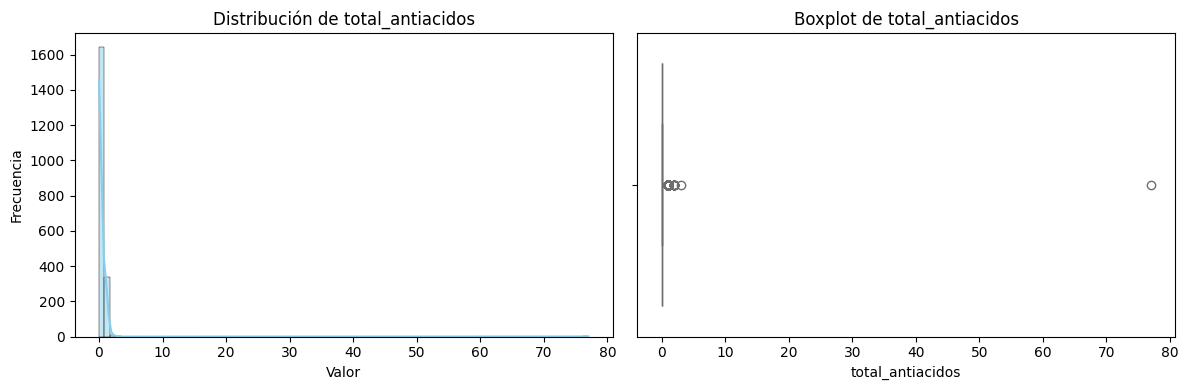

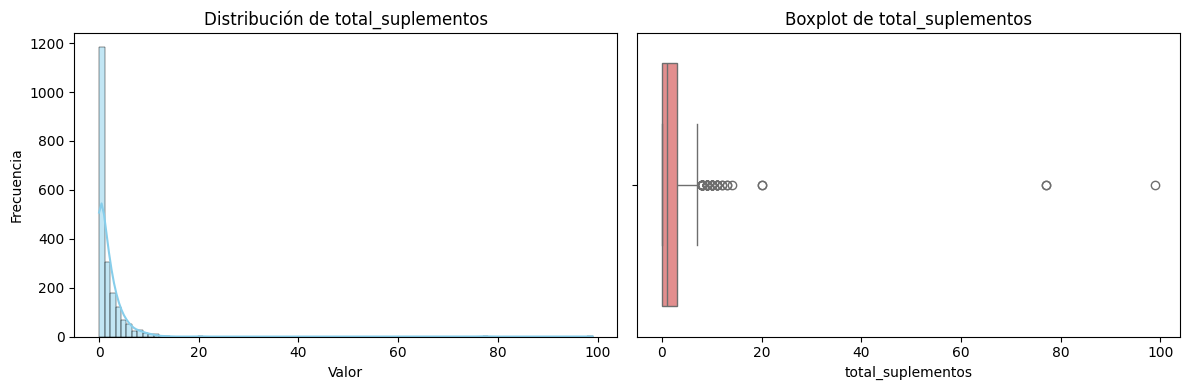

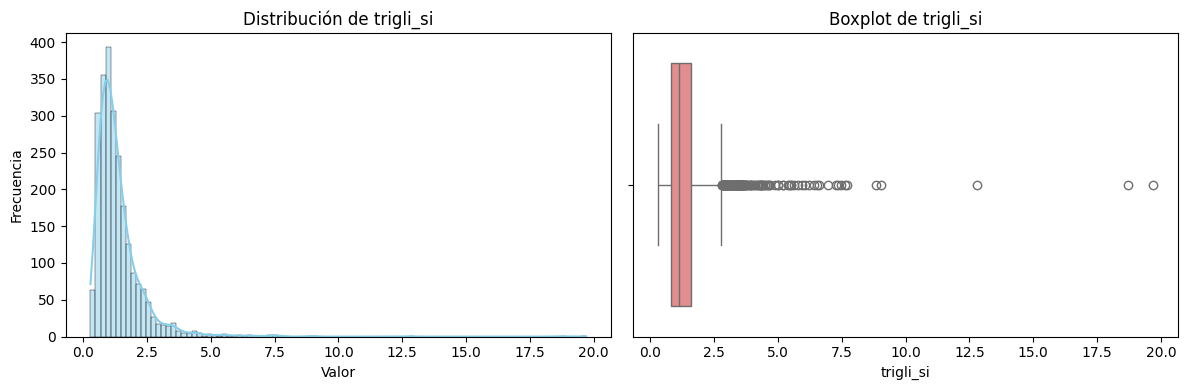

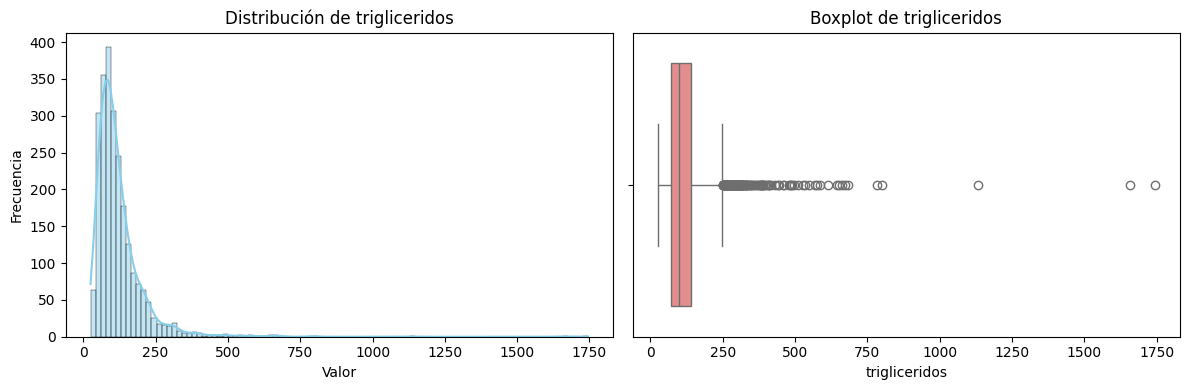

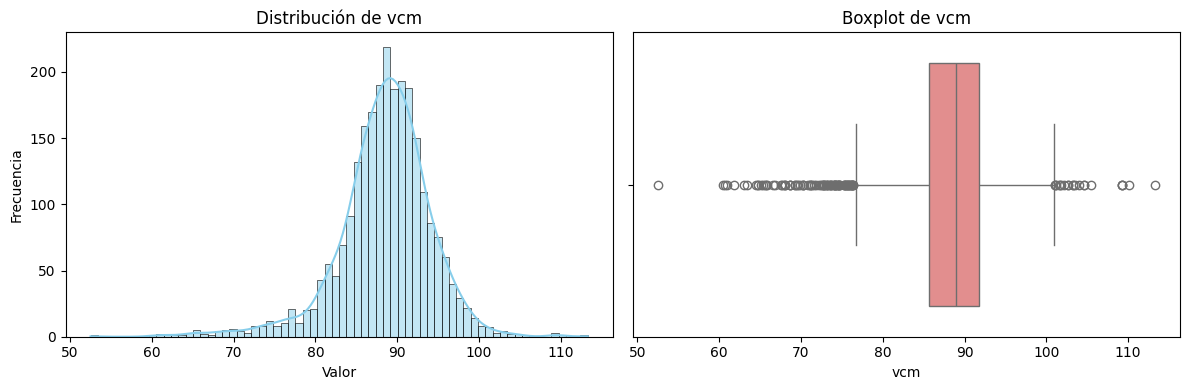

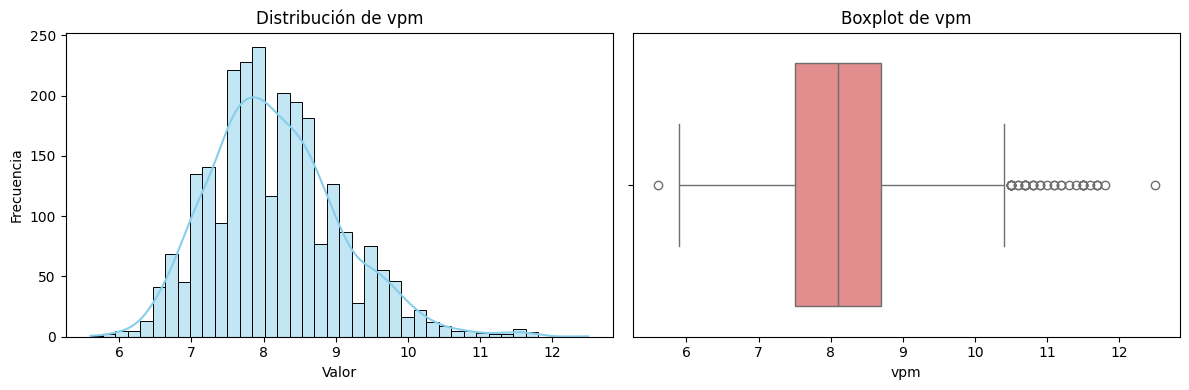

In [ ]:
# Definimos el número de variables a visualizar por tanda para no saturar el cuaderno
vars_a_revisar = cols_numericas # Puedes cambiar el rango o usar cols_numericas completa

for col in vars_a_revisar:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histograma con KDE 
    sns.histplot(df_clean_rows[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribución de {col}')
    axes[0].set_xlabel('Valor')
    axes[0].set_ylabel('Frecuencia')
    
    # Boxplot 
    sns.boxplot(x=df_clean_rows[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

In [44]:
def count_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((data < lower_bound) | (data > upper_bound)).sum()

# Creamos un resumen
outlier_summary = []
for col in cols_numericas:
    n_outliers = count_outliers(df[col].dropna())
    pct_outliers = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'Variable': col,
        'Num_Outliers': n_outliers,
        'Porcentaje': round(pct_outliers, 2)
    })

df_outliers = pd.DataFrame(outlier_summary).sort_values(by='Num_Outliers', ascending=False)

print("--- Outliers detectados ---")
print(df_outliers.to_string(index=False))
#TODO: Comentar!!

--- Outliers detectados ---
         Variable  Num_Outliers  Porcentaje
      med_validas           645       24.00
 total_antiacidos           365       13.58
         intentos           324       12.06
     ratio_albcre           319       11.87
   albumina_orina           304       11.31
       albmina_si           304       11.31
        cadmio_si           261        9.71
           cadmio           261        9.71
  eosinofilos_abs           232        8.63
      mercurio_si           219        8.15
         mercurio           219        8.15
       proteina_c           202        7.52
      rigidez_kpa           199        7.41
         plomo_si           170        6.33
      iqr_rigidez           170        6.33
            plomo           164        6.10
      peso_examen           150        5.58
              rdw           148        5.51
      peso_sangre           147        5.47
       peso_dieta           144        5.36
       peso_ayuno           141        5.25
    

- Hacer análisis de outliers, ¿los outliers coinciden con los pacientes que en la categoría presentan símtomas?

### Distribuciones por Categoría

Como ya sugiere la pregunta anterior, en este subapartado vamos a mirar la relación que existe entre las categorías y las variables numéricas.

Con esto buscamos si existe alguna relación entre ciertas categorías y los valores numéricos, de esta manera podemos comprobar si existe relación entre los outliers y determinadas categorías.

In [45]:
resultados = []

# =========================
# 1. Variables a usar
# =========================
cols_excluir = [
    'ciclo', 'estado', 'gnero', 'etnia_1',
    'etnia_3', 'mes_examen', 'pas_nacimiento'
]

cols_categoricas_filtradas = [col for col in cols_categoricas if col not in cols_excluir]
cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# opcional: limitar numéricas para no sacar demasiadas combinaciones
# cols_numericas = cols_numericas[:10]

# =========================
# 2. Bucle principal
# =========================
for cat_col in cols_categoricas_filtradas:
    for num_col in cols_numericas:
        
        data = df[[cat_col, num_col]].dropna().copy()
        
        # saltar si no hay datos o si la categórica tiene una sola categoría
        if data.empty or data[cat_col].nunique() < 2:
            continue
        
        # =========================
        # 3. Detectar outliers con IQR
        # =========================
        Q1 = data[num_col].quantile(0.25)
        Q3 = data[num_col].quantile(0.75)
        IQR = Q3 - Q1
        
        if IQR == 0:
            continue
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        data['outlier'] = ((data[num_col] < lower) | (data[num_col] > upper)).astype(int)
        
        # =========================
        # 4. Resumen por categoría
        # =========================
        resumen = data.groupby(cat_col, observed=False).agg(
            n_total=('outlier', 'count'),
            n_outliers=('outlier', 'sum')
        )
        
        resumen['pct_outliers'] = resumen['n_outliers'] / resumen['n_total'] * 100
        
        # quitar categorías sin observaciones válidas
        resumen = resumen[resumen['n_total'] > 0]
        
        if resumen.empty or resumen['n_outliers'].sum() == 0:
            continue
        
        # =========================
        # 5. Categoría con mayor % de outliers
        # =========================
        top_cat = resumen['pct_outliers'].idxmax()
        
        resultados.append({
            'variable_categorica': cat_col,
            'variable_numerica': num_col,
            'categoria_mas_outliers': top_cat,
            'n_total_categoria': int(resumen.loc[top_cat, 'n_total']),
            'n_outliers_categoria': int(resumen.loc[top_cat, 'n_outliers']),
            'pct_outliers_categoria': round(resumen.loc[top_cat, 'pct_outliers'], 2)
        })

# =========================
# 6. DataFrame final
# =========================
df_outliers = pd.DataFrame(resultados)

# ordenar por porcentaje, no por número absoluto
df_outliers = df_outliers.sort_values(
    by='pct_outliers_categoria',
    ascending=False
).reset_index(drop=True)

# mostrar los 20 más llamativos
display(df_outliers)

,variable_categorica,variable_numerica,categoria_mas_outliers,n_total_categoria,n_outliers_categoria,pct_outliers_categoria
0,caidas,cadmio,9.0,1,1,100.00
1,caidas,mercurio,9.0,1,1,100.00
2,caidas,cadmio_si,9.0,1,1,100.00
3,caidas,mercurio_si,9.0,1,1,100.00
4,romberg_2_res,sistolica_2,7.0,1,1,100.00
...,...,...,...,...,...,...
2067,diag_osteoporosis,talla_cm,1.0,2221,1,0.05
2068,romberg_1_res,talla_cm,1.0,2188,1,0.05
2069,med_osteoporosis,talla_cm,2.0,1848,1,0.05
2070,romberg_2_res,talla_cm,1.0,2162,1,0.05


In [46]:
# # =========================
# # 1. Variables a usar
# # =========================
# cols_excluir = [
#     'ciclo', 'estado', 'gnero', 'etnia_1',
#     'etnia_3', 'mes_examen', 'pas_nacimiento'
# ]

# cols_categoricas_filtradas = [col for col in cols_categoricas if col not in cols_excluir]
# cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# print(f"Número de variables categóricas usadas: {len(cols_categoricas_filtradas)}")
# print(f"Número de variables numéricas usadas: {len(cols_numericas)}")

# # =========================
# # 2. Carpeta de salida
# # =========================
# carpeta_salida = "boxplots_numericas_por_categoria"
# os.makedirs(carpeta_salida, exist_ok=True)

# # =========================
# # 3. Parámetros de visualización
# # =========================
# n_cols = 3   # nº de gráficos por fila
# n_cats = len(cols_categoricas_filtradas)
# n_rows = math.ceil(n_cats / n_cols)

# # =========================
# # 4. Crear una imagen por variable numérica
# # =========================
# for num_col in cols_numericas:
    
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
#     axes = axes.flatten()
    
#     for i, cat_col in enumerate(cols_categoricas_filtradas):
#         ax = axes[i]
        
#         data_plot = df[[cat_col, num_col]].dropna().copy()
        
#         if data_plot.empty or data_plot[cat_col].nunique() < 2:
#             ax.set_visible(False)
#             continue
        
#         sns.boxplot(
#             data=data_plot,
#             x=cat_col,
#             y=num_col,
#             ax=ax
#         )
        
#         ax.set_title(f"{num_col} según {cat_col}", fontsize=11)
#         ax.set_xlabel(cat_col)
#         ax.set_ylabel(num_col)
#         ax.tick_params(axis='x', rotation=45)
    
#     # Ocultar ejes vacíos
#     for j in range(len(cols_categoricas_filtradas), len(axes)):
#         axes[j].set_visible(False)
    
#     plt.tight_layout()
    
#     # Guardar imagen
#     ruta_salida = os.path.join(carpeta_salida, f"{num_col}.png")
#     plt.savefig(ruta_salida, dpi=300, bbox_inches='tight')
#     # plt.show()
#     plt.close(fig)

# print(f"Imágenes guardadas en la carpeta: {carpeta_salida}")

## Correlaciones

In [70]:
df = pd.read_csv('otros/DataframeFinal.csv')

--- Estadísticos Principales ---


,ciclo,estado,genero,edad,etnia_1,etnia_3,mes_examen,pais_nacimiento,tamano_hogar,peso_entrevista,...,com_cadmio,mercurio,mercurio_si,com_mercurio,selenio,selenio_si,com_selenio,manganeso,manganeso_si,com_manganeso
count,2687.0,2687.0,2687.000000,2687.000000,2687.000000,2687.000000,2687.000000,2687.000000,2687.00000,2687.000000,...,2.559000e+03,2559.000000,2559.000000,2.559000e+03,2559.000000,2559.000000,2.559000e+03,2559.000000,2559.000000,2.559000e+03
mean,12.0,2.0,1.564198,48.335690,3.092296,3.272795,1.533309,1.222553,2.71083,33744.555021,...,9.378664e-03,1.259043,6.283251,1.805393e-01,181.654592,2.306952,5.397605e-79,9.615397,175.019500,5.397605e-79
std,0.0,0.0,0.495954,14.547777,1.022660,1.415666,0.498982,0.416038,1.48789,22776.816386,...,9.640714e-02,2.095819,10.457813,3.847112e-01,28.278765,0.359172,0.000000e+00,3.529724,64.248113,0.000000e+00
min,12.0,2.0,1.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.00000,4584.463196,...,5.397605e-79,0.120000,0.600000,5.397605e-79,116.700000,1.480000,5.397605e-79,2.980000,54.240000,5.397605e-79
25%,12.0,2.0,1.000000,35.000000,3.000000,3.000000,1.000000,1.000000,2.00000,17778.792108,...,5.397605e-79,0.230000,1.150000,5.397605e-79,165.100000,2.100000,5.397605e-79,7.270000,132.330000,5.397605e-79
50%,12.0,2.0,2.000000,50.000000,3.000000,3.000000,2.000000,1.000000,2.00000,27280.243838,...,5.397605e-79,0.580000,2.890000,5.397605e-79,178.700000,2.270000,5.397605e-79,8.960000,163.090000,5.397605e-79
75%,12.0,2.0,2.000000,62.000000,3.000000,3.000000,2.000000,1.000000,4.00000,42464.315819,...,5.397605e-79,1.425000,7.115000,5.397605e-79,193.900000,2.460000,5.397605e-79,11.170000,203.320000,5.397605e-79
max,12.0,2.0,2.000000,69.000000,5.000000,7.000000,2.000000,2.000000,7.00000,170968.343177,...,1.000000e+00,29.540000,147.400000,1.000000e+00,752.400000,9.560000,5.397605e-79,42.950000,781.780000,5.397605e-79


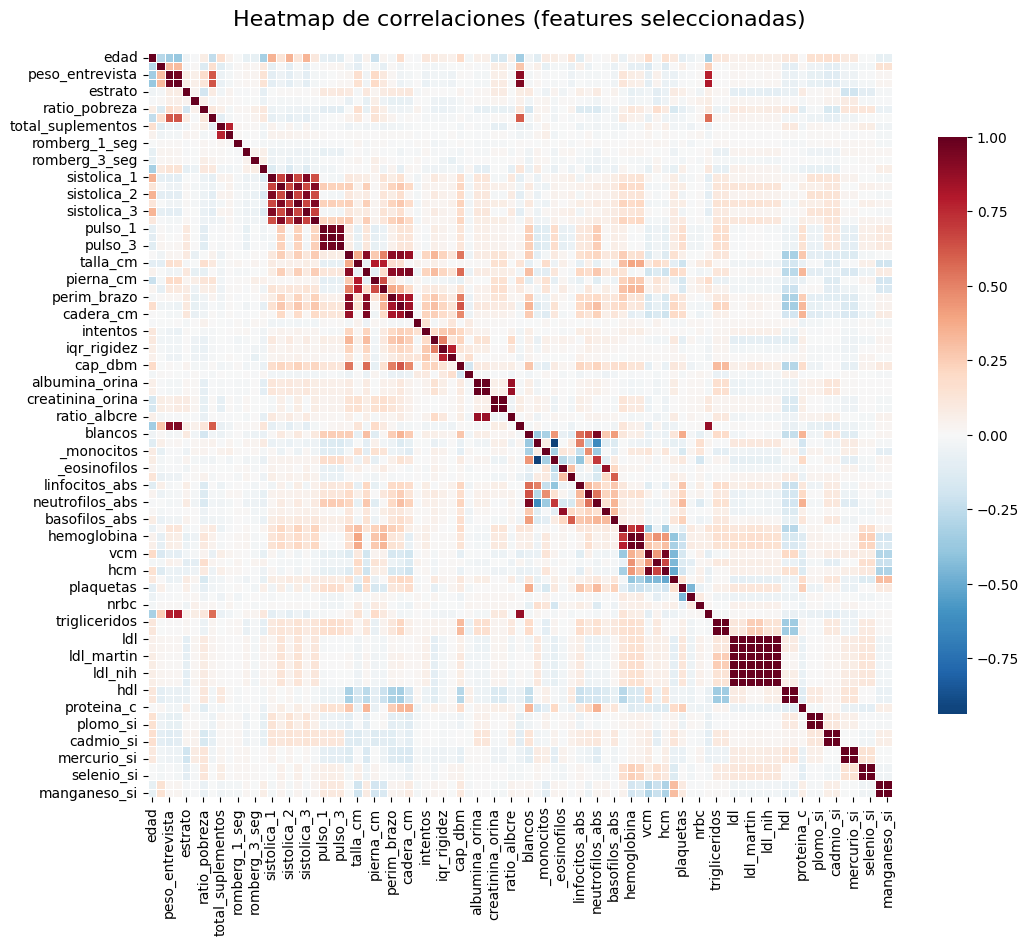

In [71]:
# 3. Análisis Estadístico Descriptivo
print("--- Estadísticos Principales ---")
display(df.describe())

# 4. Visualización de correlación 
# Calculamos la matriz
corr_matrix = df[cols_numericas].corr()

# Configuramos el tamaño de la figura
plt.figure(figsize=(12, 10))

# Dibujamos el heatmap 
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='RdBu_r', 
            center=0,
            linewidths=.5, 
            linecolor='white',
            square=True,
            cbar_kws={"shrink": .75})

# Ajustes de etiquetas y título
plt.title("Heatmap de correlaciones (features seleccionadas)", fontsize=16, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()
#TODO: Comentar!!

- Analizar las correlaciones entre variables.
- Eliminar redundancias y mirar posibles agrupaciones

Analizamos las redundancias en variables, por conversion de unidades u otros motivos.

Primero analizamos aquellas variables con el sufijo _si que hacen referencia a la unidades en el sistema Internacional y eliminaremos el resto de unidades que representan lo mismo con otras unidades.

OJO! NO SE TIENEN EN CUENTA LAS VARIBALES DE PULSO, PRESION SISTOLICA Y DISTOLICA YA QUE SON NUESTRO TARGET Y SE TRATARAN MÁS ADELANTE.

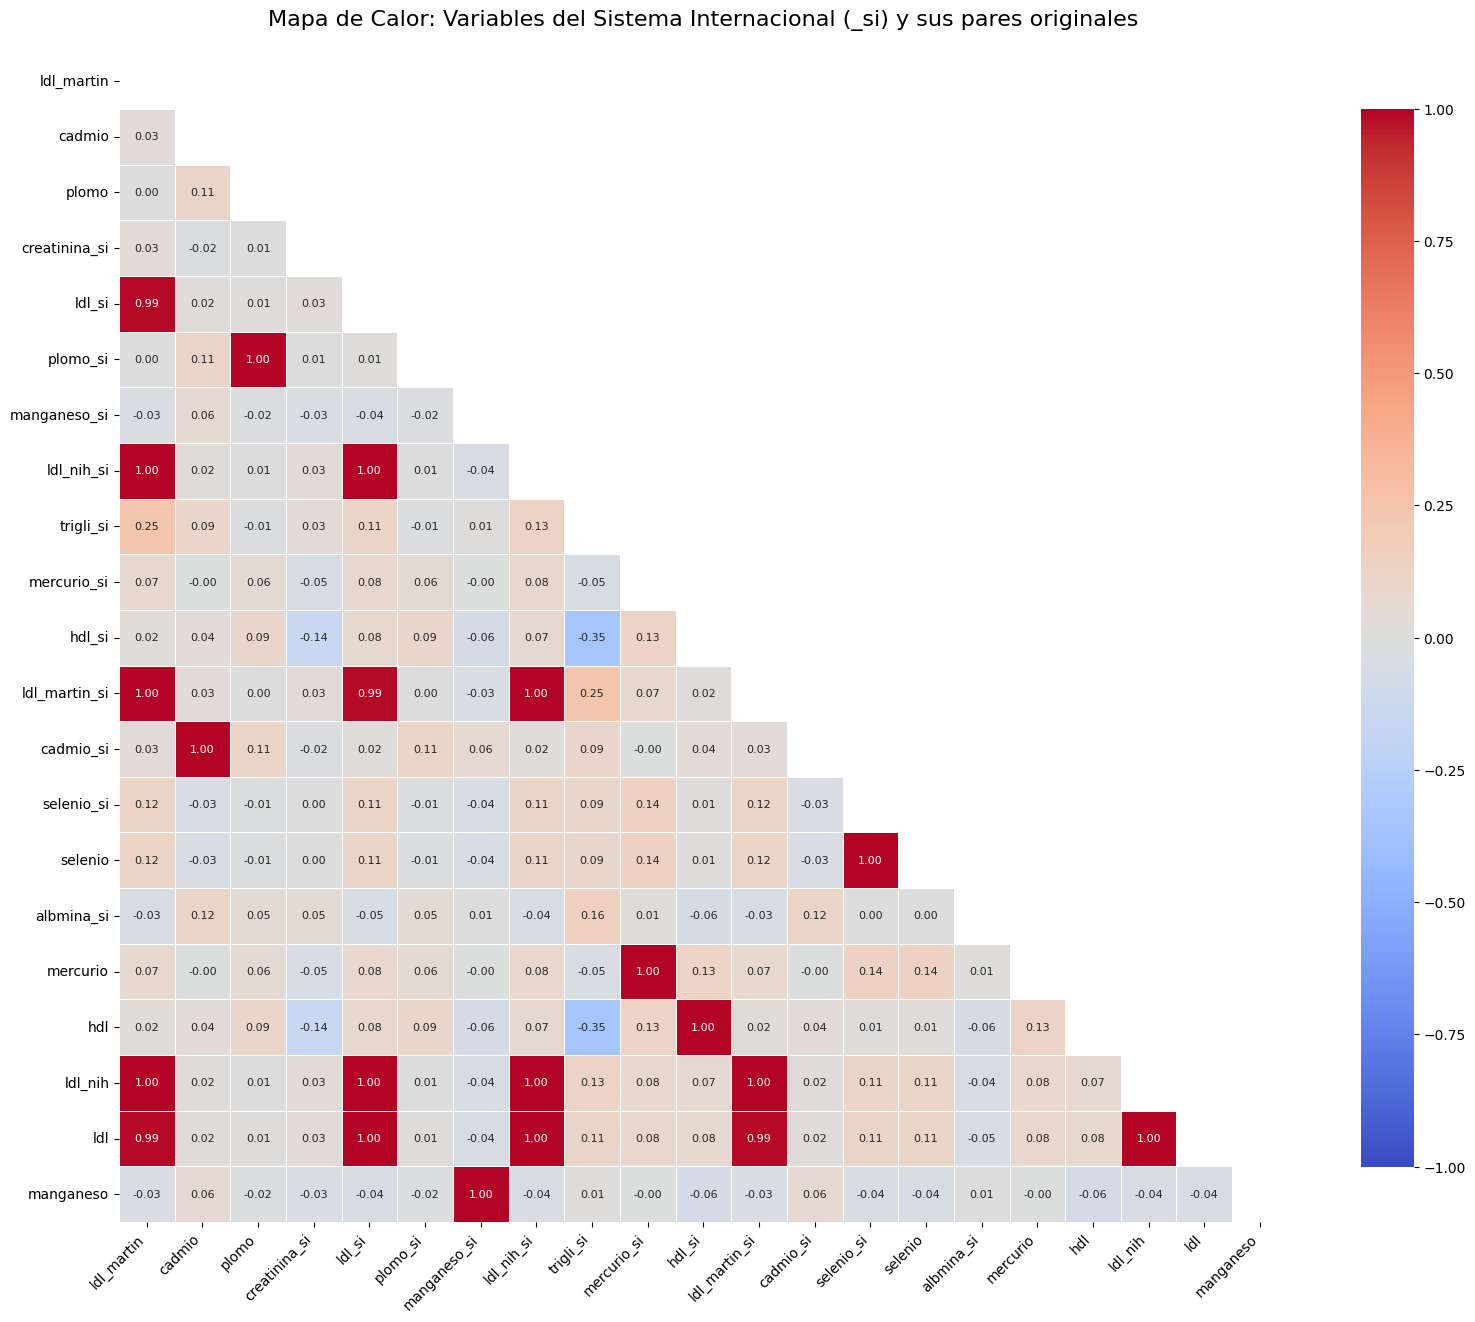

In [72]:
columnas_si = [col for col in df.columns if col.endswith('_si')]

# 3. (Opcional pero recomendado) Buscar las variables originales para compararlas
#    Esto busca si existe la misma palabra pero sin "_si" al final
columnas_base = [col.replace('_si', '') for col in columnas_si if col.replace('_si', '') in df.columns]

# 4. Unir ambas listas y quitar duplicados convirtiéndolo a un 'set'
columnas_finales = list(set(columnas_si + columnas_base))

# 5. Calcular la matriz de correlación SOLO con estas columnas
subset_corr = df[columnas_finales].corr()

# 6. Configurar el gráfico
plt.figure(figsize=(16, 14))

# Crear máscara para el triángulo superior y evitar datos repetidos en espejo
mask = np.triu(np.ones_like(subset_corr, dtype=bool))

# 7. Generar el mapa de calor
sns.heatmap(subset_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
            cbar_kws={"shrink": .8}, annot_kws={"size": 8})

# Añadir títulos y ajustar la rotación de las etiquetas
plt.title('Mapa de Calor: Variables del Sistema Internacional (_si) y sus pares originales', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# 8. Mostrar el resultado
plt.show()

In [73]:
columnas_a_eliminar = [
    'cadmio', 'plomo', 'ldl_si', 'ldl', 'manganeso', 
    'ldl_nih_si', 'hdl', 'ldl_nih', 'selenio', 'mercurio', 'ldl_martin'
]

# 3. Verificamos qué columnas de la lista existen realmente en tu dataframe
# Esto evita que el código se rompa si alguna columna ya fue eliminada antes o está mal escrita
columnas_existentes = [col for col in columnas_a_eliminar if col in df.columns]

# 4. Eliminamos las columnas
df.drop(columns=columnas_existentes, inplace=True)

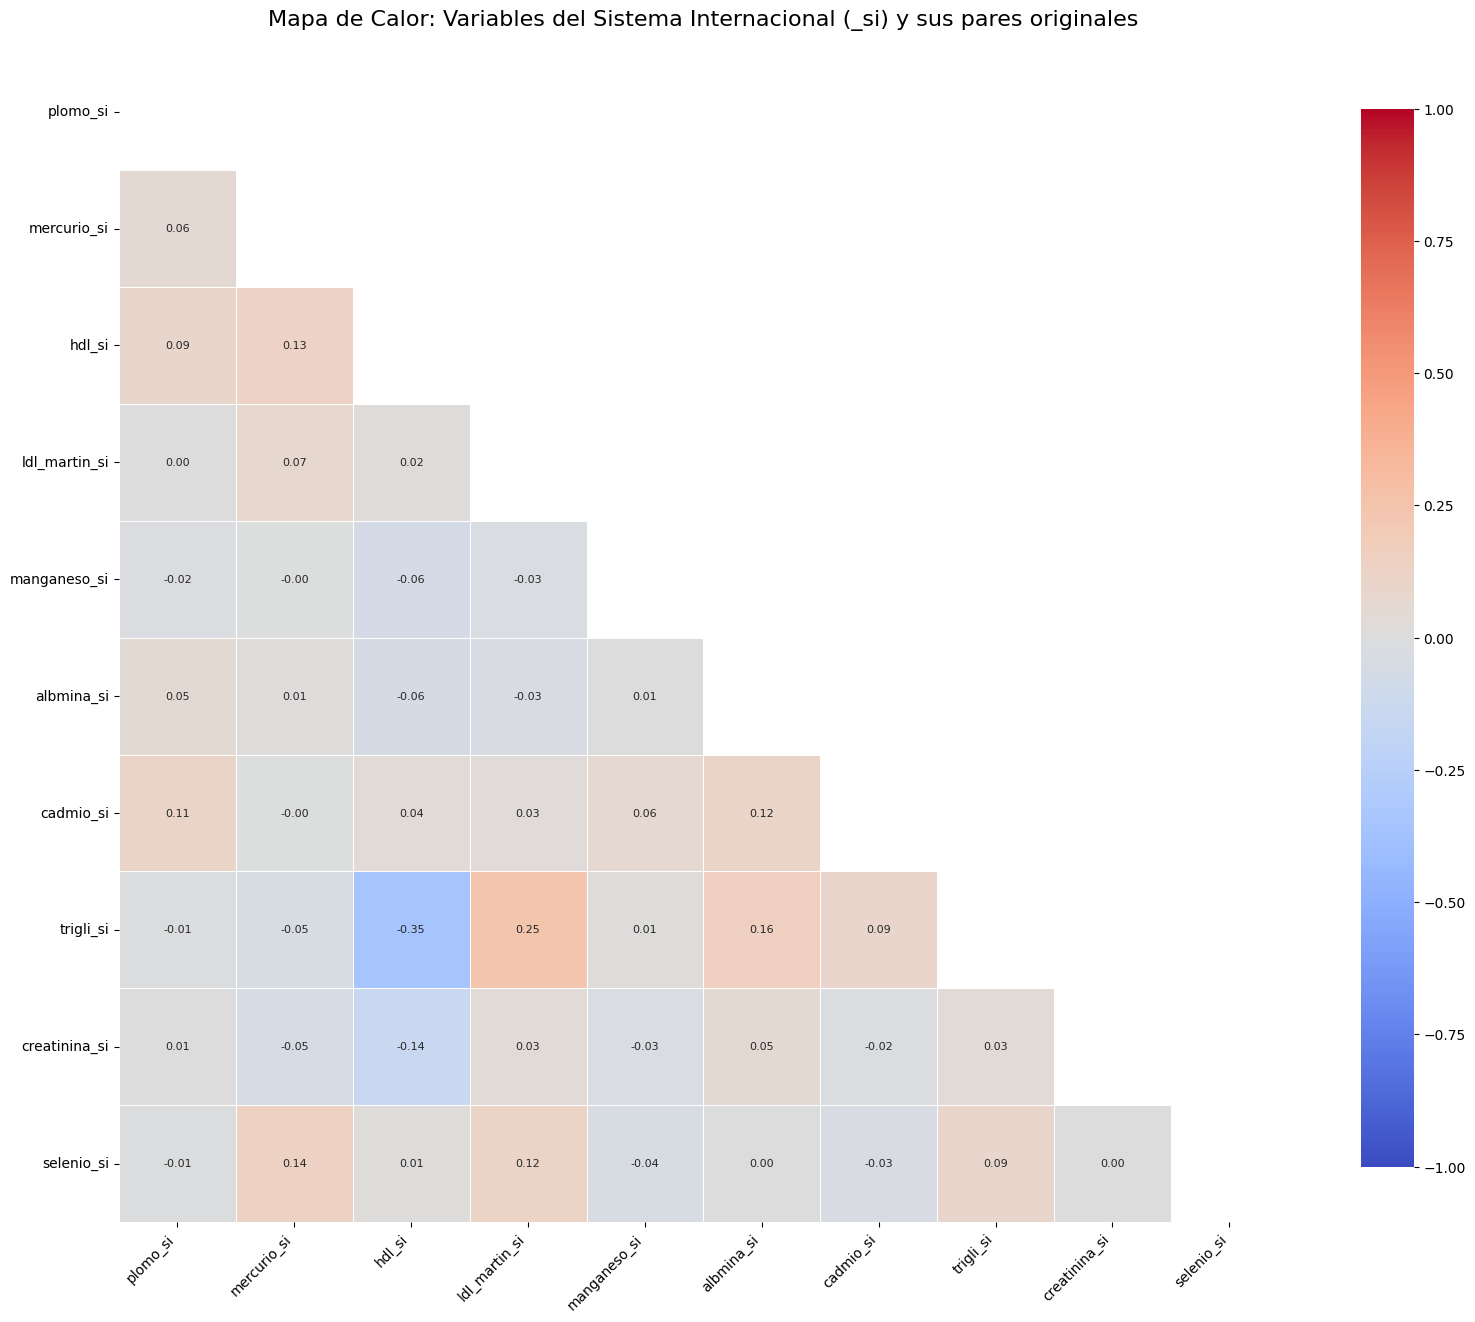

In [74]:
columnas_si = [col for col in df.columns if col.endswith('_si')]

# 3. (Opcional pero recomendado) Buscar las variables originales para compararlas
#    Esto busca si existe la misma palabra pero sin "_si" al final
columnas_base = [col.replace('_si', '') for col in columnas_si if col.replace('_si', '') in df.columns]

# 4. Unir ambas listas y quitar duplicados convirtiéndolo a un 'set'
columnas_finales = list(set(columnas_si + columnas_base))

# 5. Calcular la matriz de correlación SOLO con estas columnas
subset_corr = df[columnas_finales].corr()

# 6. Configurar el gráfico
plt.figure(figsize=(16, 14))

# Crear máscara para el triángulo superior y evitar datos repetidos en espejo
mask = np.triu(np.ones_like(subset_corr, dtype=bool))

# 7. Generar el mapa de calor
sns.heatmap(subset_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
            cbar_kws={"shrink": .8}, annot_kws={"size": 8})

# Añadir títulos y ajustar la rotación de las etiquetas
plt.title('Mapa de Calor: Variables del Sistema Internacional (_si) y sus pares originales', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# 8. Mostrar el resultado
plt.show()

Una vez eliminadas las variables con distinto tipo de unidad, buscamos el resto con variables con correlaciones muy altas.

Correlaciones >= 0.95

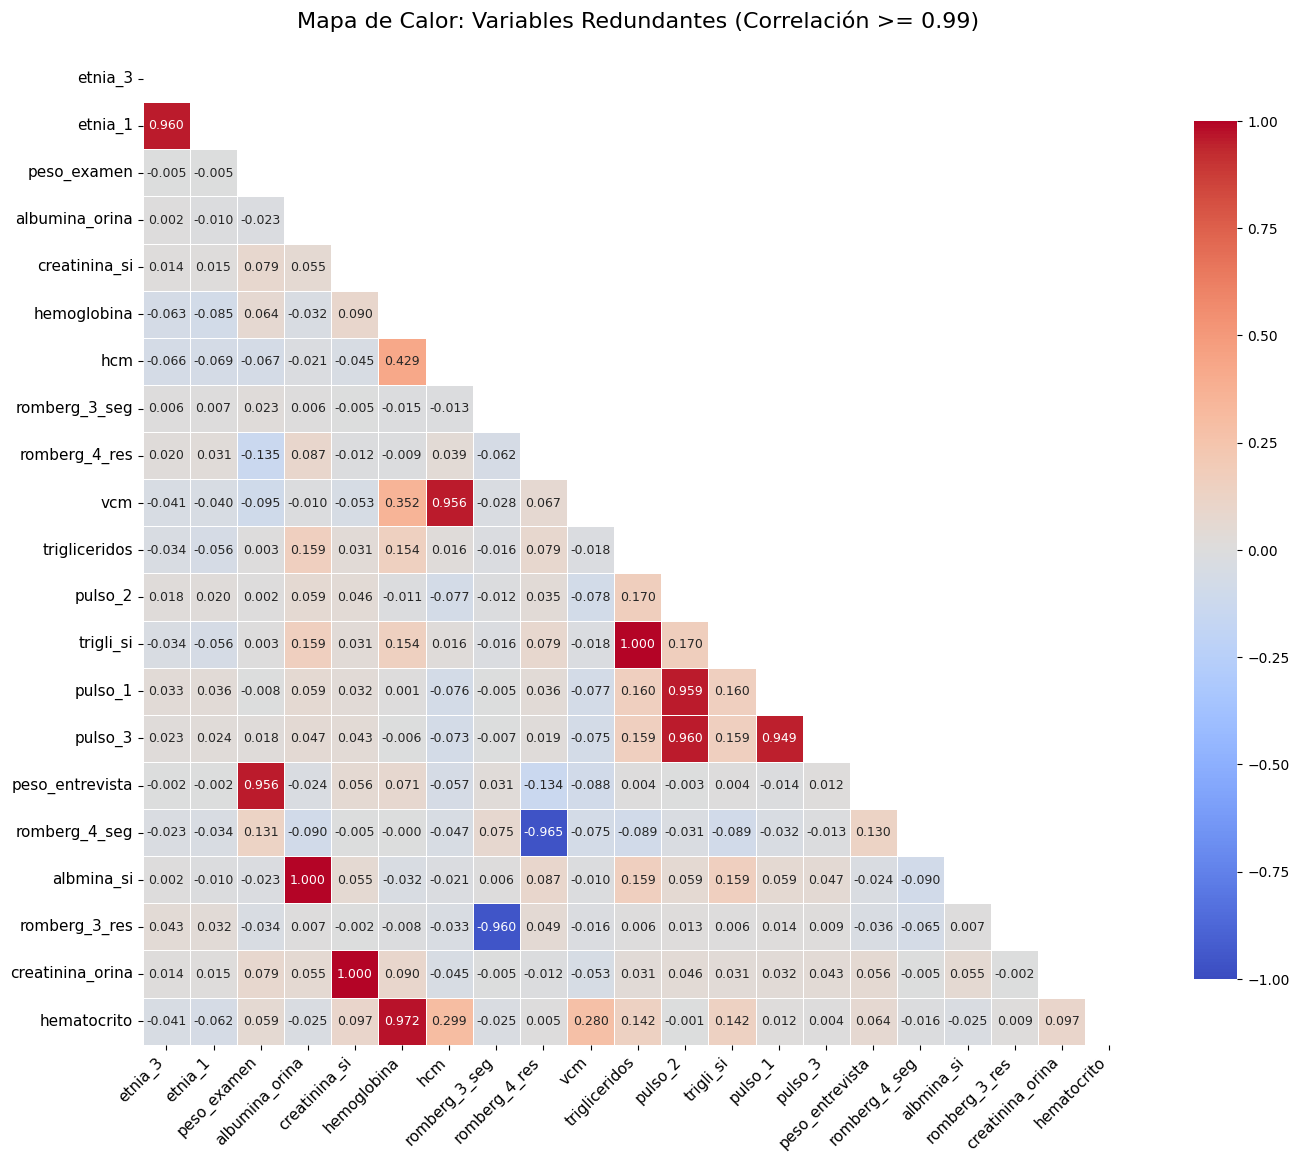

In [75]:
df_numeric = df.select_dtypes(include=[np.number])

# 2. Calcular matriz de correlación
corr_matrix = df_numeric.corr()
corr_matrix_abs = corr_matrix.abs()

# 3. Filtrar el triángulo superior para obtener pares únicos
upper_tri = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))
correlaciones = upper_tri.unstack().dropna()

# 4. Filtrar variables con correlación casi perfecta (>= 0.99)
redundancias = correlaciones[correlaciones >= 0.95]

# --- MODIFICACIÓN PARA EL MAPA DE CALOR ---

# 5. Obtener la lista única de variables involucradas en las redundancias
#    Convertimos a 'set' para quitar duplicados y luego volvemos a 'list'
vars_redundantes = list(set([var for index in redundancias.index for var in index]))

# 6. Crear una sub-matriz de correlación SOLO con las variables redundantes
#    Usamos corr_matrix (no la absoluta) para mantener el signo real, aunque aquí casi todas serán 1.0
subset_corr = corr_matrix.loc[vars_redundantes, vars_redundantes]

# 7. Configuración del gráfico
plt.figure(figsize=(14, 12))

# 8. Crear máscara para ocultar el triángulo superior (evita ver lo mismo dos veces)
mask = np.triu(np.ones_like(subset_corr, dtype=bool))

# 9. Generar el mapa de calor
sns.heatmap(subset_corr, mask=mask, annot=True, fmt=".3f", cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
            cbar_kws={"shrink": .8}, annot_kws={"size": 9})

# Añadir títulos y ajustar ejes
plt.title('Mapa de Calor: Variables Redundantes (Correlación >= 0.99)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# 10. Mostrar el resultado
plt.show()

hcm (Hemoglobina Corpuscular Media)

* Qué es: Cantidad promedio de hemoglobina dentro de un solo glóbulo rojo.

* Por qué se elimina? Alta colinealidad. Crece de la mano con el vcm (tamaño del glóbulo). Conservas el vcm porque es el indicador clínico principal.

hemotrocito (Hematocrito)

* Qué es: Porcentaje del volumen de tu sangre que son glóbulos rojos.

* Por qué se elimina: Altísima correlación con la hemoglobina. Lo eliminas porque la hemoglobina es una medida más directa, estable y menos afectada por si el paciente bebió agua o no (hidratación).

peso_entrevista y peso_examen

* Qué son: Variables estadísticas y demográficas que indican a cuántos miles de personas representa ese paciente en la encuesta original.

* Por qué se eliminan: No son datos médicos ni biológicos. Si se las das a un modelo predictivo, el algoritmo intentará buscar enfermedades en números burocráticos y se confundirá.

In [76]:
columnas_a_eliminar = [
    'creatinina_orina', 'albumina_orina' , 'hcm', 'trigliceridos','peso_entrevista', 'peso_examen', 'hemotrocito'
]

# 3. Verificamos qué columnas de la lista existen realmente en tu dataframe
# Esto evita que el código se rompa si alguna columna ya fue eliminada antes o está mal escrita
columnas_existentes = [col for col in columnas_a_eliminar if col in df.columns]

# 4. Eliminamos las columnas
df.drop(columns=columnas_existentes, inplace=True)

Comprobamos que se han eliminado correctamente y analizamos las correlaciones negativas.

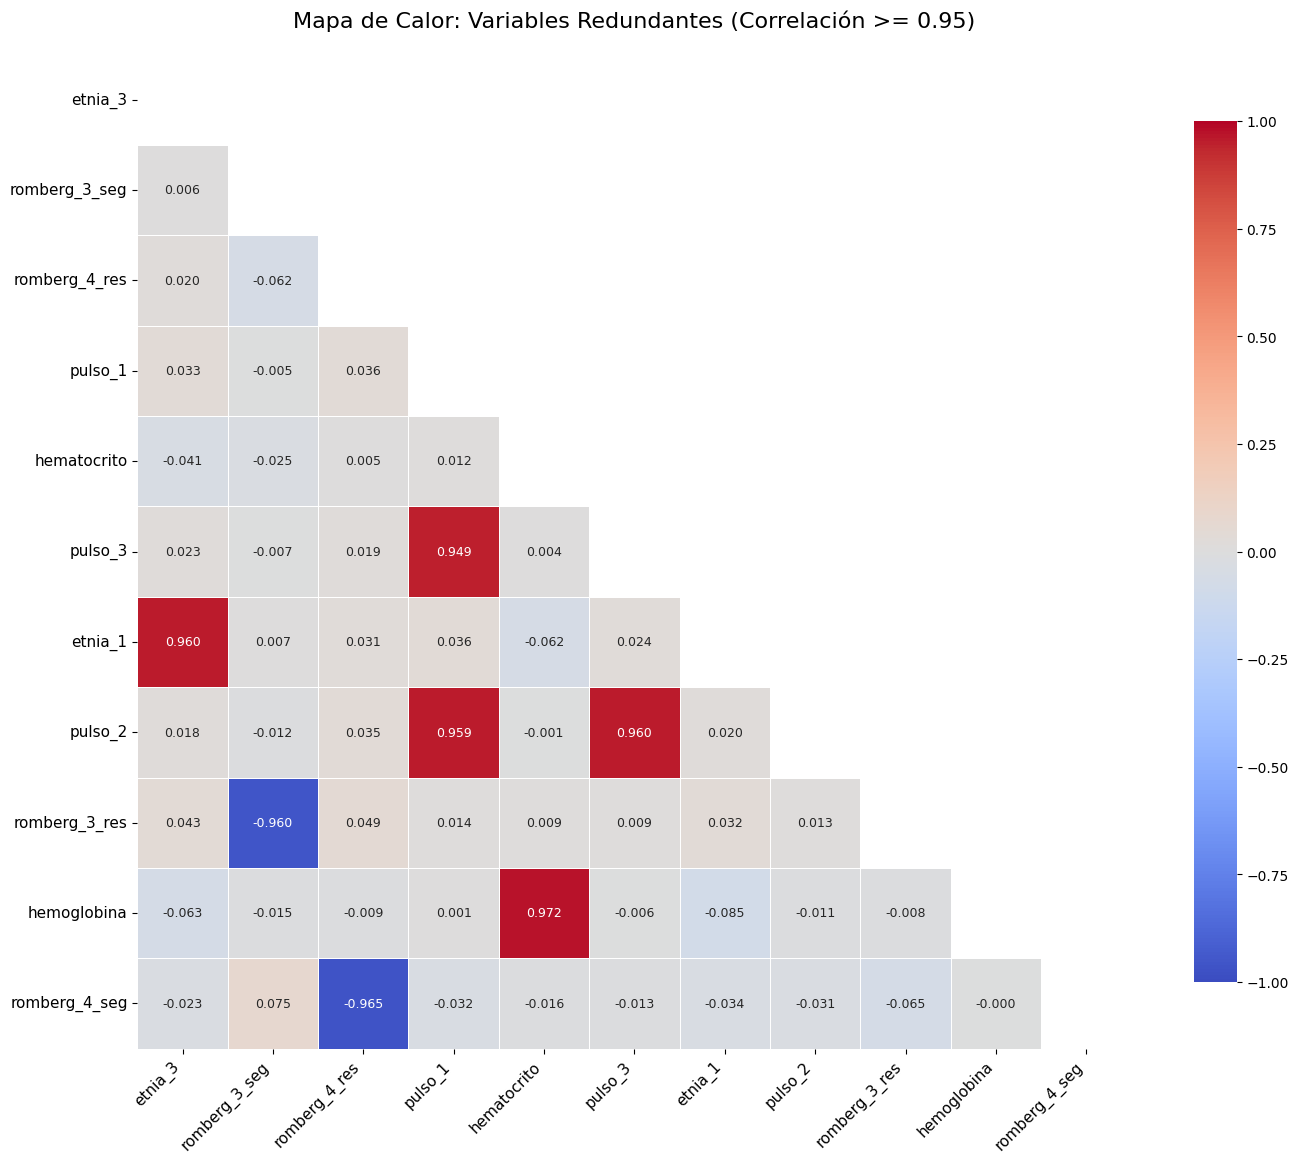

In [77]:
df_numeric = df.select_dtypes(include=[np.number])

# 2. Calcular matriz de correlación
corr_matrix = df_numeric.corr()
corr_matrix_abs = corr_matrix.abs()

# 3. Filtrar el triángulo superior para obtener pares únicos
upper_tri = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))
correlaciones = upper_tri.unstack().dropna()

# 4. Filtrar variables con correlación casi perfecta (>= 0.99)
redundancias = correlaciones[correlaciones >= 0.95]

# --- MODIFICACIÓN PARA EL MAPA DE CALOR ---

# 5. Obtener la lista única de variables involucradas en las redundancias
#    Convertimos a 'set' para quitar duplicados y luego volvemos a 'list'
vars_redundantes = list(set([var for index in redundancias.index for var in index]))

# 6. Crear una sub-matriz de correlación SOLO con las variables redundantes
#    Usamos corr_matrix (no la absoluta) para mantener el signo real, aunque aquí casi todas serán 1.0
subset_corr = corr_matrix.loc[vars_redundantes, vars_redundantes]

# 7. Configuración del gráfico
plt.figure(figsize=(14, 12))

# 8. Crear máscara para ocultar el triángulo superior (evita ver lo mismo dos veces)
mask = np.triu(np.ones_like(subset_corr, dtype=bool))

# 9. Generar el mapa de calor
sns.heatmap(subset_corr, mask=mask, annot=True, fmt=".3f", cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
            cbar_kws={"shrink": .8}, annot_kws={"size": 9})

# Añadir títulos y ajustar ejes
plt.title('Mapa de Calor: Variables Redundantes (Correlación >= 0.95)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# 10. Mostrar el resultado
plt.show()

Etnia:

Nuestro dataset recoge la etnia de los pacientes en clases enumeradas de 1 a 5 y en versiones posteriores añadieron un grupo más en una nueva columna etnia_3 es por eso que eliminaremos la columna etnia 1 ya que ambas contienen los mismos datos solo que etnia_3 está más actualizada.

Test de Romberg:

* seg (Segundos): Es el tiempo literal, en segundos, que el paciente logra mantener el equilibrio durante esa fase de la prueba (con un máximo de $30$ segundos, que es el tiempo objetivo estándar del test clínico).

* _res (Resultado): Es un código categórico que evalúa el desempeño del paciente.
    * El valor 1.0 significa "Pasa la prueba" (El paciente aguantó el tiempo requerido).
    * El valor 2.0 significa "Falla la prueba" (El paciente perdió el equilibrio prematuramente).
    * El valor 7.0 (que aparece marginalmente) suele ser un código de error o rechazo (ej. "No pudo realizarla" o "Se negó").

ARREGLAR CON LO QUE DIGA PAULA

Bajamos el margen de restriccion de las correlaciones a 0.9 y comprobamos cuales quedan

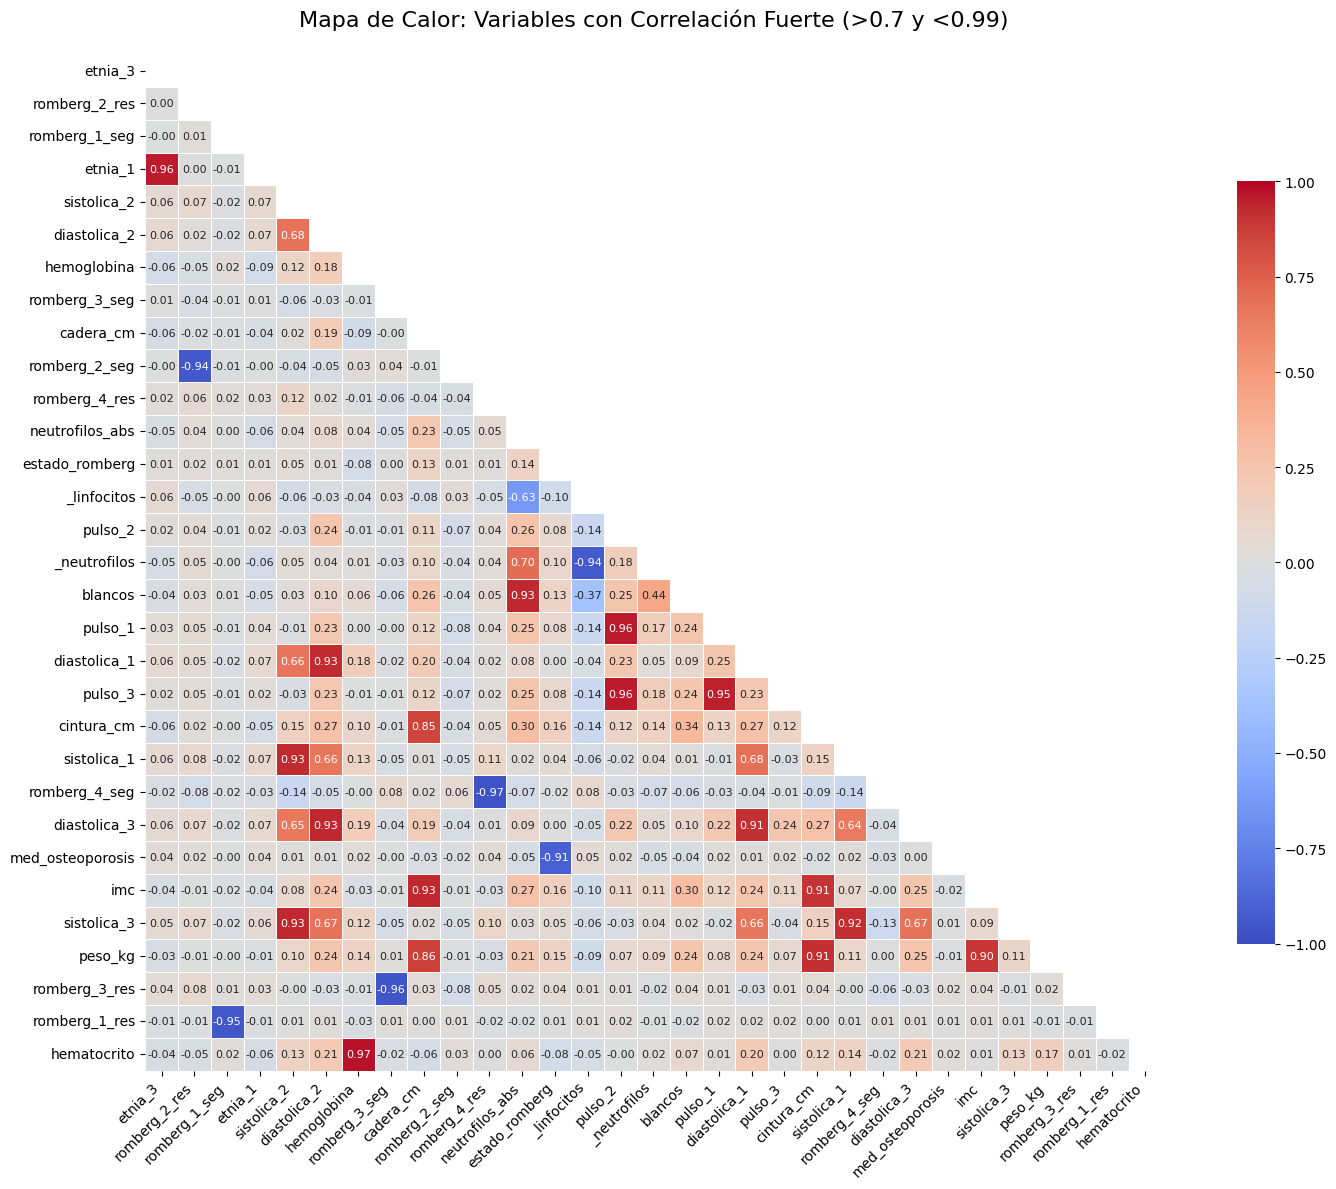

In [79]:

df_numeric = df.select_dtypes(include=[np.number])

# 2. Calcular matriz de correlación y sus valores absolutos
corr = df_numeric.corr()
corr_abs = corr.abs()

# 3. Filtrar el triángulo superior para buscar pares únicos
upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
pairs = upper_tri.unstack().dropna()

# 4. Seleccionar pares con correlación > 0.7 y < 0.99 (excluye redundancias)
high_corr_pairs = pairs[(pairs > 0.9) & (pairs < 0.99)]

# 5. Obtener una lista única de las variables involucradas en esas altas correlaciones
vars_to_plot = list(set([var for index in high_corr_pairs.index for var in index]))

# 6. Crear una sub-matriz de correlación SOLO con estas variables
subset_corr = df_numeric[vars_to_plot].corr()

# 7. Configuración visual del Mapa de Calor
plt.figure(figsize=(16, 12))

# Crear una máscara para ocultar la mitad superior repetida
mask = np.triu(np.ones_like(subset_corr, dtype=bool))

# Dibujar el heatmap con Seaborn
sns.heatmap(subset_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
            cbar_kws={"shrink": .75}, annot_kws={"size": 8})

# Personalizar títulos y etiquetas
plt.title('Mapa de Calor: Variables con Correlación Fuerte (>0.7 y <0.99)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

Globulos Blancos:

Encontramos las variables: 

* _neutrofilos: Primera línea contra bacterias.

* _linfocitos: Defensas especializadas (virus y anticuerpos).

* _monocitos: Células "basurero" que limpian tejidos muertos o combaten infecciones crónicas.

* _eosinofilos: Se activan frente a parásitos y reacciones alérgicas.

* _basofilos: Asociados a respuestas inflamatorias y liberación de histamina.

* blancos: Conteo total absoluto de todas las células defensivas.

Medidas en porcentaje

Y los respectivos conteos en valor absoluto _abs:

* eutrofilos_abs

* linfocitos_abs

* monocitos_abs

* eosinofilos_abs

* basofilos_abs

Para ello eliminamos todas aquella que NO esten medidas en valor absoluto para evitar multicolinealidad, ya que todos deben sumar ~100%). Tambien eliminamos blancos ya que es la suma matemática de los absolutos individuales.


IMC respecto a cadera_cm y cintura_cm y peso: Observamos una alta correlacion entre el IMC y la medidas de peso y de longitud de la cadera y cintura en centimetro por ello vamos a conservar solo el IMC ya que es una medida estandar comunmente utilizada.

In [83]:
columnas_a_eliminar = [
    '_neutrofilos', '_linfocitos' , '_monocitos', '_eosinofilos','_basofilos', 'blancos','peso_kg','cadera_cm','cintura_cm','etnia_1'
]

# 3. Verificamos qué columnas de la lista existen realmente en tu dataframe
# Esto evita que el código se rompa si alguna columna ya fue eliminada antes o está mal escrita
columnas_existentes = [col for col in columnas_a_eliminar if col in df.columns]

# 4. Eliminamos las columnas
df.drop(columns=columnas_existentes, inplace=True)

In [84]:
df.rename(columns={'etnia_3': 'etnia'}, inplace=True)


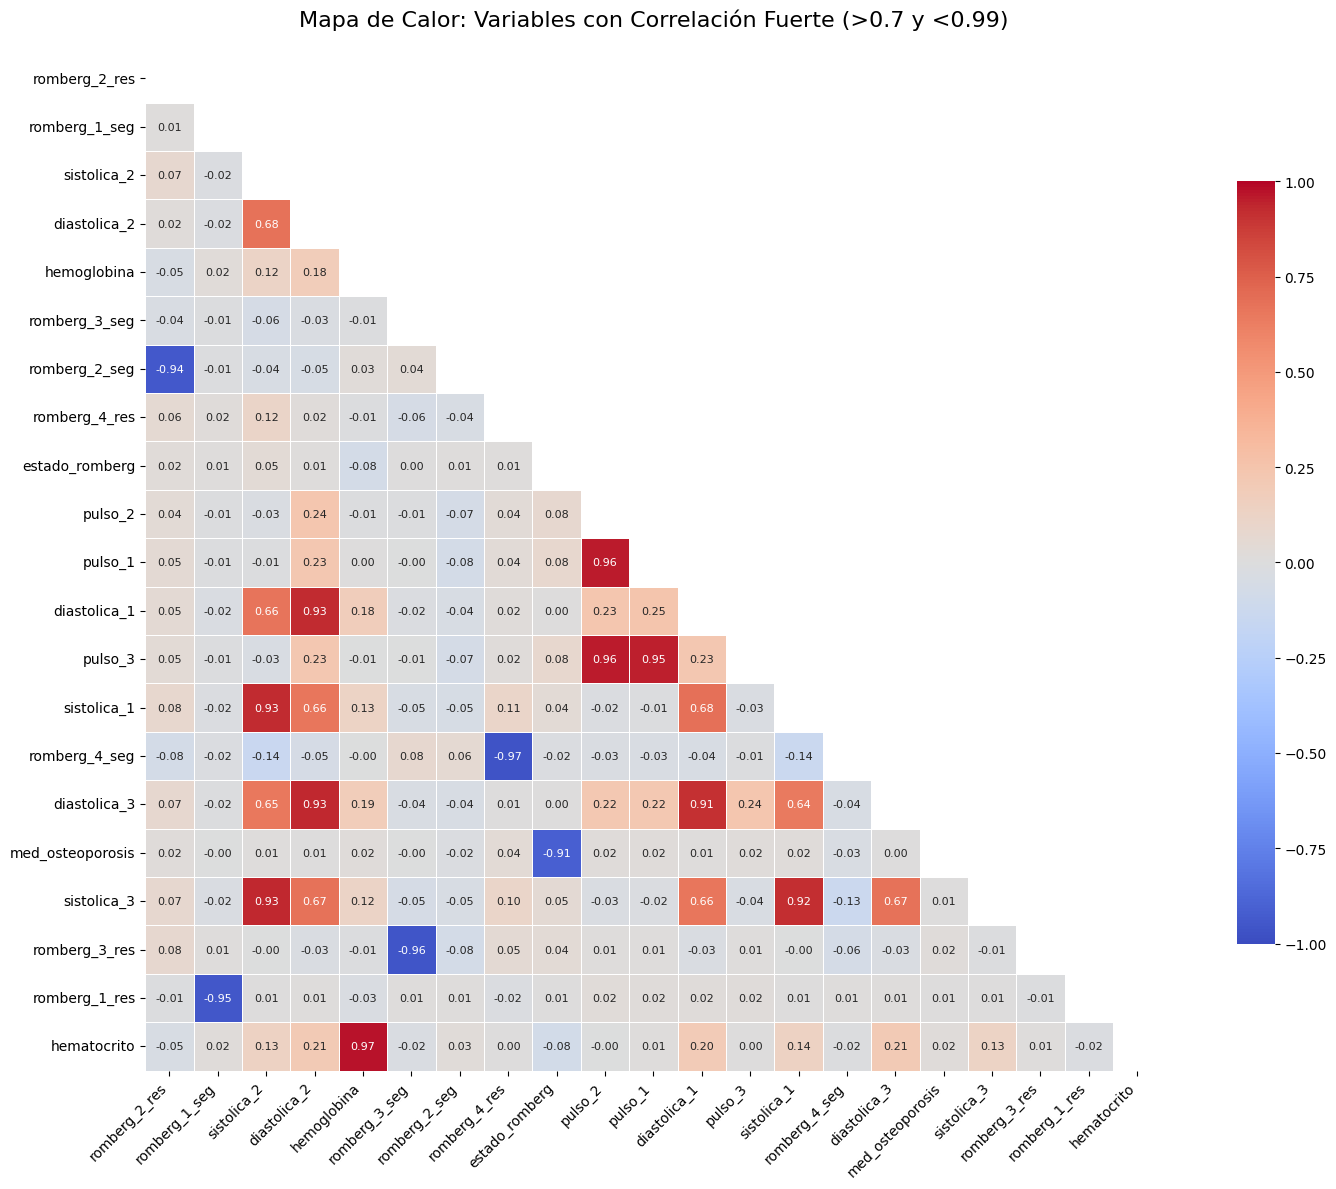

In [85]:

df_numeric = df.select_dtypes(include=[np.number])

# 2. Calcular matriz de correlación y sus valores absolutos
corr = df_numeric.corr()
corr_abs = corr.abs()

# 3. Filtrar el triángulo superior para buscar pares únicos
upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
pairs = upper_tri.unstack().dropna()

# 4. Seleccionar pares con correlación > 0.7 y < 0.99 (excluye redundancias)
high_corr_pairs = pairs[(pairs > 0.9) & (pairs < 0.99)]

# 5. Obtener una lista única de las variables involucradas en esas altas correlaciones
vars_to_plot = list(set([var for index in high_corr_pairs.index for var in index]))

# 6. Crear una sub-matriz de correlación SOLO con estas variables
subset_corr = df_numeric[vars_to_plot].corr()

# 7. Configuración visual del Mapa de Calor
plt.figure(figsize=(16, 12))

# Crear una máscara para ocultar la mitad superior repetida
mask = np.triu(np.ones_like(subset_corr, dtype=bool))

# Dibujar el heatmap con Seaborn
sns.heatmap(subset_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
            cbar_kws={"shrink": .75}, annot_kws={"size": 8})

# Personalizar títulos y etiquetas
plt.title('Mapa de Calor: Variables con Correlación Fuerte (>0.7 y <0.99)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [ ]:
#df.to_csv('DataframeFinal_2.csv', index=False)

## Estudio de posibles targets

Volvemos a cargar el dataset por si al dataframe se le ha hecho algun cambio

In [38]:
try:
    df = pd.read_csv('./data/merged_all_clean.csv')
    
    if 'SEQN' in df.columns:
        df.drop(columns=['SEQN'], inplace=True)
        print("Columna 'SEQN' eliminada.")
        print(f"Dataset cargado con éxito: {df.shape[0]} filas y {df.shape[1]} columnas.")
        print(df.columns.tolist())
    else:
        print("No se encontró columna 'SEQN'.")
        print(f"Dataset cargado con éxito: {df.shape[0]} filas y {df.shape[1]} columnas.")
        print(df.columns.tolist())
        
except FileNotFoundError:
    print("Error: No se encontró el archivo 'merged_all_clean.csv' en la carpeta 'data/'.")

Columna 'SEQN' eliminada.
Dataset cargado con éxito: 2591 filas y 124 columnas.
['SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDHHSIZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR', 'WTDRD1', 'DSDCOUNT', 'DSDANCNT', 'DSD010', 'DSD010AN', 'BAXMSTAT', 'BAX5STAT', 'BAQ110', 'BAQ121', 'BAQ125', 'BAQ132', 'BAQ140', 'BAQ150', 'BAQ160', 'BAQ170', 'BAQ173', 'BAXPF11', 'BAXTC11', 'BAXPF21', 'BAXTC21', 'BAXPF31', 'BAXTC31', 'BAXPF41', 'BAXTC41', 'BPAOARM', 'BPAOCSZ', 'BPXOSY1', 'BPXODI1', 'BPXOSY2', 'BPXODI2', 'BPXOSY3', 'BPXODI3', 'BPXOPLS1', 'BPXOPLS2', 'BPXOPLS3', 'BMDSTATS', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BMXWAIST', 'BMXHIP', 'LUAXSTAT', 'LUAPNME', 'LUANMVGP', 'LUANMTGP', 'LUXSMED', 'LUXSIQR', 'LUXSIQRM', 'LUXCAPM', 'LUXCPIQR', 'URXUMA', 'URXUMS', 'URDUMALC', 'URXUCR', 'URXCRS', 'URDUCRLC', 'URDACT', 'WTPH2YR', 'LBXWBCSI', 'LBXLYPCT', 'LBXMOPCT', 'LBXNEPCT', 'LBXEOPCT', 'LBXBAPCT', 'LBDLYMNO', 'LB

In [40]:
df_presion = df[['RIAGENDR','RIDAGEYR','BPXOSY1', 'BPXOSY2', 'BPXOSY3', 'BPXODI1', 'BPXODI2', 'BPXODI3', 'BPXOPLS1', 'BPXOPLS2', 'BPXOPLS3']].copy()


In [41]:
nombres_variables_pulso = {
    'RIAGENDR':'genero',
    'RIDAGEYR':'edad',
    'BPXOSY1': 'pa_sistolica_1',
    'BPXOSY2': 'pa_sistolica_2',
    'BPXOSY3': 'pa_sistolica_3',
    'BPXODI1': 'pa_diastolica_1',
    'BPXODI2': 'pa_diastolica_2',
    'BPXODI3': 'pa_diastolica_3',
    'BPXOPLS1': 'pulso_1',
    'BPXOPLS2': 'pulso_2',
    'BPXOPLS3': 'pulso_3'
}

df_presion.rename(columns=nombres_variables_pulso, inplace=True)

In [42]:
df_presion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2591 entries, 0 to 2590
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   genero           2591 non-null   float64
 1   edad             2591 non-null   float64
 2   pa_sistolica_1   2591 non-null   float64
 3   pa_sistolica_2   2588 non-null   float64
 4   pa_sistolica_3   2581 non-null   float64
 5   pa_diastolica_1  2591 non-null   float64
 6   pa_diastolica_2  2588 non-null   float64
 7   pa_diastolica_3  2581 non-null   float64
 8   pulso_1          2591 non-null   float64
 9   pulso_2          2588 non-null   float64
 10  pulso_3          2581 non-null   float64
dtypes: float64(11)
memory usage: 222.8 KB


In [43]:
# Cuenta cuántas filas tienen exactamente N valores nulos
resumen_nulos = df_presion.isnull().sum(axis=1).value_counts().sort_index()

print("Cantidad de filas por número de valores nulos:")
print(resumen_nulos)


Cantidad de filas por número de valores nulos:
0    2580
3       9
6       2
Name: count, dtype: int64


In [44]:
valores_genero = df_presion['genero'].value_counts()
print(valores_genero)

genero
2.0    1452
1.0    1139
Name: count, dtype: int64


**Table. Categories of BP in Adults\***

| BP Category | SBP | | DBP |
| :--- | :--- | :---: | :--- |
| **Normal** | <120 mm Hg | and | <80 mm Hg |
| **Elevated** | 120–129 mm Hg | and | <80 mm Hg |
| **Hypertension** | | | |
| &emsp;Stage 1 | 130–139 mm Hg | or | 80–89 mm Hg |
| &emsp;Stage 2 | ≥140 mm Hg | or | ≥90 mm Hg |

<br>

<small>\* Individuals with SBP and DBP in 2 categories should be designated to the higher BP category.</small>
<small><br>BP indicates blood pressure (based on an average of ≥2 careful readings obtained on ≥2 occasions, as detailed in Section 4); DBP, diastolic blood pressure; and SBP, systolic blood pressure.</small>

Fuente: https://www.ahajournals.org/doi/10.1161/HYP.0000000000000065


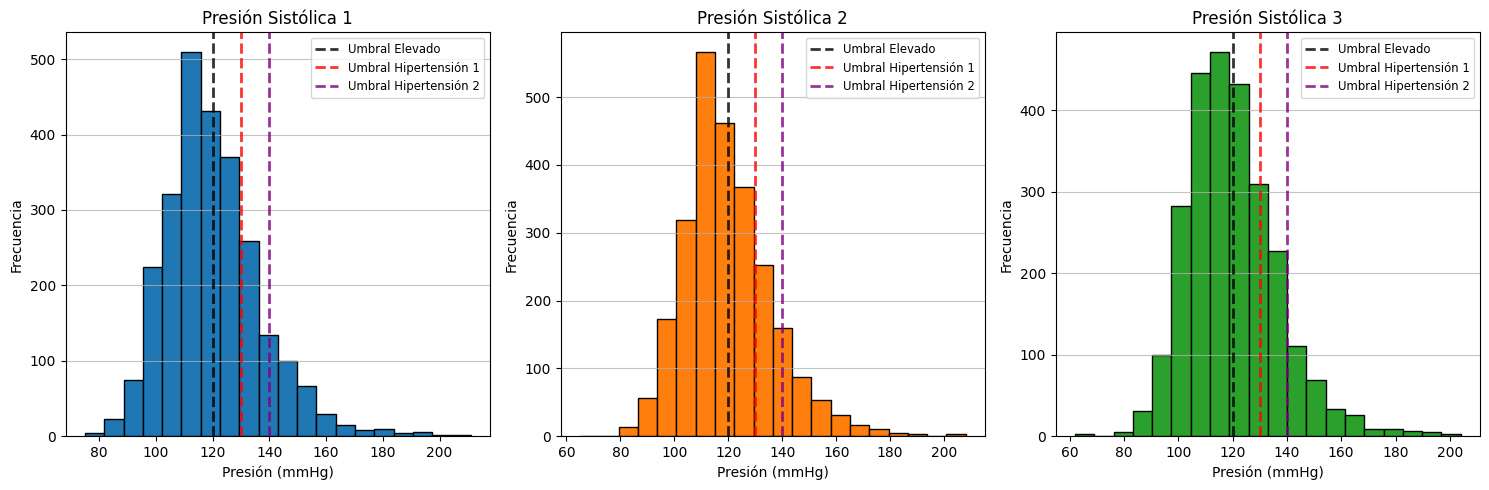

In [45]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['pa_sistolica_1', 'pa_sistolica_2', 'pa_sistolica_3']
titulos = ['Presión Sistólica 1', 'Presión Sistólica 2', 'Presión Sistólica 3']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

umbrales = [
    {'valor': 120, 'color': 'black', 'etiqueta': 'Umbral Elevado'},
    {'valor': 130, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 140, 'color': 'purple', 'etiqueta': 'Umbral Hipertensión 2'}
]

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (mmHg)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

    for umbral in umbrales:
        axes[i].axvline(
            x=umbral['valor'], 
            color=umbral['color'], 
            linestyle='--', 
            alpha=0.8, 
            linewidth=2, 
            label=umbral['etiqueta']
        )
    
    # Mostrar la leyenda en cada gráfico
    axes[i].legend(loc='upper right', fontsize='small')

# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


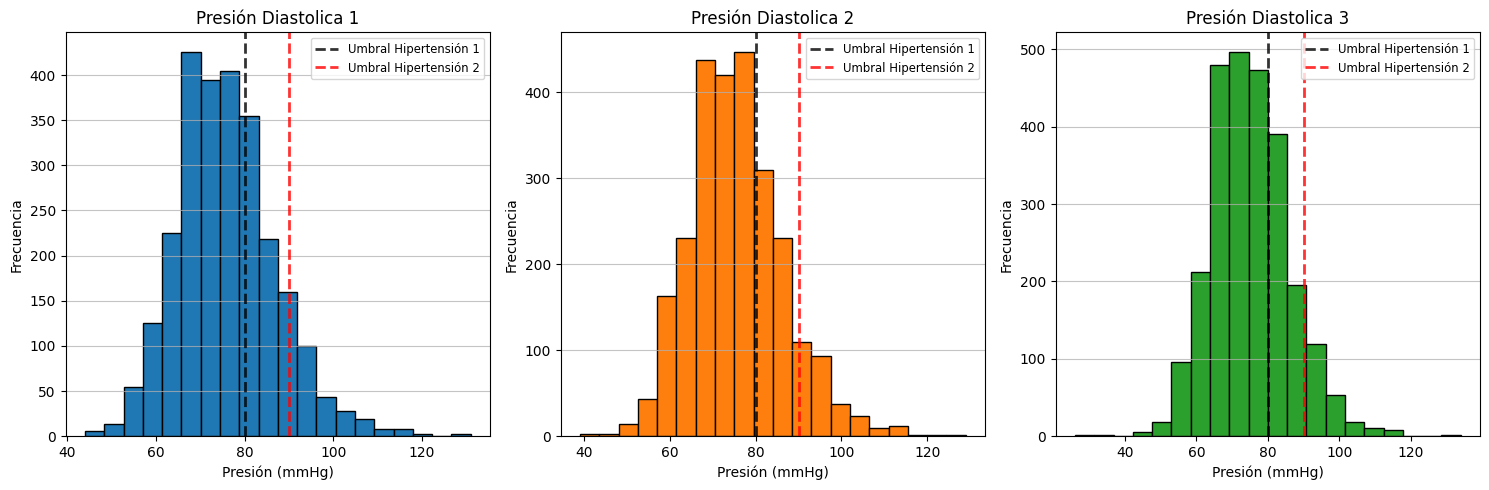

In [46]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['pa_diastolica_1', 'pa_diastolica_2', 'pa_diastolica_3']
titulos = ['Presión Diastolica 1', 'Presión Diastolica 2', 'Presión Diastolica 3']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

umbrales = [
    {'valor': 80, 'color': 'black', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 90, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 2'}
]

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (mmHg)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

    for umbral in umbrales:
        axes[i].axvline(
            x=umbral['valor'], 
            color=umbral['color'], 
            linestyle='--', 
            alpha=0.8, 
            linewidth=2, 
            label=umbral['etiqueta']
        )
    axes[i].legend(loc='upper right', fontsize='small')    
# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


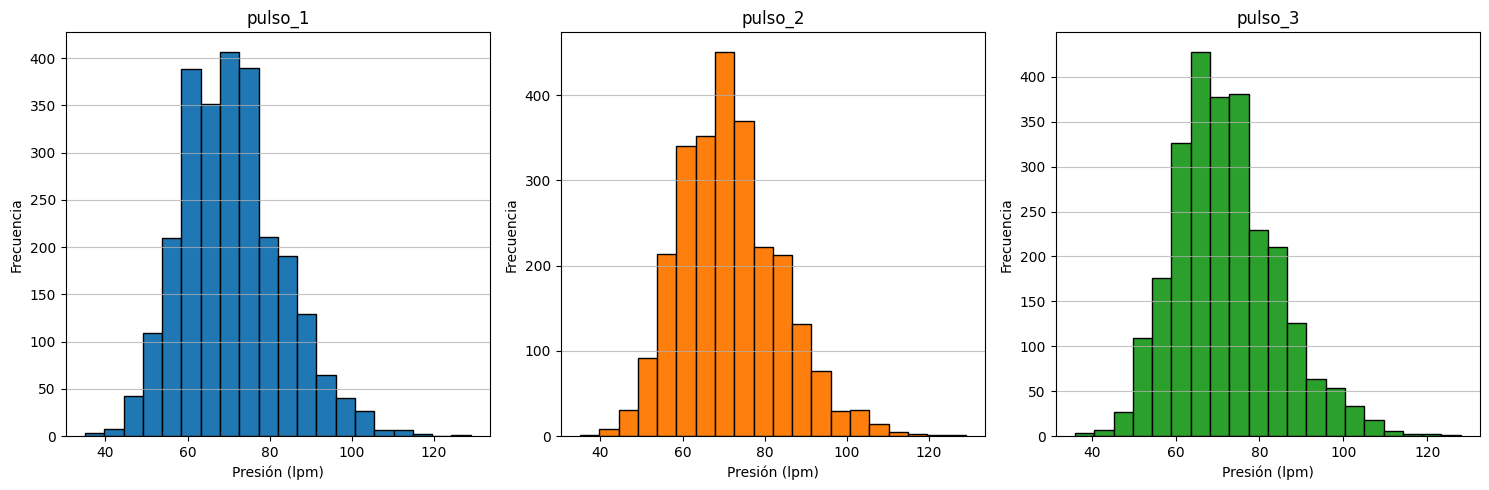

In [47]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['pulso_1', 'pulso_2', 'pulso_3']
titulos = ['pulso_1', 'pulso_2', 'pulso_3']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (lpm)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()

In [48]:
# Definir las listas de columnas para cada cálculo
columnas_sis = ['pa_sistolica_1', 'pa_sistolica_2', 'pa_sistolica_3']
columnas_dis = ['pa_diastolica_1', 'pa_diastolica_2', 'pa_diastolica_3']

# Calcular la media ignorando automáticamente los valores nulos (NaN)
df_presion['pa_sis_media'] = df_presion[columnas_sis].mean(axis=1).round(0)
df_presion['pa_dis_media'] = df_presion[columnas_dis].mean(axis=1).round(0)

# Comprobar el resultado
df_presion[['pa_sistolica_1', 'pa_sistolica_2', 'pa_sistolica_3', 'pa_sis_media', 
            'pa_diastolica_1', 'pa_diastolica_2', 'pa_diastolica_3', 'pa_dis_media']].head()


,pa_sistolica_1,pa_sistolica_2,pa_sistolica_3,pa_sis_media,pa_diastolica_1,pa_diastolica_2,pa_diastolica_3,pa_dis_media
0,135.0,131.0,132.0,133.0,98.0,96.0,94.0,96.0
1,121.0,117.0,113.0,117.0,84.0,76.0,76.0,79.0
2,111.0,112.0,104.0,109.0,79.0,80.0,76.0,78.0
3,110.0,120.0,115.0,115.0,72.0,74.0,75.0,74.0
4,99.0,110.0,123.0,111.0,69.0,68.0,67.0,68.0


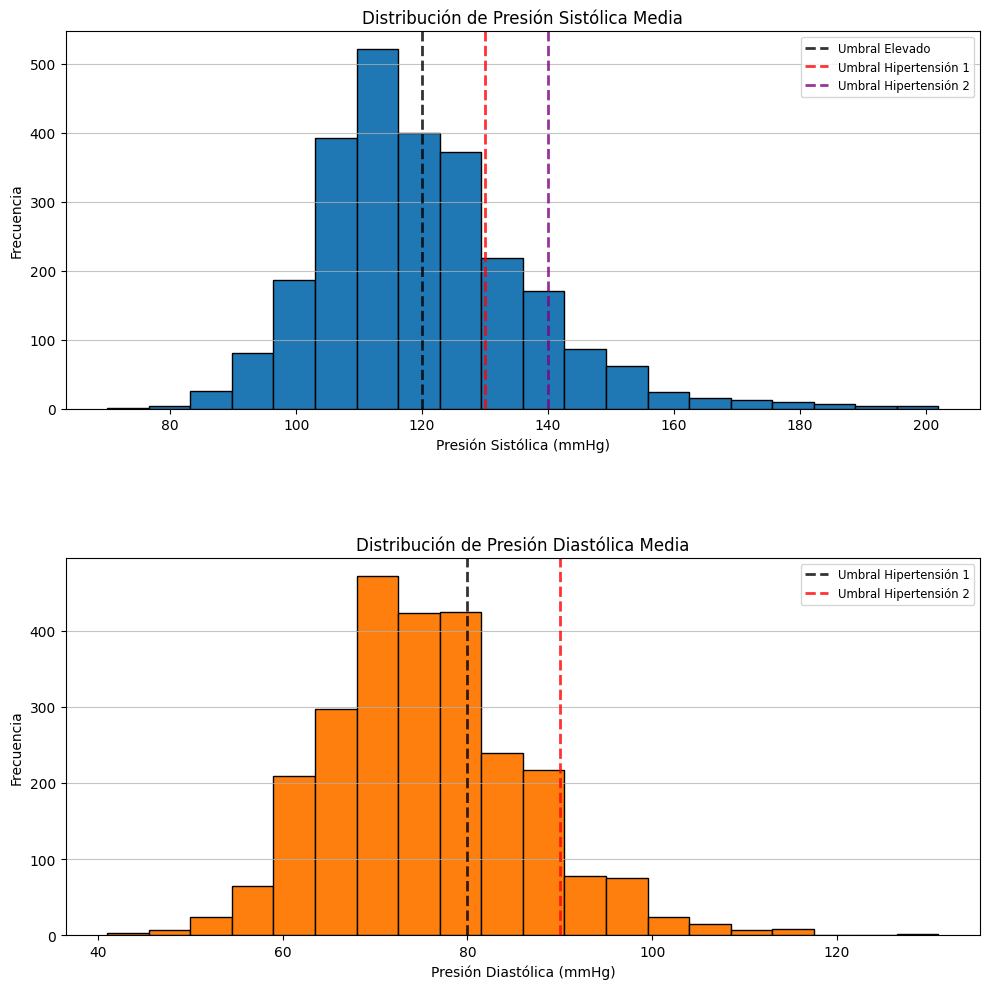

In [49]:


# Configurar el tamaño de la figura (2 filas, 1 columna)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Definir los umbrales específicos
umbrales_sis = [
    {'valor': 120, 'color': 'black', 'etiqueta': 'Umbral Elevado'},
    {'valor': 130, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 140, 'color': 'purple', 'etiqueta': 'Umbral Hipertensión 2'}
]

umbrales_dis = [
    {'valor': 80, 'color': 'black', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 90, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 2'}
]

# --- 1. Gráfica Superior: Presión Sistólica ---
axes[0].hist(df_presion['pa_sis_media'].dropna(), bins=20, color='#1f77b4', edgecolor='black')
axes[0].set_title('Distribución de Presión Sistólica Media')
axes[0].set_xlabel('Presión Sistólica (mmHg)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.75)

for u in umbrales_sis:
    axes[0].axvline(x=u['valor'], color=u['color'], linestyle='--', alpha=0.8, linewidth=2, label=u['etiqueta'])
axes[0].legend(loc='upper right', fontsize='small')    

# --- 2. Gráfica Inferior: Presión Diastólica ---
axes[1].hist(df_presion['pa_dis_media'].dropna(), bins=20, color='#ff7f0e', edgecolor='black')
axes[1].set_title('Distribución de Presión Diastólica Media')
axes[1].set_xlabel('Presión Diastólica (mmHg)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(axis='y', alpha=0.75)

for u in umbrales_dis:
    axes[1].axvline(x=u['valor'], color=u['color'], linestyle='--', alpha=0.8, linewidth=2, label=u['etiqueta'])
axes[1].legend(loc='upper right', fontsize='small')

# Ajustar diseño y mostrar
plt.tight_layout(h_pad=6.0)
plt.show()


In [50]:


# 1. Definir la lista de condiciones (¡El orden importa!)
condiciones = [
    # Condición 1: Normal
    (df_presion['pa_sis_media'] < 120) & (df_presion['pa_dis_media'] < 80),
    
    # Condición 2: Elevado
    (df_presion['pa_sis_media'] >= 120) & (df_presion['pa_sis_media'] < 130) & (df_presion['pa_dis_media'] < 80),
    
    # Condición 3: Hipertenso 2 (Se evalúa ANTES que el 1 para capturar los casos más graves)
    (df_presion['pa_sis_media'] >= 140) | (df_presion['pa_dis_media'] >= 90),
    
    # Condición 4: Hipertenso 1
    ((df_presion['pa_sis_media'] >= 130) & (df_presion['pa_sis_media'] < 140)) | 
    ((df_presion['pa_dis_media'] >= 80) & (df_presion['pa_dis_media'] < 90))
]

# 2. Definir los valores de texto exactos para cada condición (en el mismo orden)
valores = ['normal', 'elevado', 'hipertenso2', 'hipertenso1']

# 3. Aplicar las reglas para crear la nueva columna
# default=np.nan asegura que si faltan datos, el estado se quede como nulo (NaN) en lugar de un valor erróneo
df_presion['estado_pa'] = np.select(condiciones, valores, default='Sin datos')
df_presion['estado_pa'] = df_presion['estado_pa'].replace('Sin datos', np.nan)

# Comprobamos el resultado y vemos cuántos hay de cada grupo
print(df_presion['estado_pa'].value_counts(dropna=False))


estado_pa
normal         1269
hipertenso1     593
hipertenso2     394
elevado         335
Name: count, dtype: int64


In [51]:
# Mostrar 10 filas aleatorias por cada categoría
ejemplos_aleatorios = df_presion.groupby('estado_pa').sample(n=10, random_state=42)
display(ejemplos_aleatorios.sort_values('estado_pa'))


,genero,edad,pa_sistolica_1,pa_sistolica_2,pa_sistolica_3,pa_diastolica_1,pa_diastolica_2,pa_diastolica_3,pulso_1,pulso_2,pulso_3,pa_sis_media,pa_dis_media,estado_pa
225,2.0,61.0,122.0,128.0,120.0,75.0,74.0,76.0,84.0,85.0,84.0,123.0,75.0,elevado
860,1.0,56.0,125.0,126.0,126.0,76.0,75.0,76.0,51.0,52.0,54.0,126.0,76.0,elevado
639,1.0,40.0,125.0,123.0,125.0,77.0,72.0,73.0,63.0,64.0,69.0,124.0,74.0,elevado
1577,1.0,66.0,111.0,125.0,125.0,69.0,68.0,67.0,59.0,61.0,60.0,120.0,68.0,elevado
504,2.0,45.0,123.0,121.0,123.0,74.0,70.0,75.0,90.0,89.0,91.0,122.0,73.0,elevado
2056,1.0,68.0,124.0,129.0,135.0,77.0,79.0,72.0,73.0,74.0,76.0,129.0,76.0,elevado
1472,1.0,53.0,126.0,123.0,125.0,68.0,73.0,71.0,53.0,53.0,53.0,125.0,71.0,elevado
1470,1.0,44.0,114.0,122.0,123.0,72.0,74.0,71.0,46.0,49.0,47.0,120.0,72.0,elevado
2242,2.0,58.0,118.0,125.0,125.0,73.0,77.0,75.0,63.0,65.0,68.0,123.0,75.0,elevado
1598,2.0,65.0,134.0,124.0,127.0,77.0,69.0,70.0,59.0,57.0,57.0,128.0,72.0,elevado
